# 16 — Sintéticos II: validación de fidelidad, utilidad y memorización

<a id="s0"></a>
## 0. Objetivo

Decidir qué generadores del notebook `15_sinteticos_generadores` son **aptos** para los usos que
les esperan: el **laboratorio** de `17_sinteticos_laboratorio` (estresar detectores con una
verdad-terreno exacta, para lo que lo generado debe parecerse al real) y el **aumento de datos** de
`18_sinteticos_aumento` (añadir trayectorias al entrenamiento de un detector, para lo que no deben
ser copias del entrenamiento y su etiqueta de régimen debe llevar señal). Cada generador se compara
**solo con el tramo real de entrenamiento** con el que se ajustó: hechos estilizados, regímenes y
condicionamiento, correlaciones por régimen, discriminador real frente a sintético, utilidad (TSTR
frente a TRTR) y memorización. Los umbrales viven en `configs/sinteticos.yaml`; las decisiones
sobre ellos y sobre las reglas están declaradas y fechadas más abajo.

### Preguntas que responde

1. ¿Reproducen, **dentro de cada régimen**, la escala de las features y los hechos estilizados de
   los retornos (colas, agrupamiento de volatilidad, cola condicional, persistencia de las
   features lentas)?
2. ¿Llevan las trayectorias la señal del régimen que dicen llevar (separación de volatilidad,
   deriva en crisis), dado que duraciones y transiciones las pone una cadena común?
3. ¿Se conserva la estructura de correlación de cada régimen y su cambio entre calma y crisis?
4. ¿Separa un clasificador las ventanas reales de las sintéticas, y cuánto de esa separación es
   propiedad de la prueba y no del generador?
5. ¿Permiten las trayectorias calibrar un detector no supervisado del banco de pruebas casi tan
   bien como el real (TSTR frente a TRTR), y qué mide de verdad esa comparación?
6. ¿Copian los generadores días del entrenamiento, y se distingue la copia de la infradispersión?

### Entradas y salidas (vía `regimenes.rutas`)

| papel | ruta | versionado |
|---|---|---|
| entrada: paneles reales (solo tramo de entrenamiento) | `rutas.DATA_PROCESSED` | no (se regeneran con `03_preprocesado`) |
| entrada: trayectorias con cadena simulada (`trayectorias.parquet`) | `rutas.DATA_SINTETICOS / <generador> / pista<X>` | no: **hacen falta también con `EJECUTAR = False`**; en un clon limpio se generan con el `15` |
| entrada: fichas de ajuste y muestreo del 15 (`*_resumen.json`) | `rutas.RESULTS_SINTETICOS / 'generadores'` | sí |
| entrada: ventanas de crisis y detectores del banco de pruebas | `rutas.BENCHMARK_SPEC` | sí |
| entrada: configuración (sección `validacion`) | `rutas.SINTETICOS_CONFIG` | sí |
| salida: una tabla larga por dimensión y pista (`<dimension>_pista<X>.csv`) | `rutas.RESULTS_SINTETICOS / 'validacion'` | sí |
| salida: controles (`discriminador_real_pista<X>.csv`, `utilidad_control_pista<X>.csv`), referencia TRTR (`trtr_pista<X>.csv`) y TSTR por trayectoria | `rutas.RESULTS_SINTETICOS / 'validacion'` | sí |
| salida: ficha de la configuración usada (`ficha_pista<X>.json`) | `rutas.RESULTS_SINTETICOS / 'validacion'` | sí |
| salida: tiempos de cálculo (`tiempos_pista<X>.csv`; segundos de reloj, **no deterministas**) | `rutas.RESULTS_SINTETICOS / 'validacion'` | sí (solo informativo) |
| salida: veredicto generador × criterio (`veredicto_pista<X>.csv`) | `rutas.RESULTS_SINTETICOS / 'validacion'` | sí |
| salida: figuras (`*.png`) | `rutas.RESULTS_SINTETICOS / 'validacion'` | no (van embebidas en el notebook) |

Solo se usan las trayectorias con **cadena de régimen simulada**; las de régimen impuesto
(`trayectorias_impuesto.parquet`) son para el laboratorio de `17`.

### Cambios respecto al esqueleto

1. **Un subpaquete en lugar de un fichero.** La lógica vive en `regimenes.sinteticos.validacion`
   (`fidelidad`, `discriminador`, `utilidad`, `memorizacion`, `veredicto`), con un contrato de
   salida común: una tabla larga con una fila por régimen, columna y métrica (`real`, `sintetico`,
   banda, cociente y `en_banda`). Este notebook llama, guarda, dibuja y lee.
2. **Discriminador con ventanas resumidas y *gradient boosting* en lugar de una GRU.** Cada
   ventana de sesiones se resume con estadísticos por columna y un `HistGradientBoostingClassifier`
   modesto las separa; se publica el AUC fuera de muestra con validación cruzada agrupada, no
   $|\text{acc}-0{,}5|$ (Yoon et al., 2019). El discriminador usa **todas** las columnas públicas,
   **re-derivadas incluidas** (a diferencia de la memorización, que decide en las modeladas).
3. **Memorización en el espacio de las columnas modeladas.** Las re-derivadas del S&P 500
   continúan la senda sintética y esconden la copia (§7).
4. **TSTR solo en el tramo de entrenamiento y con detectores baratos** (`validacion.tstr.detectores`:
   reglas, clustering, GARCH y detección de cambios). Lo posterior a `fin_train` queda reservado a
   `17`–`20`. Un control negativo (§6) muestra que mide la calibración de un detector no
   supervisado, no la transmisión de la señal de crisis: por eso es informativo.
5. **Varios niveles de veredicto** en lugar de un único «admitido»: `apto_laboratorio`,
   `laboratorio_condicionado` y `apto_aumento` (§8).
6. **Dimensiones añadidas**: el condicionamiento al régimen (§3), las autocorrelaciones **dentro de
   régimen** (§2, pendiente heredado del 15), tres controles (el real troceado en la dependencia,
   real frente a real en el discriminador y filas reales independientes en la utilidad) y la cola
   de distancias de la memorización.
7. **Los umbrales y reglas viven en el yaml**, para que `17` y `18` lean los mismos.

### Decisiones declaradas

Todas están fechadas en el yaml con su motivo y la regla anterior («Antes: …»). El **efecto
contrafactual** de cada decisión de los grupos (ii) y (iii) —qué daba la regla anterior— se calcula
en §8.2; aquí solo se razona.

**(i) Fijado a priori (2026-10-01).** `validacion.umbrales`: banda de cocientes sintético/real,
suelo del cociente de memorización, techo del AUC del discriminador y regla de utilidad. Matiz: se
fijaron antes de calcular el veredicto de ningún generador, pero **después de pruebas de humo** de
las funciones que sí usaron salidas reales de algunos generadores; no son ciegos a toda cifra.

**(ii) Tras las pruebas de humo y antes del veredicto (2026-10-01).**

1. *Variante informativa del discriminador* (`discriminador.columnas_informativas`): con todas las
   columnas casi todo se separaba; la variante dice si también se separa por la dinámica del
   retorno. El criterio no cambia.
2. *Espacio de memorización `modeladas`*: regla a priori de la ficha F8 (una métrica que no marca
   como copia a los controles positivos, `jitter` y `bootstrap_regimen`, no sirve). En el espacio
   de todas las columnas los dos controles aprobarían.
3. *Concreción de las reglas*: cada criterio exige que pasen **todas** sus filas clave.
4. *Correlaciones con un múltiplo del p95* (`correlaciones_factor_p95`): la banda real frente a
   remuestreo del real es estrechísima, porque el remuestreo comparte días con el real; se admitió
   un múltiplo de su p95. Decisión luego superada por la iii.3 (correlaciones informativas).

**(iii) Tras ver el veredicto y la revisión metodológica (2026-10-01).**

1. *Curtosis condicional por trayectoria* (`curtosis_condicional_tray`): la mediana entre
   trayectorias de un estadístico de cola está sesgada a la baja y la banda real de crisis (por
   episodio) es degenerada; ahora se pregunta si el valor real es típico del generador.
2. *Vida media de las persistentes* (`vida_media_persistentes`): el cociente de autocorrelaciones
   cercanas a uno casi nunca fallaba aunque la memoria fuera mucho más corta.
3. *Correlaciones informativas*: con el múltiplo del p95 aprobaban todos los casos y con uno solo
   suspendía el control de fidelidad; no discrimina.
4. *Utilidad informativa y `apto_aumento` = memorización + condicionamiento*: un control negativo
   (filas reales independientes, sin dinámica) puede aprobar la regla de utilidad, porque los
   detectores son no supervisados (resultado por pista en §6).
5. *Nivel `laboratorio_condicionado`* (marginal, dependencia y condicionamiento): declarado
   **después** de ver que ningún generador era `apto_laboratorio`; no lo sustituye. El 17 usará
   estos generadores advirtiendo que un clasificador los distingue del real.
6. *Referencia de igual a igual en la dependencia* (`reglas.dependencia.referencia_ventanas` y
   `min_ventanas_no_solapadas`): el propio real, troceado en ventanas del largo de las trayectorias,
   casi suspendía la vida media. La autocorrelación estimada en muestras cortas está sesgada a la
   baja, así que el valor real y su banda de las autocorrelaciones y de la vida media se calculan
   sobre ventanas reales del largo de las trayectorias (mediana y banda entre ventanas), solo si el
   real admite el mínimo de ventanas no solapadas. En la pista B no se aplica: su tramo de
   entrenamiento mide casi lo mismo que una trayectoria, y unas pocas ventanas casi idénticas
   dejarían la banda en un punto (que suspendería hasta al real troceado); allí sigue la referencia
   del real entero con banda bootstrap. Qué filas usan ventanas en cada pista lo dice la celda de §2.

### Índice

0. [Objetivo, preguntas, entradas/salidas, cambios y decisiones](#s0)
1. [Configuración, datos y cálculo](#s1) — [datos y anti-fuga](#s1-1) · [cálculo y caché](#s1-2)
2. [Hechos estilizados](#s2) — [2.1 Agrupamiento de volatilidad dentro de régimen](#s2-1) · [2.2 Cola y curtosis condicional](#s2-2) · [2.3 Modeladas y re-derivadas](#s2-3)
3. [Regímenes y condicionamiento](#s3)
4. [Correlaciones por régimen](#s4)
5. [Discriminador real frente a sintético](#s5)
6. [Utilidad: TSTR frente a TRTR](#s6)
7. [Memorización](#s7)
8. [Veredicto](#s8) — [8.2 Efecto de cada decisión declarada](#s8-2)
9. [Resumen y siguiente paso](#s9)

> **Regla de lectura.** Toda cifra que aparece en el texto sale de una celda (`md(...)`); los
> párrafos en markdown solo razonan de forma cualitativa. Una fila de fidelidad **pasa** si el
> valor sintético cae en la banda del 95 % del real (remuestreo por bloques en calma, por episodio
> en crisis) **o** si su cociente sintético/real cae en `banda_cociente`; la excepción es la
> curtosis condicional por trayectoria, donde se pregunta si el **real** cae en la banda de los
> valores sintéticos. Las bandas del real miden su variabilidad, no la del sintético, que con todas
> las trayectorias apiladas es casi nula. «No pasa» quiere decir «distinto del tramo real con este
> tamaño de muestra», no «inservible»: lo que decide un uso es el veredicto de §8.

<a id="s1"></a>
## 1. Configuración, datos y cálculo

Todo sale de `configs/sinteticos.yaml`: pistas y cortes de entrenamiento, generadores y la sección
`validacion` (parámetros de cada función, umbrales, reglas y niveles). Las funciones de
validación son deterministas con la semilla de `validacion.semilla`.

`EJECUTAR = False` (por defecto) **lee las tablas guardadas** en `results/sinteticos/validacion` y
regenera las tablas de lectura, el veredicto y las figuras; necesita también las trayectorias del
15 en `data/sinteticos` (comprobaciones anti-fuga y algunas figuras). Si falta alguna tabla, o no
corresponde a la configuración vigente (se compara, dimensión a dimensión, con la ficha JSON que se
guarda junto a ellas: datos reales, código del subpaquete, parámetros y huella de las trayectorias
de cada generador), la celda se detiene indicando qué hacer. `EJECUTAR = True` calcula solo lo que
falte u obsoleto; `FORZAR = True` lo recalcula todo.

In [1]:
%matplotlib inline
import ast
import hashlib
import importlib
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import sklearn
import yaml
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display
from scipy.spatial import cKDTree

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.detectores.registry import detector_specs
from regimenes.evaluacion.ranking import DETECTION_DEFAULTS
from regimenes.sinteticos import datos, persistencia
from regimenes.sinteticos import registry as registro
from regimenes.sinteticos import validacion as val
from regimenes.sinteticos.espacio import DERIVADAS
from regimenes.sinteticos.validacion import fidelidad as val_fidelidad
from regimenes.sinteticos.validacion._comun import estandarizador

# el paquete exporta la función `memorizacion`, que tapa al módulo homónimo: se importa el módulo por su ruta
val_memo = importlib.import_module('regimenes.sinteticos.validacion.memorizacion')

EJECUTAR = False   # True = calcula las tablas que falten u obsoletas (minutos en CPU; tiempos en §1.2)
FORZAR = False     # True = recalcula todas las tablas aunque estén vigentes (solo con EJECUTAR = True)

CONFIG = yaml.safe_load(rutas.SINTETICOS_CONFIG.read_text(encoding='utf-8'))
SEMILLA_GEN = int(CONFIG['semilla'])          # semilla con la que el 15 ajustó y muestreó (solo se informa)
VAL = CONFIG['validacion']
SEMILLA_VAL = int(VAL['semilla'])
ENTRENAMIENTO = {CONFIG[b]['pista']: CONFIG[b] for b in ('entrenamiento', 'entrenamiento_secundario')}
PISTAS = list(ENTRENAMIENTO)
PISTA_PRINCIPAL = CONFIG['entrenamiento']['pista']
GENERADORES = list(CONFIG['generadores'])
PARAMETRICOS = [n for n in GENERADORES if registro.familia_de(n) == 'parametricos']
NEURONALES = [n for n in GENERADORES if registro.familia_de(n) == 'neuronales']
CONTROLES = ['jitter', 'bootstrap_regimen']   # controles positivos de memorización: copian por diseño (ficha F8)
GEN_GRUPOS = [n for n in GENERADORES if n in ('bootstrap_regimen', 'jitter', 'garch_regimen')]   # descomposición del discriminador por columnas (§5)

UMBRALES, REGLAS, NIVELES = VAL['umbrales'], VAL['reglas'], VAL['niveles']
BANDA = tuple(float(x) for x in UMBRALES['banda_cociente'])
N_BOOT = int(VAL['n_boot'])
DISC, MEMO, TSTR = VAL['discriminador'], VAL['memorizacion'], VAL['tstr']
DETECTORES = {t: list(TSTR['detectores'][t]) for t in PISTAS}
# referencia de igual a igual de la dependencia (reglas.dependencia; decisión iii.6)
DEP_KW = {'largo_referencia': int(CONFIG['muestreo']['length']) if REGLAS['dependencia'].get('referencia_ventanas') else None,
          'paso_ventanas': int(val_fidelidad.PASO_VENTANAS),
          'min_ventanas_no_solapadas': int(REGLAS['dependencia'].get('min_ventanas_no_solapadas', 3))}
ESPACIO_MEMO = MEMO['espacio_veredicto']
OTRO_ESPACIO = 'todas' if ESPACIO_MEMO == 'modeladas' else 'modeladas'
RETARDOS = tuple(range(1, val_fidelidad.MAX_RETARDO_LOGLOG + 1))   # ACF a todos los retardos del decaimiento log-log
CUANTIL_MEMO = 0.05          # cola baja de distancias de la memorización (informativa, §7)
CORTE_COPIA = 0.45           # el mismo corte con el que validacion.veredicto anota «indicio de copia» (§5)
CRITERIOS = ['marginal', 'dependencia', 'correlaciones', 'condicionamiento', 'discriminador', 'memorizacion', 'utilidad']
DECISORES = sorted({c for lista_nivel in NIVELES.values() for c in lista_nivel}, key=CRITERIOS.index)
INFORMATIVOS = [c for c in CRITERIOS if c not in DECISORES]
REGIMENES = ('calma', 'crisis')
assert set(CONTROLES) <= set(GENERADORES) and set(GEN_GRUPOS) <= set(GENERADORES)
assert set(DECISORES) <= set(CRITERIOS)

OUT_DIR = rutas.RESULTS_SINTETICOS / 'validacion'   # tablas y fichas (versionables) y figuras (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
rel = inf.ruta_relativa
ETIQ_REG = {0: 'calma', 1: 'crisis'}
COLOR_GEN = dict(zip(GENERADORES, plt.cm.tab10.colors))
ESTILO_GEN = {n: '-' if n in PARAMETRICOS else '--' for n in GENERADORES}
COLOR_PASA, COLOR_FALLA = '#c6d8ea', '#eebcb2'
C_CALMA, C_CRISIS_REG = viz.C_NEG, viz.C_SHORT     # colores de régimen (azul/rojo quedan para pasa/no pasa)
SPECS = {t: {s.detector_id: s for s in detector_specs(t)} for t in PISTAS}
NOMBRE_DET = {t: {d: f'{d} ({SPECS[t][d].label})' for d in DETECTORES[t]} for t in PISTAS}
LEGIBLE = {'marginal': 'marginal', 'dependencia': 'dependencia', 'correlaciones': 'correlaciones',
           'condicionamiento': 'condicionamiento', 'discriminador': 'discriminador', 'memorizacion': 'memorización',
           'utilidad': 'utilidad', 'apto_laboratorio': 'apto laboratorio', 'apto_aumento': 'apto aumento',
           'laboratorio_condicionado': 'laboratorio condicionado'}
METRICA_LEGIBLE = {'desviacion': 'desviación', 'curtosis_condicional_tray': 'curtosis condicional (por trayectoria)',
                   'curtosis_condicional': 'curtosis condicional', 'acf_abs_1': 'ACF |r| (1)',
                   'vida_media_persistentes': 'vida media de las persistentes', 'acf1_persistentes': 'ACF1 de las persistentes',
                   'separacion_vol': 'separación de volatilidad', 'frobenius': 'Frobenius', 'q01': 'cola q01', 'q99': 'cola q99'}

viz.use_house_style()
inf.opciones_pandas()
pd.set_option('display.max_colwidth', None)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='invalid value encountered in log')   # log de cocientes NaN o negativos


def guardar(fig, nombre):
    """Guarda en results/sinteticos/validacion/<nombre>.png con el estilo de casa."""
    return inf.guardar_figura(fig, OUT_DIR, nombre)


def md(*lineas):
    """Texto con cifras generado por celda."""
    display(Markdown('\n'.join(lineas)))


def fmt(x, dec=2):
    """Número con coma decimal para el texto generado."""
    try:
        x = float(x)
    except (TypeError, ValueError):
        return '—'
    return '—' if not np.isfinite(x) else f'{x:.{dec}f}'.replace('.', ',')


def lista(xs, universo=None):
    """Lista de nombres en código; resume «todos (N)» o «todos salvo …» si son generadores."""
    xs = list(xs)
    universo = GENERADORES if universo is None and set(xs) <= set(GENERADORES) else universo
    if not xs:
        return 'ninguno'
    if universo is not None and len(universo) > 3:
        faltan = [u for u in universo if u not in xs]
        if not faltan:
            return f'todos ({len(universo)})'
        if len(faltan) <= 3 and len(xs) > len(universo) // 2:
            return 'todos salvo ' + ', '.join(f'`{x}`' for x in faltan)
    return ', '.join(f'`{x}`' for x in xs)


def pasan(xs, verbo=('pasa', 'pasan')):
    """Concordancia: «no pasa ninguno», «pasa `x`», «pasan …»."""
    xs = list(xs)
    if not xs:
        return f'no {verbo[0]} ninguno'
    return f'{verbo[0] if len(xs) == 1 and set(xs) <= set(GENERADORES) and len(GENERADORES) > 1 else verbo[1]} {lista(xs)}'


def legible(texto, maximo=2):
    """Texto de fallos del veredicto con claves legibles, coma decimal y como mucho `maximo` fallos."""
    partes = [p for p in str(texto).split('; ') if p and p not in ('nan', '<NA>')]
    salida = []
    for p in partes:
        trozos = p.split('/')
        if len(trozos) == 3:
            reg, col, met = trozos
            p = f"{METRICA_LEGIBLE.get(met, met)} de {col} en {reg}" if col not in ('—', 'persistentes') \
                else f"{METRICA_LEGIBLE.get(met, met)} en {reg}"
        elif len(trozos) == 2:
            p = f"{METRICA_LEGIBLE.get(trozos[1], trozos[1])} ({trozos[0]})"
        p = p.replace('auc global', 'AUC global').replace('todos:', 'global:')
        salida.append((re.sub(r'(\d)\.(\d)', r'\1,\2', p)))
    resto = len(salida) - maximo
    return '; '.join(salida[:maximo]) + (f' (y {resto} más)' if resto > 0 else '')


def pasa_fila(tabla):
    """Regla de una fila de fidelidad (la misma que aplica validacion.veredicto):
    en_banda O cociente sintético/real dentro de banda_cociente."""
    en_banda = tabla['en_banda'].astype('boolean').fillna(False).astype(bool)
    return en_banda | tabla['cociente'].astype(float).between(*BANDA)


def dibujar_pasa(ax, pasa, texto=None, titulo=''):
    """Rejilla pasa (azul) / no pasa (rojo) / no aplica (gris) con anotaciones."""
    v = pasa.astype('boolean')
    codigo = np.where(v.isna().to_numpy(), 1, np.where(v.fillna(False).to_numpy(dtype=bool), 2, 0))
    ax.imshow(codigo, cmap=ListedColormap([COLOR_FALLA, viz.C_NA, COLOR_PASA]), vmin=0, vmax=2, aspect='auto')
    ax.set_xticks(range(pasa.shape[1]), [str(c) for c in pasa.columns], fontsize=8)
    ax.set_yticks(range(pasa.shape[0]), [str(i) for i in pasa.index], fontsize=8)
    ax.grid(False)
    ax.set_xticks(np.arange(-0.5, pasa.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, pasa.shape[0]), minor=True)
    ax.grid(which='minor', color='white', lw=1.5)
    ax.tick_params(which='minor', length=0)
    rotulo = {2: 'sí', 0: 'no', 1: '—'}
    for i in range(pasa.shape[0]):
        for j in range(pasa.shape[1]):
            txt = texto.iat[i, j] if texto is not None else rotulo[int(codigo[i, j])]
            ax.text(j, i, txt, ha='center', va='center', fontsize=7)
    if titulo:
        ax.set_title(titulo, fontsize=10)
    return ax


print(f'Semilla de validación {SEMILLA_VAL} (generadores ajustados y muestreados en el 15 con la semilla {SEMILLA_GEN}) | '
      'pistas y cortes: ' + ', '.join(f"{t} hasta {ENTRENAMIENTO[t]['fin_train']}" for t in PISTAS))
print(f'{len(GENERADORES)} generadores ({len(PARAMETRICOS)} paramétricos, {len(NEURONALES)} neuronales); '
      f'controles positivos de memorización: {", ".join(CONTROLES)}')
print(f'Criterios que deciden algún nivel: {", ".join(DECISORES)}; informativos: {", ".join(INFORMATIVOS)}')
print(f'EJECUTAR = {EJECUTAR} | FORZAR = {FORZAR} | scikit-learn {sklearn.__version__} | salidas en {rel(OUT_DIR)}')

Semilla de validación 42 (generadores ajustados y muestreados en el 15 con la semilla 42) | pistas y cortes: A hasta 2006-12-31, B hasta 2017-12-31
10 generadores (6 paramétricos, 4 neuronales); controles positivos de memorización: jitter, bootstrap_regimen
Criterios que deciden algún nivel: marginal, dependencia, condicionamiento, discriminador, memorizacion; informativos: correlaciones, utilidad
EJECUTAR = False | FORZAR = False | scikit-learn 1.8.0 | salidas en results/sinteticos/validacion


In [2]:
def aplanar(bloque, d, prefijo=''):
    filas = []
    for k, v in d.items():
        if isinstance(v, dict):
            filas += aplanar(bloque, v, f'{prefijo}{k}.')
        else:
            filas.append({'bloque': bloque, 'clave': f'{prefijo}{k}', 'valor': str(v)})
    return filas


filas = aplanar('parámetros', {k: VAL[k] for k in ('semilla', 'n_boot', 'discriminador', 'memorizacion', 'tstr')})
filas += aplanar('umbrales (fijados a priori)', UMBRALES) + aplanar('reglas', REGLAS) + aplanar('niveles', NIVELES)
TABLA_CONFIG = pd.DataFrame(filas).set_index(['bloque', 'clave'])
display(TABLA_CONFIG)
print(f'Constantes del subpaquete y del notebook: bloque del bootstrap de calma {val_fidelidad.LARGO_BLOQUE} sesiones; '
      f'EWMA de la curtosis condicional con λ = {val_fidelidad.LAMBDA_EWMA} y {val_fidelidad.QUEMADO_EWMA} sesiones de '
      f'calentamiento; ACF a los retardos {RETARDOS[0]}..{RETARDOS[-1]}; tope de la vida media '
      f'{val_fidelidad.TOPE_VIDA_MEDIA:.0f} sesiones; cuantil bajo de la memorización {CUANTIL_MEMO}; corte de «indicio de '
      f'copia» del discriminador {CORTE_COPIA}.')

RUTAS_NB = {
    'entrada: paneles reales': rutas.DATA_PROCESSED,
    'entrada: trayectorias sintéticas (del 15; gitignored)': rutas.DATA_SINTETICOS,
    'entrada: fichas del 15': persistencia.dir_resumenes(),
    'entrada: banco de pruebas': rutas.BENCHMARK_SPEC,
    'entrada: configuración de sintéticos': rutas.SINTETICOS_CONFIG,
    'salida: tablas, fichas, veredicto y figuras': OUT_DIR,
}
display(pd.DataFrame([{'papel': k, 'ruta': rel(v), 'existe': v.exists()} for k, v in RUTAS_NB.items()]).set_index('papel'))

valor
bloque                      clave                                                                                                  
parámetros                  semilla                                                                                              42
                            n_boot                                                                                              200
                            discriminador.largo_ventana                                                                          21
                            discriminador.n_pliegues                                                                              5
                            discriminador.columnas_informativas                                                       ['SP500_ret']
                            memorizacion.largo_ventana                                                                            1
                            memorizacion.exclusion                                                                               21
                            memorizacion.espacio_veredicto                                                                modeladas
                            tstr.n_trayectorias                                                                                  20
                            tstr.detectores.A                                                   ['D01', 'D02', 'D03', 'D06', 'D07']
                            tstr.detectores.B                                                          ['D01', 'D03', 'D06', 'D07']
umbrales (fijados a priori) banda_cociente                                                                              [0.8, 1.25]
                            memorizacion_cociente_min                                                                           0.9
                            discriminador_auc_max                                                                              0.75
                            tstr_margen_trtr                                                                                    0.1
                            tstr_fraccion_detectores                                                                            0.5
reglas                      marginal.desviacion_modeladas                                                                      True
                            marginal.colas_ret                                                                       ['q01', 'q99']
                            dependencia.ret                                              ['acf_abs_1', 'curtosis_condicional_tray']
                            dependencia.persistentes                                                    ['vida_media_persistentes']
                            dependencia.referencia_ventanas                                                                    True
                            dependencia.min_ventanas_no_solapadas                                                                 3
                            correlaciones_factor_p95                                                                            2.0
                            condicionamiento                                                                     ['separacion_vol']
                            utilidad_pistas                                                                                      []
niveles                     apto_laboratorio                       ['marginal', 'dependencia', 'condicionamiento', 'discriminador']
                            apto_aumento                                                       ['memorizacion', 'condicionamiento']
                            laboratorio_condicionado                                ['marginal', 'dependencia', 'condicionamiento']

Constantes del subpaquete y del notebook: bloque del bootstrap de calma 63 sesiones; EWMA de la curtosis condicional con λ = 0.94 y 21 sesiones de calentamiento; ACF a los retardos 1..21; tope de la vida media 10000 sesiones; cuantil bajo de la memorización 0.05; corte de «indicio de copia» del discriminador 0.45.


,ruta,existe
papel,,
entrada: paneles reales,data/processed,True
entrada: trayectorias sintéticas (del 15; gitignored),data/sinteticos,True
entrada: fichas del 15,results/sinteticos/generadores,True
entrada: banco de pruebas,configs/benchmark_spec.yaml,True
entrada: configuración de sintéticos,configs/sinteticos.yaml,True
"salida: tablas, fichas, veredicto y figuras",results/sinteticos/validacion,True


<a id="s1-1"></a>
### 1.1 Datos reales y trayectorias: comprobaciones anti-fuga

El real es **exactamente** el panel con el que se ajustaron los generadores
(`datos.cargar_entrenamiento`): núcleo de la pista más el retorno crudo del S&P 500, recortado al
corte de entrenamiento, con el régimen de referencia de las ventanas `[pico, suelo]` del banco de
pruebas. La celda comprueba de forma explícita las condiciones anti-fuga: ninguna fila real
posterior al corte, ningún episodio partido, cada generador ajustado con ese mismo tramo (su
ficha del 15) y todas las fechas sintéticas posteriores al corte. Las fechas sintéticas son una
etiqueta ordenada: nada de lo que sigue cruza real y sintético por fecha.

Para no tener todas las muestras en memoria a la vez, aquí solo se lee del parquet el
identificador de trayectoria, la fecha y el régimen; las trayectorias completas se cargan una a
una al calcular.

In [3]:
INSTRUCCION_15 = ('Ejecuta antes 15_sinteticos_generadores.ipynb con EJECUTAR = True: ajusta los generadores y '
                  'guarda las trayectorias en data/sinteticos (gitignored; hacen falta también con EJECUTAR = False).')
PANEL, REG, REAL, HUELLAS, CADENA_COMUN, N_EPISODIOS, LARGO_TRAY, PRIMERA_FECHA = {}, {}, {}, {}, {}, {}, {}, {}
filas_datos, filas_tray = [], []
for t in PISTAS:
    corte = pd.Timestamp(ENTRENAMIENTO[t]['fin_train'])
    panel, reg = datos.cargar_entrenamiento(t, corte, ENTRENAMIENTO[t].get('features') or None)
    # --- anti-fuga del real
    assert panel.index.max() <= corte, f'pista {t}: hay filas reales posteriores a fin_train'
    assert datos.episodio_cruzado(t, corte) is None, f'pista {t}: fin_train parte un episodio de crisis'
    assert np.isfinite(panel.to_numpy()).all() and reg.index.equals(panel.index)
    PANEL[t], REG[t] = panel, reg
    REAL[t] = panel.assign(**{datos.COL_REGIMEN: reg.to_numpy()})
    rachas = datos.rachas(reg)
    N_EPISODIOS[t] = int((rachas['regimen'] == 1).sum())
    filas_datos.append({'pista': t, 'fin_train (yaml)': corte.date(), 'primera fila': panel.index[0].date(),
                        'última fila': panel.index[-1].date(), 'sesiones': len(panel), 'columnas': panel.shape[1],
                        'modeladas': sum(c not in DERIVADAS for c in panel.columns),
                        're-derivadas': sum(c in DERIVADAS for c in panel.columns),
                        'episodios de crisis': N_EPISODIOS[t], '% días de crisis': 100 * reg.mean()})
    HUELLAS[t], cadenas = {}, {}
    for n in GENERADORES:
        ruta = persistencia.dir_trayectorias(n, t) / persistencia.FICHERO_TRAYECTORIAS
        ruta_ficha15 = persistencia.dir_resumenes() / f'{n}_pista{t}_resumen.json'
        if not (ruta.exists() and ruta_ficha15.exists()):
            raise FileNotFoundError(f'Faltan las trayectorias o la ficha de {n} (pista {t}): {rel(ruta)}. ' + INSTRUCCION_15)
        ficha15 = json.loads(ruta_ficha15.read_text(encoding='utf-8'))
        columnas = [c for c in pq.read_schema(ruta).names if c not in ('path_id', 'date', datos.COL_REGIMEN)]
        largo = pd.read_parquet(ruta, columns=['path_id', 'date', datos.COL_REGIMEN])
        n_paths = int(largo['path_id'].nunique())
        primera = pd.Timestamp(largo['date'].min())
        # --- anti-fuga de lo sintético: ajustado con el mismo tramo y fechado después del corte
        assert ficha15['fin_train'] == str(panel.index[-1].date()) and ficha15['n_train'] == len(panel), \
            f'{n} (pista {t}) no se ajustó con el panel real vigente. ' + INSTRUCCION_15
        assert primera > corte and primera > panel.index.max(), f'{n} (pista {t}): fechas sintéticas <= fin_train'
        assert columnas == list(panel.columns), f'{n} (pista {t}): columnas distintas de las del real'
        cadenas[n] = largo[datos.COL_REGIMEN].to_numpy()
        LARGO_TRAY[t], PRIMERA_FECHA[t] = len(largo) // n_paths, primera
        HUELLAS[t][n] = {'params': ficha15['params'], 'fin_train': ficha15['fin_train'], 'n_train': ficha15['n_train'],
                         'muestreo': ficha15.get('muestreo'), 'control': ficha15.get('control'),
                         'bytes': ruta.stat().st_size}
        filas_tray.append({'pista': t, 'generador': n, 'familia': registro.familia_de(n), 'trayectorias': n_paths,
                           'sesiones por trayectoria': len(largo) // n_paths, 'primera fecha sintética': primera.date(),
                           '% días de crisis': 100 * largo[datos.COL_REGIMEN].mean(),
                           'trayectorias sin crisis': int((largo.groupby('path_id')[datos.COL_REGIMEN].max() == 0).sum())})
        del largo
    CADENA_COMUN[t] = all(np.array_equal(cadenas[GENERADORES[0]], c) for c in cadenas.values())
    del cadenas
DATOS = pd.DataFrame(filas_datos).set_index('pista')
TRAY = pd.DataFrame(filas_tray).set_index(['pista', 'generador'])
display(DATOS.assign(**{'% días de crisis': DATOS['% días de crisis'].round(2)}).T)
ancho = TRAY.unstack('pista')
display(ancho.style.format({c: '{:.1f}' for c in ancho.columns if c[0] == '% días de crisis'}))

pista,A,B
fin_train (yaml),2006-12-31,2017-12-31
primera fila,1962-03-29,2007-04-11
última fila,2006-12-29,2017-12-29
sesiones,11267,2702
columnas,10,15
modeladas,6,11
re-derivadas,4,4
episodios de crisis,8,4
% días de crisis,19.62,25.87


In [4]:
md('**Lectura (cifras de las celdas anteriores).**',
   *[f"- **Pista {t}**: real de {DATOS.loc[t, 'primera fila']} a {DATOS.loc[t, 'última fila']} "
     f"({DATOS.loc[t, 'sesiones']} sesiones, {DATOS.loc[t, 'modeladas']} columnas modeladas y {DATOS.loc[t, 're-derivadas']} "
     f"re-derivadas), {N_EPISODIOS[t]} episodios de crisis ({fmt(DATOS.loc[t, '% días de crisis'], 1)} % de los días). "
     f"Primera fecha sintética: {TRAY.loc[t, 'primera fecha sintética'].min()} (posterior al corte en todos los "
     f"generadores, todos ajustados con este mismo panel). Cadena de régimen idéntica en todos los generadores: "
     f"{'sí' if CADENA_COMUN[t] else '**no**'} ({fmt(TRAY.loc[t, '% días de crisis'].iloc[0], 1)} % de días de crisis; "
     f"trayectorias sin ninguna crisis: {int(TRAY.loc[t, 'trayectorias sin crisis'].iloc[0])} de "
     f"{int(TRAY.loc[t, 'trayectorias'].iloc[0])})." for t in PISTAS],
   '- Comprobaciones anti-fuga superadas (son `assert`: si alguna fallara, el notebook se habría detenido aquí).',
   '- Que la cadena sea común importa para leer todo lo demás: las diferencias entre generadores no vienen del sorteo '
   'de regímenes, y las métricas de duraciones y transiciones (§3) son un control, no un criterio.')

**Lectura (cifras de las celdas anteriores).**
- **Pista A**: real de 1962-03-29 a 2006-12-29 (11267 sesiones, 6 columnas modeladas y 4 re-derivadas), 8 episodios de crisis (19,6 % de los días). Primera fecha sintética: 2007-01-01 (posterior al corte en todos los generadores, todos ajustados con este mismo panel). Cadena de régimen idéntica en todos los generadores: sí (16,5 % de días de crisis; trayectorias sin ninguna crisis: 14 de 100).
- **Pista B**: real de 2007-04-11 a 2017-12-29 (2702 sesiones, 11 columnas modeladas y 4 re-derivadas), 4 episodios de crisis (25,9 % de los días). Primera fecha sintética: 2018-01-01 (posterior al corte en todos los generadores, todos ajustados con este mismo panel). Cadena de régimen idéntica en todos los generadores: sí (24,8 % de días de crisis; trayectorias sin ninguna crisis: 1 de 100).
- Comprobaciones anti-fuga superadas (son `assert`: si alguna fallara, el notebook se habría detenido aquí).
- Que la cadena sea común importa para leer todo lo demás: las diferencias entre generadores no vienen del sorteo de regímenes, y las métricas de duraciones y transiciones (§3) son un control, no un criterio.

<a id="s1-2"></a>
### 1.2 Cálculo y caché

Una tabla larga por dimensión y pista con la columna `generador` añadida. Por generador se carga
su muestra una sola vez y se calculan las dimensiones que falten. Llamadas (parámetros del yaml):

- `fidelidad_marginal`, `fidelidad_dependencia` (retardos `RETARDOS`; referencia real por ventanas del
  largo de las trayectorias según `reglas.dependencia`, y además con la referencia anterior, el real entero,
  para el contrafactual), `distancia_correlaciones` y `condicionamiento` con `n_boot` remuestreos del real;
  `fidelidad_regimenes` con el régimen real.
- `discriminador` con todas las columnas (criterio), con `columnas_informativas` (variante) y,
  para `GEN_GRUPOS`, por grupos de columnas; más un **control real frente a real** (§5).
- `memorizacion` con `largo_ventana` y `exclusion`, más la cola baja de distancias (§7).
- Un **control de la dependencia**: el propio real cortado en ventanas de la longitud de las trayectorias, pasado
  por `fidelidad_dependencia` como si fuera un generador (§2).
- `utilidad_tstr` por detector de `tstr.detectores`, con la referencia `referencia_trtr` calculada
  **una vez por detector y pista** y pasada con `trtr=` a todos los generadores (`unir_utilidad`
  junta los detectores), más un **control negativo** de filas reales independientes (§6).

La ficha de cada pista guarda lo que determina cada tabla: un resumen criptográfico del panel real
y su régimen, la versión de scikit-learn, la huella del código de cada módulo del subpaquete (su árbol
sintáctico sin docstrings: cambiar comentarios o documentación no invalida nada), los
parámetros de cada dimensión y, para la utilidad, los parámetros del juez y la especificación de
cada detector. Cada tabla solo se invalida por lo que la afecta.

In [5]:
def memorizacion_cola(real, tray, q=CUANTIL_MEMO):
    """Cociente de cuantiles bajos p_q(d_sint) / p_q(d_real) en el espacio del criterio (informativo, §7).
    Misma construcción que validacion.memorizacion: índice real íntegro y exclusión temporal en d_real."""
    panel_r = real.drop(columns=[datos.COL_REGIMEN])
    reg_r = real[datos.COL_REGIMEN].to_numpy()
    cols = [c for c in panel_r.columns if c not in DERIVADAS] if ESPACIO_MEMO == 'modeladas' else list(panel_r.columns)
    est = estandarizador(panel_r, cols)
    V_r = est(panel_r)
    arbol = cKDTree(V_r)
    d_r = val_memo._d_real(arbol, V_r, np.arange(len(V_r)), int(MEMO['exclusion']))
    V_s = np.vstack([est(T) for T in tray])
    g_s = np.concatenate([T[datos.COL_REGIMEN].to_numpy() for T in tray])
    d_s = arbol.query(V_s, k=1, workers=-1)[0]
    filas = []
    for regimen, mr, ms in (('todos', np.ones(len(d_r), bool), np.ones(len(d_s), bool)),
                            ('crisis', reg_r == 1, g_s == 1)):
        r, s = np.quantile(d_r[mr][np.isfinite(d_r[mr])], q), np.quantile(d_s[ms], q)
        filas.append({'regimen': regimen, 'columna': ESPACIO_MEMO, 'metrica': f'cociente_nn_p{int(100 * q):02d}',
                      'real': r, 'sintetico': s, 'cociente': s / r})
    return pd.DataFrame(filas)


GRUPOS = {}
for t in PISTAS:
    cols = list(PANEL[t].columns)
    pers, _ = val_fidelidad._columnas_persistentes(PANEL[t], datos.COL_RET)
    modeladas = [c for c in cols if c not in DERIVADAS and c != datos.COL_RET]
    GRUPOS[t] = {'todas': cols,
                 'modeladas lentas': [c for c in modeladas if c in pers],
                 'modeladas diarias': [c for c in modeladas if c not in pers],
                 're-derivadas': [c for c in cols if c in DERIVADAS],
                 'solo SP500_ret': [datos.COL_RET]}
    GRUPOS[t] = {g: c for g, c in GRUPOS[t].items() if c}


def discriminador_grupos(real, tray, t):
    piezas = []
    for grupo, cols in GRUPOS[t].items():
        d = val.discriminador(real, tray, columnas=cols, largo_ventana=int(DISC['largo_ventana']),
                              n_pliegues=int(DISC['n_pliegues']), semilla=SEMILLA_VAL)
        piezas.append(d.assign(grupo=grupo))
    return pd.concat(piezas, ignore_index=True)


def trozos_reales(t, n_trozos=10):
    """Control real frente a real: 1.ª mitad del tramo como «real», 2.ª mitad en trozos como «trayectorias»."""
    real = REAL[t]
    mitad = len(real) // 2
    primera, segunda = real.iloc[:mitad], real.iloc[mitad:]
    largo = len(segunda) // n_trozos
    trozos = []
    for i in range(n_trozos):
        tr = segunda.iloc[i * largo:(i + 1) * largo].copy()
        tr.index = pd.bdate_range(PRIMERA_FECHA[t], periods=len(tr))   # etiqueta ordenada, no se cruza por fecha
        trozos.append(tr)
    return primera, trozos


def real_troceado(t, n=10):
    """Control de la dependencia: el propio real cortado en ventanas de la longitud de las trayectorias."""
    largo = min(LARGO_TRAY[t], len(REAL[t]))
    inicios = np.unique(np.linspace(0, len(REAL[t]) - largo, n).astype(int))
    salida = []
    for a in inicios:
        tr = REAL[t].iloc[a:a + largo].copy()
        tr.index = pd.bdate_range(PRIMERA_FECHA[t], periods=len(tr))   # etiqueta ordenada, no se cruza por fecha
        salida.append(tr)
    return salida


def control_negativo(t, n):
    """Trayectorias de filas reales de entrenamiento sorteadas iid (sin dinámica) y régimen iid sin información."""
    rng = np.random.default_rng([SEMILLA_VAL, 16])
    valores = PANEL[t].to_numpy()
    indice = pd.bdate_range(PRIMERA_FECHA[t], periods=LARGO_TRAY[t])
    p_crisis = float(REG[t].mean())
    salida = []
    for _ in range(n):
        filas = rng.integers(0, len(valores), size=LARGO_TRAY[t])
        tr = pd.DataFrame(valores[filas], index=indice, columns=PANEL[t].columns)
        tr[datos.COL_REGIMEN] = (rng.random(LARGO_TRAY[t]) < p_crisis).astype(int)
        salida.append(tr)
    return salida


CALCULO = {
    'fidelidad_marginal': lambda t, tray: val.fidelidad_marginal(REAL[t], tray, n_boot=N_BOOT, semilla=SEMILLA_VAL),
    'fidelidad_dependencia': lambda t, tray: val.fidelidad_dependencia(REAL[t], tray, retardos=RETARDOS, n_boot=N_BOOT,
                                                                       semilla=SEMILLA_VAL, **DEP_KW),
    'fidelidad_dependencia_entero': lambda t, tray: val.fidelidad_dependencia(REAL[t], tray, retardos=RETARDOS,
                                                                              n_boot=N_BOOT, semilla=SEMILLA_VAL),
    'distancia_correlaciones': lambda t, tray: val.distancia_correlaciones(REAL[t], tray, n_boot=N_BOOT, semilla=SEMILLA_VAL),
    'fidelidad_regimenes': lambda t, tray: val.fidelidad_regimenes(REAL[t][datos.COL_REGIMEN], tray),
    'condicionamiento': lambda t, tray: val.condicionamiento(REAL[t], tray, n_pliegues=int(DISC['n_pliegues']),
                                                             n_boot=N_BOOT, semilla=SEMILLA_VAL),
    'discriminador': lambda t, tray: val.discriminador(REAL[t], tray, largo_ventana=int(DISC['largo_ventana']),
                                                       n_pliegues=int(DISC['n_pliegues']), semilla=SEMILLA_VAL),
    'discriminador_informativo': lambda t, tray: val.discriminador(
        REAL[t], tray, columnas=list(DISC['columnas_informativas']), largo_ventana=int(DISC['largo_ventana']),
        n_pliegues=int(DISC['n_pliegues']), semilla=SEMILLA_VAL),
    'discriminador_grupos': lambda t, tray: discriminador_grupos(REAL[t], tray, t),
    'memorizacion': lambda t, tray: val.memorizacion(REAL[t], tray, largo_ventana=int(MEMO['largo_ventana']),
                                                     exclusion=int(MEMO['exclusion']), semilla=SEMILLA_VAL),
    'memorizacion_cola': lambda t, tray: memorizacion_cola(REAL[t], tray),
}
GENS_DIM = {'discriminador_grupos': GEN_GRUPOS}       # dimensiones calculadas solo para algunos generadores
DIMENSIONES = list(CALCULO) + ['utilidad']
POR_PISTA = ['dependencia_real', 'dependencia_real_entero', 'discriminador_real', 'utilidad_control']  # controles: una tabla por pista, sin generador
INSTRUCCION = ('Pon EJECUTAR = True en la primera celda de código y ejecuta el notebook de arriba abajo: calcula solo '
               'las tablas que falten u obsoletas (minutos por pista en CPU).')


def _sin_docstrings(arbol):
    """Quita el docstring (primer Expr con una cadena) de módulo, funciones y clases."""
    for nodo in ast.walk(arbol):
        if isinstance(nodo, (ast.Module, ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and nodo.body:
            primero = nodo.body[0]
            if isinstance(primero, ast.Expr) and isinstance(primero.value, ast.Constant) \
                    and isinstance(primero.value.value, str):
                nodo.body = nodo.body[1:] or [ast.Pass()]
    return arbol


def hash_texto(*rutas_py):
    """Huella del código: AST sin docstrings (ignora comentarios, docstrings y fines de línea)."""
    h = hashlib.sha256()
    for r in rutas_py:
        arbol = _sin_docstrings(ast.parse(r.read_text(encoding='utf-8')))
        h.update(ast.dump(arbol, include_attributes=False).encode('utf-8'))
    return h.hexdigest()[:16]


DIR_VAL = rutas.ROOT / 'src' / 'regimenes' / 'sinteticos' / 'validacion'
COD = {m: hash_texto(DIR_VAL / '_comun.py', DIR_VAL / f'{m}.py') for m in ('fidelidad', 'discriminador', 'memorizacion', 'utilidad')}


def secciones(t):
    """Lo que invalida cada tabla (además de lo común y de la huella de cada generador)."""
    fid = {'codigo': COD['fidelidad']}
    dis = {'codigo': COD['discriminador'], 'largo_ventana': int(DISC['largo_ventana']), 'n_pliegues': int(DISC['n_pliegues'])}
    tstr = {'codigo': COD['utilidad'], 'n_trayectorias': int(TSTR['n_trayectorias']), 'detectores': DETECTORES[t],
            'juez': DETECTION_DEFAULTS,
            'specs': [[d, list(SPECS[t][d].features), SPECS[t][d].step, SPECS[t][d].expanding] for d in DETECTORES[t]]}
    return {
        'fidelidad_marginal': {**fid, 'n_boot': N_BOOT},
        'fidelidad_dependencia': {**fid, 'n_boot': N_BOOT, 'retardos': list(RETARDOS), 'referencia': DEP_KW},
        'fidelidad_dependencia_entero': {**fid, 'n_boot': N_BOOT, 'retardos': list(RETARDOS)},
        'distancia_correlaciones': {**fid, 'n_boot': N_BOOT},
        'fidelidad_regimenes': fid,
        'condicionamiento': {**fid, 'n_boot': N_BOOT, 'n_pliegues': int(DISC['n_pliegues'])},
        'discriminador': dis,
        'discriminador_informativo': {**dis, 'columnas': list(DISC['columnas_informativas'])},
        'discriminador_grupos': {**dis, 'grupos': GRUPOS[t], 'generadores': GEN_GRUPOS},
        'discriminador_real': {**dis, 'grupos': GRUPOS[t], 'control': 'mitades, 10 trozos'},
        'dependencia_real': {**fid, 'n_boot': N_BOOT, 'retardos': list(RETARDOS), 'control': 'real troceado, 10 ventanas',
                             'referencia': DEP_KW},
        'dependencia_real_entero': {**fid, 'n_boot': N_BOOT, 'retardos': list(RETARDOS),
                                    'control': 'real troceado, 10 ventanas'},
        'memorizacion': {'codigo': COD['memorizacion'], 'largo_ventana': int(MEMO['largo_ventana']),
                         'exclusion': int(MEMO['exclusion'])},
        'memorizacion_cola': {'codigo': COD['memorizacion'], 'exclusion': int(MEMO['exclusion']), 'cuantil': CUANTIL_MEMO,
                              'espacio': ESPACIO_MEMO},
        'utilidad': tstr,
        'utilidad_control': {**tstr, 'control': 'filas reales iid, régimen iid'},
    }


def ficha_vigente(t):
    real_sha = hashlib.sha256(pd.util.hash_pandas_object(REAL[t], index=True).to_numpy().tobytes()).hexdigest()[:16]
    ficha = {'comun': {'fin_train': ENTRENAMIENTO[t]['fin_train'], 'sesiones': len(PANEL[t]),
                       'columnas': list(PANEL[t].columns), 'real_sha': real_sha, 'sklearn': sklearn.__version__,
                       'semilla': SEMILLA_VAL},
             'huellas': HUELLAS[t], 'secciones': secciones(t)}
    return json.loads(json.dumps(ficha, default=str))


def ruta_tabla(nombre, t):
    return OUT_DIR / f'{nombre}_pista{t}.csv'


def ruta_ficha(t):
    return OUT_DIR / f'ficha_pista{t}.json'


def ruta_attrs_dep(t):
    return OUT_DIR / f'fidelidad_dependencia_referencia_pista{t}.json'


def leer_tabla(ruta):
    tabla = pd.read_csv(ruta, encoding='utf-8')
    if 'en_banda' in tabla.columns:
        tabla['en_banda'] = tabla['en_banda'].map({True: True, False: False, 'True': True, 'False': False}).astype('boolean')
    return tabla


def pendientes(t):
    """Generadores a calcular por tabla (y controles por pista): los que faltan u obsoletos."""
    vigente = ficha_vigente(t)
    guardada = json.loads(ruta_ficha(t).read_text(encoding='utf-8')) if ruta_ficha(t).exists() else {}
    comun_ok = guardada.get('comun') == vigente['comun'] and not (EJECUTAR and FORZAR)
    falta = {}
    for dim in DIMENSIONES:
        gens = GENS_DIM.get(dim, GENERADORES)
        hechos = set()
        ruta = ruta_tabla(dim, t)
        if comun_ok and ruta.exists() and guardada.get('secciones', {}).get(dim) == vigente['secciones'][dim]:
            presentes = set(pd.read_csv(ruta, usecols=['generador'])['generador'])
            hechos = {n for n in presentes if guardada['huellas'].get(n) == vigente['huellas'][n]}
            if dim == 'utilidad' and not all(ruta_tabla(x, t).exists() for x in ('utilidad_por_trayectoria', 'trtr')):
                hechos = set()
            if dim == 'fidelidad_dependencia' and not ruta_attrs_dep(t).exists():
                hechos = set()
        falta[dim] = [n for n in gens if n not in hechos]
    for dim in POR_PISTA:
        ok = comun_ok and ruta_tabla(dim, t).exists() and guardada.get('secciones', {}).get(dim) == vigente['secciones'][dim]
        falta[dim] = [] if ok else ['(control)']
    return vigente, falta


def combinar(ruta, nuevas, quitar, claves=('generador',)):
    """Sustituye en la tabla guardada las filas de `quitar` por las nuevas y la reescribe (orden del yaml)."""
    piezas = []
    if ruta.exists():
        previa = leer_tabla(ruta)
        fuera = previa[list(claves)].apply(tuple, axis=1).isin([q if isinstance(q, tuple) else (q,) for q in quitar])
        piezas.append(previa[~fuera])
    tabla = pd.concat(piezas + list(nuevas), ignore_index=True)
    orden = {n: i for i, n in enumerate(GENERADORES)}
    tabla = tabla.sort_values('generador', key=lambda s: s.map(orden), kind='stable')
    tabla.to_csv(ruta, index=False, encoding='utf-8')


def fila_trtr(t, ref):
    spec = SPECS[t][ref['detector']]
    oos = ref['oos_index']
    return {'detector': ref['detector'], 'nombre': spec.label, 'familia': spec.family, 'train_inicial': ref['train_days'],
            'dias_oos': len(oos), 'primer_dia_oos': oos[0].date(), 'ultimo_dia_oos': oos[-1].date(),
            'crisis_evaluables': len(ref['ventanas']), 'ventanas': ', '.join(ref['ventanas']),
            'score_wf': ref['resumen']['score_deteccion'], 'precision_wf': ref['resumen']['det_precision'],
            'recall_wf': ref['resumen']['det_event_recall'], 'tasa_marcado_wf': ref['resumen']['det_marked_rate'],
            'score_fijo': ref['resumen_fijo']['score_deteccion'], 'precision_fijo': ref['resumen_fijo']['det_precision'],
            'recall_fijo': ref['resumen_fijo']['det_event_recall'], 'segundos': ref['segundos']}


def utilidad_de(t, tray, trtr):
    return val.unir_utilidad([val.utilidad_tstr(REAL[t], tray, det, pista=t, trtr=trtr[det],
                                                n_trayectorias=int(TSTR['n_trayectorias']), semilla=SEMILLA_VAL)
                              for det in DETECTORES[t]])


# --- 1) qué falta en cada pista (el error, si lo hay, acumula el detalle de todas las pistas)
PENDIENTE = {t: pendientes(t) for t in PISTAS}
N_FALTA = {t: sum(len(v) for v in PENDIENTE[t][1].values()) for t in PISTAS}
if FORZAR and not EJECUTAR:
    print('[aviso] FORZAR = True no tiene efecto con EJECUTAR = False.')
if any(N_FALTA.values()) and not EJECUTAR:
    detalle = ' | '.join(f'pista {t}: ' + ', '.join(f'{d} ({len(v)})' for d, v in PENDIENTE[t][1].items() if v)
                         for t in PISTAS if N_FALTA[t])
    raise RuntimeError(f'Faltan u obsoletas tablas en {rel(OUT_DIR)} — {detalle}. ' + INSTRUCCION)

# --- 2) cálculo de lo pendiente
for t in PISTAS:
    vigente, falta = PENDIENTE[t]
    if not N_FALTA[t]:
        continue
    nuevas = {d: [] for d in DIMENSIONES}
    por_tray, tiempos, trtr = [], [], {}
    if falta['utilidad'] or falta['utilidad_control']:
        for det in DETECTORES[t]:
            trtr[det] = val.referencia_trtr(REAL[t], det, pista=t)
            print(f'pista {t} · TRTR {det}: {trtr[det]["segundos"]:.0f} s', flush=True)
        pd.DataFrame([fila_trtr(t, trtr[d]) for d in DETECTORES[t]]).to_csv(ruta_tabla('trtr', t), index=False,
                                                                           encoding='utf-8')
    for n in GENERADORES:
        dims = [d for d in DIMENSIONES if n in falta[d]]
        if not dims:
            continue
        tray = persistencia.cargar_trayectorias(n, t)
        assert min(tr.index[0] for tr in tray) > PANEL[t].index.max(), f'{n}: fechas sintéticas <= último día real'
        for d in dims:
            ini = time.perf_counter()
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                if d == 'utilidad':
                    tabla, pt = utilidad_de(t, tray, trtr)
                    pt = pt.copy()
                    pt.insert(0, 'generador', n)
                    por_tray.append(pt)
                else:
                    tabla = CALCULO[d](t, tray)
                    if d == 'fidelidad_dependencia':   # cómo se fijó la referencia real (igual para todos los generadores)
                        ruta_attrs_dep(t).write_text(json.dumps({k: v for k, v in tabla.attrs.items()}, default=str,
                                                                ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
            tabla = tabla.copy()
            tabla.attrs = {}
            tabla.insert(0, 'generador', n)
            nuevas[d].append(tabla)
            tiempos.append({'generador': n, 'dimension': d, 'segundos': time.perf_counter() - ini})
        del tray
        print(f'pista {t} · {n}: ' + ', '.join(f"{x['dimension']} {x['segundos']:.0f} s"
                                               for x in tiempos if x['generador'] == n), flush=True)
    for dim, kw in (('dependencia_real', DEP_KW), ('dependencia_real_entero', {})):
        if falta[dim]:
            ini = time.perf_counter()
            tabla = val.fidelidad_dependencia(REAL[t], real_troceado(t), retardos=RETARDOS, n_boot=N_BOOT,
                                              semilla=SEMILLA_VAL, **kw)
            tabla.to_csv(ruta_tabla(dim, t), index=False, encoding='utf-8')
            tiempos.append({'generador': '(control real troceado)', 'dimension': dim,
                            'segundos': time.perf_counter() - ini})
    if falta['discriminador_real']:
        ini = time.perf_counter()
        primera, trozos = trozos_reales(t)
        discriminador_grupos(primera, trozos, t).to_csv(ruta_tabla('discriminador_real', t), index=False, encoding='utf-8')
        tiempos.append({'generador': '(control real frente a real)', 'dimension': 'discriminador_real',
                        'segundos': time.perf_counter() - ini})
    if falta['utilidad_control']:
        ini = time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            tabla, _ = utilidad_de(t, control_negativo(t, int(TSTR['n_trayectorias'])), trtr)
        tabla.to_csv(ruta_tabla('utilidad_control', t), index=False, encoding='utf-8')
        tiempos.append({'generador': '(control negativo)', 'dimension': 'utilidad_control',
                        'segundos': time.perf_counter() - ini})
    for d in DIMENSIONES:
        if falta[d]:
            combinar(ruta_tabla(d, t), nuevas[d], falta[d])
    if por_tray:
        combinar(ruta_tabla('utilidad_por_trayectoria', t), por_tray, falta['utilidad'])
    if trtr:
        tiempos.append({'generador': '(referencia TRTR)', 'dimension': 'trtr',
                        'segundos': float(sum(r['segundos'] for r in trtr.values()))})
    if tiempos:
        combinar(ruta_tabla('tiempos', t), [pd.DataFrame(tiempos)],
                 [(x['generador'], x['dimension']) for x in tiempos], claves=('generador', 'dimension'))
    ruta_ficha(t).write_text(json.dumps(vigente, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')

# --- 3) a partir de aquí todo se lee de disco: el camino es el mismo con EJECUTAR = True o False
TABLAS = {t: {d: leer_tabla(ruta_tabla(d, t)) for d in DIMENSIONES} for t in PISTAS}
CONTROL = {t: {d: leer_tabla(ruta_tabla(d, t)) for d in POR_PISTA} for t in PISTAS}
POR_TRAY = {t: leer_tabla(ruta_tabla('utilidad_por_trayectoria', t)) for t in PISTAS}
TRTR = {t: pd.read_csv(ruta_tabla('trtr', t), encoding='utf-8').set_index('detector') for t in PISTAS}
TIEMPOS = {t: pd.read_csv(ruta_tabla('tiempos', t), encoding='utf-8') for t in PISTAS}
for t in PISTAS:
    for d, tabla in TABLAS[t].items():
        assert list(dict.fromkeys(tabla['generador'])) == GENS_DIM.get(d, GENERADORES), f'{d} (pista {t}): faltan generadores'
display(pd.DataFrame([{'pista': t, 'tablas calculadas ahora (generador × dimensión y controles)': N_FALTA[t],
                       'tablas leídas de disco': sum(len(GENS_DIM.get(d, GENERADORES)) for d in DIMENSIONES)
                       + len(POR_PISTA) - N_FALTA[t]} for t in PISTAS]).set_index('pista'))


def de(t, dim, n):
    """Tabla de una dimensión para un generador (sin la columna generador)."""
    tabla = TABLAS[t][dim]
    return tabla[tabla['generador'] == n].drop(columns='generador').reset_index(drop=True)

,tablas calculadas ahora (generador × dimensión y controles),tablas leídas de disco
pista,,
A,0,117
B,0,117


In [6]:
NOMBRES_COSTE = {'fidelidad_marginal': 'marginal', 'fidelidad_dependencia': 'dependencia',
                 'distancia_correlaciones': 'correlaciones', 'fidelidad_regimenes': 'regímenes',
                 'fidelidad_dependencia_entero': 'dependencia (ref. real entero)',
                 'condicionamiento': 'condicionamiento', 'discriminador': 'discriminador',
                 'discriminador_informativo': 'discriminador (variante)', 'discriminador_grupos': 'discriminador (grupos)',
                 'memorizacion': 'memorización', 'memorizacion_cola': 'memorización (cola)', 'utilidad': 'utilidad (TSTR)'}
gen_t = {t: TIEMPOS[t][TIEMPOS[t]['generador'].isin(GENERADORES)] for t in PISTAS}
COSTE = pd.concat({t: gen_t[t].pivot(index='generador', columns='dimension', values='segundos').reindex(GENERADORES)
                   for t in PISTAS}, names=['pista'])
COSTE = COSTE[[d for d in DIMENSIONES if d in COSTE.columns]].rename(columns=NOMBRES_COSTE)
display(COSTE.style.format('{:.1f}', na_rep='—').set_caption('Segundos de reloj por generador y tabla (último cálculo; '
                                                             'no deterministas)'))
extra = {t: TIEMPOS[t][~TIEMPOS[t]['generador'].isin(GENERADORES)].set_index('dimension')['segundos'] for t in PISTAS}
sin_util = [c for c in COSTE.columns if c != 'utilidad (TSTR)']
md('**Coste (último cálculo guardado; segundos de reloj, no deterministas).**',
   *[f"- Pista {t}: fidelidad, discriminador y memorización, {fmt(COSTE.loc[t, sin_util].sum(axis=1).median(), 0)} s de mediana "
     f"por generador ({fmt(COSTE.loc[t, sin_util].sum().sum() / 60, 1)} min en total); TRTR de {len(DETECTORES[t])} detectores, "
     f"{fmt(extra[t].get('trtr', np.nan) / 60, 1)} min; TSTR de todos los generadores, "
     f"{fmt(COSTE.loc[t, 'utilidad (TSTR)'].sum() / 60, 1)} min; controles, "
     f"{fmt(extra[t].drop(index='trtr', errors='ignore').sum() / 60, 1)} min." for t in PISTAS],
   f"- Total: {fmt(sum(TIEMPOS[t]['segundos'].sum() for t in PISTAS) / 60, 1)} min de CPU. Con `EJECUTAR = False` el "
   f"notebook lee estas tablas y regenera las de lectura, el veredicto y las figuras.")

**Coste (último cálculo guardado; segundos de reloj, no deterministas).**
- Pista A: fidelidad, discriminador y memorización, 31 s de mediana por generador (5,5 min en total); TRTR de 5 detectores, 3,8 min; TSTR de todos los generadores, 2,9 min; controles, 0,6 min.
- Pista B: fidelidad, discriminador y memorización, 22 s de mediana por generador (4,0 min en total); TRTR de 4 detectores, 0,4 min; TSTR de todos los generadores, 1,8 min; controles, 0,3 min.
- Total: 19,4 min de CPU. Con `EJECUTAR = False` el notebook lee estas tablas y regenera las de lectura, el veredicto y las figuras.

<a id="s2"></a>
## 2. Hechos estilizados (marginal y dependencia)

**(a) Idea y supuestos.** Un generador fiel tiene que reproducir, **dentro de cada régimen**, la
escala de cada feature y los hechos estilizados de los retornos financieros (Cont, 2001). Para
cada régimen $k$ se comparan los días reales con régimen $k$ con los días sintéticos con régimen
$k$; la cadena la pone la base común, así que aquí solo importa la ley condicional.

*Marginal* (`fidelidad_marginal`, trayectorias apiladas): desviación típica $\hat\sigma_k$ de cada
columna, asimetría, curtosis de Pearson, cuantiles de cola y dos distancias (Wasserstein
normalizada $W_1/\hat\sigma^{\,r}_k$ y Kolmogorov–Smirnov). De los cuantiles se compara la
**amplitud de cola relativa**, invariante a la posición,

$$
\rho_p = \frac{q^{s}_p - m^{s}}{q^{r}_p - m^{r}},
$$

donde $m$ es la mediana: $\rho_p = 1$ si la cola sintética es igual de ancha que la real.

*Dependencia* (`fidelidad_dependencia`): autocorrelaciones calculadas **solo con pares de días de
la misma racha** (pendiente heredado del 15, que las medía sobre la trayectoria entera),

$$
\hat\rho_x(h) = \operatorname{corr}\{(x_t, x_{t+h}) : t \text{ y } t+h \text{ en la misma racha}\},
\qquad x \in \{r,\ |r|,\ r^2\};
$$

el apalancamiento $\operatorname{corr}(r_t, r^2_{t+h})$; la pendiente log-log de la ACF de $|r|$; la
**vida media** de las columnas persistentes, $h = \ln 0{,}5 / \ln \hat\rho(1)$ (sesiones que tarda
en reducirse a la mitad un choque en un AR(1) con esa autocorrelación; mediana entre columnas), y
la **curtosis condicional**, la de los residuos estandarizados por una volatilidad que solo usa el
pasado, una media móvil exponencial (EWMA, con $\lambda$ impreso en §1),

$$
z_t = \frac{r_t}{\sigma_t}, \qquad \sigma^2_t = \lambda\,\sigma^2_{t-1} + (1-\lambda)\, r^2_{t-1}.
$$

Para la curtosis condicional la pregunta se invierte: ¿es el valor **real** típico del generador?
Pasa si cae en la banda central del 95 % de los valores **por trayectoria** del sintético
(`curtosis_condicional_tray`; decisión declarada del grupo iii).

*Muestras cortas.* La autocorrelación estimada en una muestra corta está **sesgada a la baja**, y más
cuanto más cerca de uno está (en un AR(1) el sesgo es del orden de $-(1+3\rho)/n$). Las trayectorias
son mucho más cortas que el tramo real de la pista A, así que comparar su mediana con el real
entero castiga a cualquier generador, incluso al perfecto, sobre todo en la vida media. Por eso
(decisión iii.6) la referencia real de las autocorrelaciones y de la vida media se calcula, donde el
real lo permite, sobre **ventanas reales del mismo largo** que las trayectorias: mediana entre
ventanas y banda 2,5–97,5 % entre ventanas. La celda siguiente dice en qué pista y para qué filas.

*Bandas del real.* En calma, bootstrap por bloques contiguos dentro de las rachas (Künsch, 1989;
Politis y Romano, 1994); en crisis, remuestreo con reemplazo de **episodios completos**: el tamaño
efectivo es el número de episodios. La ficha F8 pedía *jackknife* de episodios para toda métrica de
crisis; la fidelidad usa el bootstrap de episodios (da una banda para cualquier estadístico) y la
memorización sí usa el *jackknife* (§7). Con pocos episodios el bootstrap tiene pocos remuestreos
**distintos** y la banda de crisis puede ser degenerada (cifras en la celda siguiente). En el
sintético, los estadísticos de dependencia son la mediana entre trayectorias.

**Filas clave** (`validacion.reglas`; el resto se publica como información), siguiendo la lista de
comprobación de hechos estilizados de la ficha F8:

| hecho estilizado | métrica | papel |
|---|---|---|
| escala por régimen | `desviacion` de **cada** columna modelada | criterio `marginal` |
| colas pesadas incondicionales | amplitud de cola `q01`, `q99` del retorno | criterio `marginal` |
| agrupamiento de volatilidad | `acf_abs_1` dentro de régimen | criterio `dependencia` |
| colas pesadas condicionales | `curtosis_condicional_tray` | criterio `dependencia` |
| persistencia de las features lentas | `vida_media_persistentes` | criterio `dependencia` |
| ausencia de autocorrelación lineal, asimetría, apalancamiento, decaimiento lento | `acf_r_k`, `asimetria`, `apalancamiento_k`, `pendiente_loglog_abs` | informativas |
| agrupamiento a retardos largos, escalones mensuales, re-derivadas, distancias | `acf_abs_k`, `acf_sq_k`, `escalones`, filas `re-derivada`, `wasserstein`, `ks` | informativas |
| métricas anteriores a las decisiones del grupo iii | `curtosis_condicional`, `acf1_persistentes` | informativas (contrafactual en §8.2) |
| correlaciones que cambian en crisis | §4 | informativa |

In [7]:
from math import comb

ATTRS_DEP = {t: json.loads(ruta_attrs_dep(t).read_text(encoding='utf-8')) for t in PISTAS}
md('**Referencia real de la dependencia por pista** (de `tabla.attrs` de `fidelidad_dependencia`).',
   *[f"- Pista {t}: " + (f"**por ventanas** reales de {ATTRS_DEP[t].get('largo_referencia')} sesiones con paso "
                         f"{ATTRS_DEP[t].get('paso_ventanas')} ({ATTRS_DEP[t].get('n_ventanas_reales')} ventanas"
                         f"{', solapadas' if str(ATTRS_DEP[t].get('ventanas_solapadas')) == 'True' else ''}) para las filas "
                         f"de calma y crisis de: " + ', '.join(f"`{m}`" for m in ATTRS_DEP[t].get('referencia_ventanas', [])
                                                               if not m.startswith(('acf_r_', 'acf_sq_', 'apalancamiento_'))
                                                               or m.endswith('_1'))
                         + " (y el resto de retardos de `acf_r`, `acf_sq` y `apalancamiento`)"
                         if str(ATTRS_DEP[t].get('referencia_ventanas_aplicada')) == 'True'
                         else f"**real entero + bootstrap** ({ATTRS_DEP[t].get('motivo_referencia')})")
     for t in PISTAS])

md('**Episodios de crisis y remuestreos distintos posibles en las bandas de crisis.**',
   *[f"- Pista {t}: {N_EPISODIOS[t]} episodios de crisis en el tramo de entrenamiento; el bootstrap de episodios solo "
     f"puede formar {comb(2 * N_EPISODIOS[t] - 1, N_EPISODIOS[t])} multiconjuntos distintos de episodios, frente a "
     f"{N_BOOT} remuestreos: la banda de crisis es una banda sobre esas combinaciones, no sobre una población de crisis."
     for t in PISTAS])

**Referencia real de la dependencia por pista** (de `tabla.attrs` de `fidelidad_dependencia`).
- Pista A: **por ventanas** reales de 2520 sesiones con paso 63 (140 ventanas, solapadas) para las filas de calma y crisis de: `acf_abs_1`, `acf_abs_10`, `acf_abs_11`, `acf_abs_12`, `acf_abs_13`, `acf_abs_14`, `acf_abs_15`, `acf_abs_16`, `acf_abs_17`, `acf_abs_18`, `acf_abs_19`, `acf_abs_2`, `acf_abs_20`, `acf_abs_21`, `acf_abs_3`, `acf_abs_4`, `acf_abs_5`, `acf_abs_6`, `acf_abs_7`, `acf_abs_8`, `acf_abs_9`, `acf_r_1`, `acf_sq_1`, `apalancamiento_1`, `vida_media_persistentes` (y el resto de retardos de `acf_r`, `acf_sq` y `apalancamiento`)
- Pista B: **real entero + bootstrap** (no aplicada: el real tiene 2702 filas, 1 ventanas no solapadas de 2520 < 3; referencia = real entero + bootstrap)

**Episodios de crisis y remuestreos distintos posibles en las bandas de crisis.**
- Pista A: 8 episodios de crisis en el tramo de entrenamiento; el bootstrap de episodios solo puede formar 6435 multiconjuntos distintos de episodios, frente a 200 remuestreos: la banda de crisis es una banda sobre esas combinaciones, no sobre una población de crisis.
- Pista B: 4 episodios de crisis en el tramo de entrenamiento; el bootstrap de episodios solo puede formar 35 multiconjuntos distintos de episodios, frente a 200 remuestreos: la banda de crisis es una banda sobre esas combinaciones, no sobre una población de crisis.

**(b) Tabla y figura.** La figura resume, por generador, régimen y métrica clave, si la fila pasa
(azul) o no (rojo), anotada con el cociente sintético/real (para la desviación de las modeladas, el
de la columna **más alejada** de uno). En la curtosis condicional por trayectoria no hay cociente:
la anotación dice si el real cae dentro de la banda del sintético o por encima (↑, al generador le
falta cola) o por debajo (↓, le sobra).

figura -> results/sinteticos/validacion/hechos_estilizados_filas_clave.png


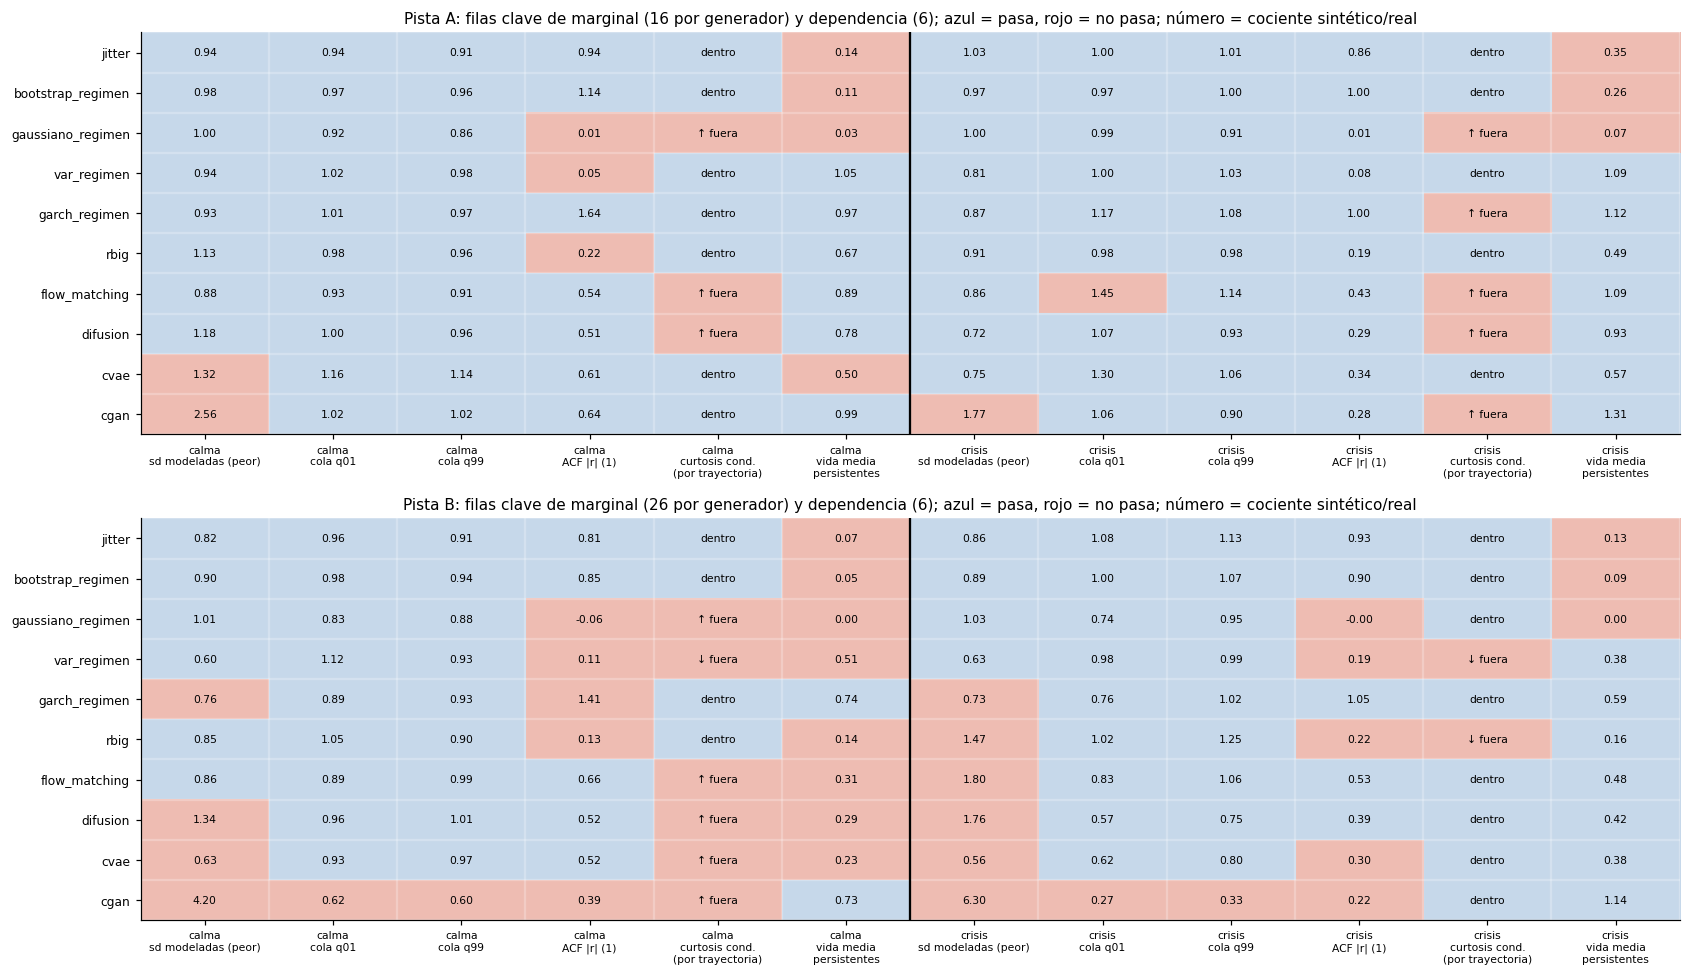

In [8]:
ETIQUETAS_CLAVE = {'desviacion': 'sd modeladas (peor)', 'q01': 'cola q01', 'q99': 'cola q99', 'acf_abs_1': 'ACF |r| (1)',
                   'curtosis_condicional_tray': 'curtosis cond.\n(por trayectoria)',
                   'vida_media_persistentes': 'vida media\npersistentes'}


def filas_clave(t, reglas=REGLAS):
    """Filas clave de los criterios marginal y dependencia (reglas del yaml) con su resultado."""
    marg, dep = TABLAS[t]['fidelidad_marginal'], TABLAS[t]['fidelidad_dependencia']
    rm, rd = reglas['marginal'], reglas['dependencia']
    sel_m = marg['regimen'].isin(REGIMENES) & (
        ((marg['tipo'] == 'modelada') & (marg['metrica'] == 'desviacion') & bool(rm.get('desviacion_modeladas', True)))
        | ((marg['columna'] == datos.COL_RET) & marg['metrica'].isin(rm['colas_ret'])))
    sel_d = dep['regimen'].isin(REGIMENES) & (
        ((dep['columna'] == datos.COL_RET) & dep['metrica'].isin(rd['ret']))
        | ((dep['columna'] == 'persistentes') & dep['metrica'].isin(rd['persistentes'])))
    clave = pd.concat([marg[sel_m].assign(criterio='marginal'), dep[sel_d].assign(criterio='dependencia')],
                      ignore_index=True)
    clave['pasa'] = pasa_fila(clave)
    return clave


def resumen_clave(clave):
    filas = []
    for (n, reg, met), d in clave.groupby(['generador', 'regimen', 'metrica'], sort=False):
        lejania = np.abs(np.log(d['cociente'].astype(float)))
        i = lejania.idxmax() if lejania.notna().any() else d.index[0]
        fila = d.loc[i]
        if met == 'curtosis_condicional_tray':
            texto = 'dentro' if fila['pasa'] else ('↑ fuera' if fila['real'] > fila['banda_sup'] else '↓ fuera')
        else:
            texto = '—' if not np.isfinite(fila['cociente']) else f"{fila['cociente']:.2f}"
        filas.append({'generador': n, 'regimen': reg, 'metrica': ETIQUETAS_CLAVE.get(met, met),
                      'cociente': float(fila['cociente']), 'texto': texto, 'pasa': bool(d['pasa'].all()),
                      'peor columna': fila['columna'], 'filas': len(d), 'fallan': int((~d['pasa']).sum())})
    r = pd.DataFrame(filas)
    columnas = pd.MultiIndex.from_tuples([(reg, e) for reg in REGIMENES for e in ETIQUETAS_CLAVE.values()
                                          if ((r['regimen'] == reg) & (r['metrica'] == e)).any()])
    piv = lambda v: r.pivot(index='generador', columns=['regimen', 'metrica'], values=v).reindex(index=GENERADORES,
                                                                                                columns=columnas)
    return piv('texto'), piv('pasa').astype(bool), r


CLAVE = {t: filas_clave(t) for t in PISTAS}
RES_CLAVE = {t: resumen_clave(CLAVE[t]) for t in PISTAS}
# resultado de los dos criterios por generador (lo mismo que leerá el veredicto de §8)
PASA_CRIT = {t: CLAVE[t].groupby(['generador', 'criterio'])['pasa'].all().unstack('criterio').reindex(GENERADORES)
             for t in PISTAS}

fig, axes = plt.subplots(len(PISTAS), 1, figsize=(15.5, 4.5 * len(PISTAS)))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    texto, pasa, _ = RES_CLAVE[t]
    pasa, texto = pasa.copy(), texto.copy()
    etiquetas = [f'{r}\n{m}' for r, m in pasa.columns]
    texto.columns = pasa.columns = etiquetas
    n_filas = CLAVE[t][CLAVE[t]['generador'] == GENERADORES[0]].groupby('criterio').size()
    dibujar_pasa(ax, pasa, texto, titulo=f'Pista {t}: filas clave de marginal ({n_filas.get("marginal", 0)} por generador) y '
                                         f'dependencia ({n_filas.get("dependencia", 0)}); azul = pasa, rojo = no pasa; '
                                         f'número = cociente sintético/real')
    ax.axvline(len(etiquetas) / 2 - 0.5, color='black', lw=1.5)
    ax.tick_params(axis='x', labelsize=7)
fig.tight_layout(); guardar(fig, 'hechos_estilizados_filas_clave'); plt.show()

In [9]:
lineas = []
for t in PISTAS:
    pc = PASA_CRIT[t]
    _, _, r = RES_CLAVE[t]
    fallos = r[~r['pasa']].groupby('metrica').size().sort_values(ascending=False)
    sd = r[r['metrica'] == ETIQUETAS_CLAVE['desviacion']]
    peor_sd = sd.loc[sd['cociente'].sub(1).abs().idxmax()] if len(sd) else None
    c = CLAVE[t]
    solo_banda = c['pasa'] & ~c['cociente'].astype(float).between(*BANDA) & (c['metrica'] != 'curtosis_condicional_tray')
    vm = c[c['metrica'] == 'vida_media_persistentes']
    vm_fallan = vm[~vm['pasa']]
    lineas += [
        f"- **Pista {t}**. `marginal`: {pasan(pc.index[pc['marginal']])}; `dependencia`: {pasan(pc.index[pc['dependencia']])}. "
        "Métricas clave más suspendidas (casos generador × régimen): "
        + ', '.join(f"{m.replace(chr(10), ' ')} ({k})" for m, k in fallos.head(3).items()) + '.',
        (f"  - Peor escala de una columna modelada: `{peor_sd['peor columna']}` en `{peor_sd['generador']}` "
         f"({peor_sd['regimen']}), cociente {fmt(peor_sd['cociente'])}." if peor_sd is not None else ''),
        f"  - Vida media de las persistentes (real {fmt(vm[vm['regimen'] == 'calma']['real'].iloc[0], 0)} sesiones en "
        f"calma y {fmt(vm[vm['regimen'] == 'crisis']['real'].iloc[0], 0)} en crisis): "
        + '; '.join((f"en {g} no pasa en {lista(vm_fallan[vm_fallan['regimen'] == g]['generador'])} (cocientes de "
                     f"{fmt(vm_fallan[vm_fallan['regimen'] == g]['cociente'].min())} a "
                     f"{fmt(vm_fallan[vm_fallan['regimen'] == g]['cociente'].max())})")
                    if (vm_fallan['regimen'] == g).any() else f"en {g} pasan todos" for g in REGIMENES) + '.',
        f"  - {int(solo_banda.sum())} filas clave pasan solo por la banda bootstrap del real con el cociente fuera de "
        f"`banda_cociente` ({int(solo_banda[c['regimen'] == 'crisis'].sum())} de ellas en crisis).",
    ]
# control: el propio real troceado en trayectorias de la misma longitud, pasado por la misma regla de dependencia,
# con la referencia vigente (DEP_REAL) y con la anterior, el real entero (DEP_REAL_ENT)
def clave_dep(d):
    rd = REGLAS['dependencia']
    sel = d['regimen'].isin(REGIMENES) & (((d['columna'] == datos.COL_RET) & d['metrica'].isin(rd['ret']))
                                         | ((d['columna'] == 'persistentes') & d['metrica'].isin(rd['persistentes'])))
    return d[sel].assign(pasa=pasa_fila(d[sel]))


DEP_REAL = {t: clave_dep(CONTROL[t]['dependencia_real']) for t in PISTAS}
DEP_REAL_ENT = {t: clave_dep(CONTROL[t]['dependencia_real_entero']) for t in PISTAS}


def fallos_dep(tabla):
    f = tabla[~tabla['pasa']]
    return ', '.join(f"{METRICA_LEGIBLE.get(x.metrica, x.metrica)} en {x.regimen}"
                     + (f" (cociente {fmt(x.cociente)})" if np.isfinite(x.cociente) else '') for x in f.itertuples())


def estado_dep(tabla):
    return 'pasa' if tabla['pasa'].all() else f"**no pasa** ({fallos_dep(tabla)})"


vm = lambda tabla: tabla[tabla['metrica'] == 'vida_media_persistentes'].set_index('regimen')['cociente']
VM_REAL = {t: vm(DEP_REAL[t]) for t in PISTAS}
VM_REAL_ENT = {t: vm(DEP_REAL_ENT[t]) for t in PISTAS}
VM_GEN = {t: CLAVE[t][CLAVE[t]['metrica'] == 'vida_media_persistentes'] for t in PISTAS}
lineas.append('- **Control de la dependencia: el propio real troceado** en ventanas de la longitud de las trayectorias, '
              'pasado por la misma regla. Con la referencia vigente: ' + '; '.join(f"{t}, {estado_dep(DEP_REAL[t])}" for t in PISTAS)
              + f"; cociente de vida media " + '; '.join(f"{fmt(VM_REAL[t]['calma'])} en calma y {fmt(VM_REAL[t]['crisis'])} "
                                                       f"en crisis ({t})" for t in PISTAS)
              + '. Con la referencia anterior (real entero): ' + '; '.join(f"{t}, {estado_dep(DEP_REAL_ENT[t])}" for t in PISTAS)
              + '; cociente de vida media ' + '; '.join(f"{fmt(VM_REAL_ENT[t]['calma'])} y {fmt(VM_REAL_ENT[t]['crisis'])} "
                                                       f"({t})" for t in PISTAS)
              + '. Los generadores no copiadores quedan con la referencia vigente entre ' + '; '.join(
                  f"{fmt(VM_GEN[t][~VM_GEN[t]['generador'].isin(CONTROLES)]['cociente'].min())} y "
                  f"{fmt(VM_GEN[t][~VM_GEN[t]['generador'].isin(CONTROLES)]['cociente'].max())} ({t})" for t in PISTAS) + '.')
# la corrección también penaliza a quien se pasaba por arriba (cociente > 1 que entraba con la referencia anterior)
for t in PISTAS:
    ent = TABLAS[t]['fidelidad_dependencia_entero']
    ent = ent[(ent['metrica'] == 'acf_abs_1') & ent['regimen'].isin(REGIMENES)]
    ent = ent.assign(pasa_ent=pasa_fila(ent)).set_index(['generador', 'regimen'])
    nue = CLAVE[t][CLAVE[t]['metrica'] == 'acf_abs_1'].set_index(['generador', 'regimen'])
    por_arriba = [f"`{g}` ({r}, cociente {fmt(nue.loc[(g, r), 'cociente'])} frente a {fmt(ent.loc[(g, r), 'cociente'])} antes)"
                  for g, r in nue.index if ent.loc[(g, r), 'pasa_ent'] and not nue.loc[(g, r), 'pasa']
                  and nue.loc[(g, r), 'cociente'] > 1]
    if str(ATTRS_DEP[t].get('referencia_ventanas_aplicada')) == 'True':
        cal = TABLAS[t]['fidelidad_dependencia']
        r_new = cal[(cal['metrica'] == 'acf_abs_1') & (cal['regimen'] == 'calma')]['real'].iloc[0]
        r_old = ent.xs('calma', level='regimen')['real'].iloc[0]
        lineas.append(f"  - Pista {t}: la referencia por ventanas cambia el valor real de la ACF de |r| a 1 sesión en calma de "
                      f"{fmt(r_old, 3)} a {fmt(r_new, 3)}; eso también puede castigar a quien antes **se pasaba por arriba** "
                      f"(cociente > 1 que entraba en la banda): "
                      + (', '.join(por_arriba) if por_arriba else 'en esta ejecución no le ocurre a ningún generador') + '.')
calib = '; '.join(f"pista {t}: marginal {'sí' if PASA_CRIT[t].loc['bootstrap_regimen', 'marginal'] else 'no'}, dependencia "
                  f"{'sí' if PASA_CRIT[t].loc['bootstrap_regimen', 'dependencia'] else 'no'}" for t in PISTAS)
md('**(c) Lectura (cifras de la figura y de las tablas de fidelidad).**', *[x for x in lineas if x],
   f"- **Calibración empírica de la regla «todas las filas clave».** El control que copia filas reales "
   f"(`bootstrap_regimen`, un pseudo-sintético hecho con bloques del propio real) es la referencia de un generador "
   f"«perfecto» en la ley condicional: {calib}. Donde suspende, la regla es más estricta que la variabilidad del "
   f"remuestreo; donde aprueba, los suspensos de los demás no se deben solo al número de filas.",
   f"- La desviación por régimen se exige a **cada** columna modelada y a los dos regímenes (`banda_cociente` = "
   f"{fmt(BANDA[0])}–{fmt(BANDA[1])}, o dentro de la banda bootstrap del real).")

**(c) Lectura (cifras de la figura y de las tablas de fidelidad).**
- **Pista A**. `marginal`: pasan todos salvo `flow_matching`, `cvae`, `cgan`; `dependencia`: no pasa ninguno. Métricas clave más suspendidas (casos generador × régimen): curtosis cond. (por trayectoria) (8), vida media persistentes (7), ACF |r| (1) (3).
  - Peor escala de una columna modelada: `term_spread_hist_z` en `cgan` (calma), cociente 2,56.
  - Vida media de las persistentes (real 221 sesiones en calma y 94 en crisis): en calma no pasa en `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `cvae` (cocientes de 0,03 a 0,50); en crisis no pasa en `jitter`, `bootstrap_regimen`, `gaussiano_regimen` (cocientes de 0,07 a 0,35).
  - 20 filas clave pasan solo por la banda bootstrap del real con el cociente fuera de `banda_cociente` (13 de ellas en crisis).
- **Pista B**. `marginal`: pasan `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`; `dependencia`: no pasa ninguno. Métricas clave más suspendidas (casos generador × régimen): vida media persistentes (11), ACF |r| (1) (10), sd modeladas (peor) (10).
  - Peor escala de una columna modelada: `term_spread_hist_z` en `cgan` (crisis), cociente 6,30.
  - Vida media de las persistentes (real 279 sesiones en calma y 136 en crisis): en calma no pasa en todos salvo `garch_regimen`, `cgan` (cocientes de 0,00 a 0,51); en crisis no pasa en `jitter`, `bootstrap_regimen`, `gaussiano_regimen` (cocientes de 0,00 a 0,13).
  - 49 filas clave pasan solo por la banda bootstrap del real con el cociente fuera de `banda_cociente` (38 de ellas en crisis).
- **Control de la dependencia: el propio real troceado** en ventanas de la longitud de las trayectorias, pasado por la misma regla. Con la referencia vigente: A, pasa; B, pasa; cociente de vida media 1,15 en calma y 1,27 en crisis (A); 1,00 en calma y 1,00 en crisis (B). Con la referencia anterior (real entero): A, **no pasa** (ACF |r| (1) en crisis (cociente 0,49)); B, pasa; cociente de vida media 0,80 y 0,80 (A); 1,00 y 1,00 (B). Los generadores no copiadores quedan con la referencia vigente entre 0,03 y 1,31 (A); 0,00 y 1,14 (B).
  - Pista A: la referencia por ventanas cambia el valor real de la ACF de |r| a 1 sesión en calma de 0,158 a 0,119; eso también puede castigar a quien antes **se pasaba por arriba** (cociente > 1 que entraba en la banda): en esta ejecución no le ocurre a ningún generador.
- **Calibración empírica de la regla «todas las filas clave».** El control que copia filas reales (`bootstrap_regimen`, un pseudo-sintético hecho con bloques del propio real) es la referencia de un generador «perfecto» en la ley condicional: pista A: marginal sí, dependencia no; pista B: marginal sí, dependencia no. Donde suspende, la regla es más estricta que la variabilidad del remuestreo; donde aprueba, los suspensos de los demás no se deben solo al número de filas.
- La desviación por régimen se exige a **cada** columna modelada y a los dos regímenes (`banda_cociente` = 0,80–1,25, o dentro de la banda bootstrap del real).

<a id="s2-1"></a>
### 2.1 Agrupamiento de volatilidad dentro de régimen

**(b) Figura.** ACF de $|r|$ **dentro de régimen**, retardo a retardo, del real (con su banda: entre
ventanas reales del largo de las trayectorias donde se aplica la referencia de igual a igual,
bootstrap del real entero donde no; lo dice el título de cada panel) y de cada generador. El criterio solo mira el primer retardo; los demás informan sobre la
memoria de la volatilidad: el GARCH decae geométricamente, el bootstrap conserva la dependencia
solo hasta el largo de sus bloques, y un generador que extrae días independientes dentro de
régimen da una ACF plana en cero. La lectura compara además el criterio con la métrica del 15 (ACF
de $|r|$ a un día sobre la trayectoria entera, filas `regimen='todos'`).

figura -> results/sinteticos/validacion/acf_abs_dentro_regimen.png


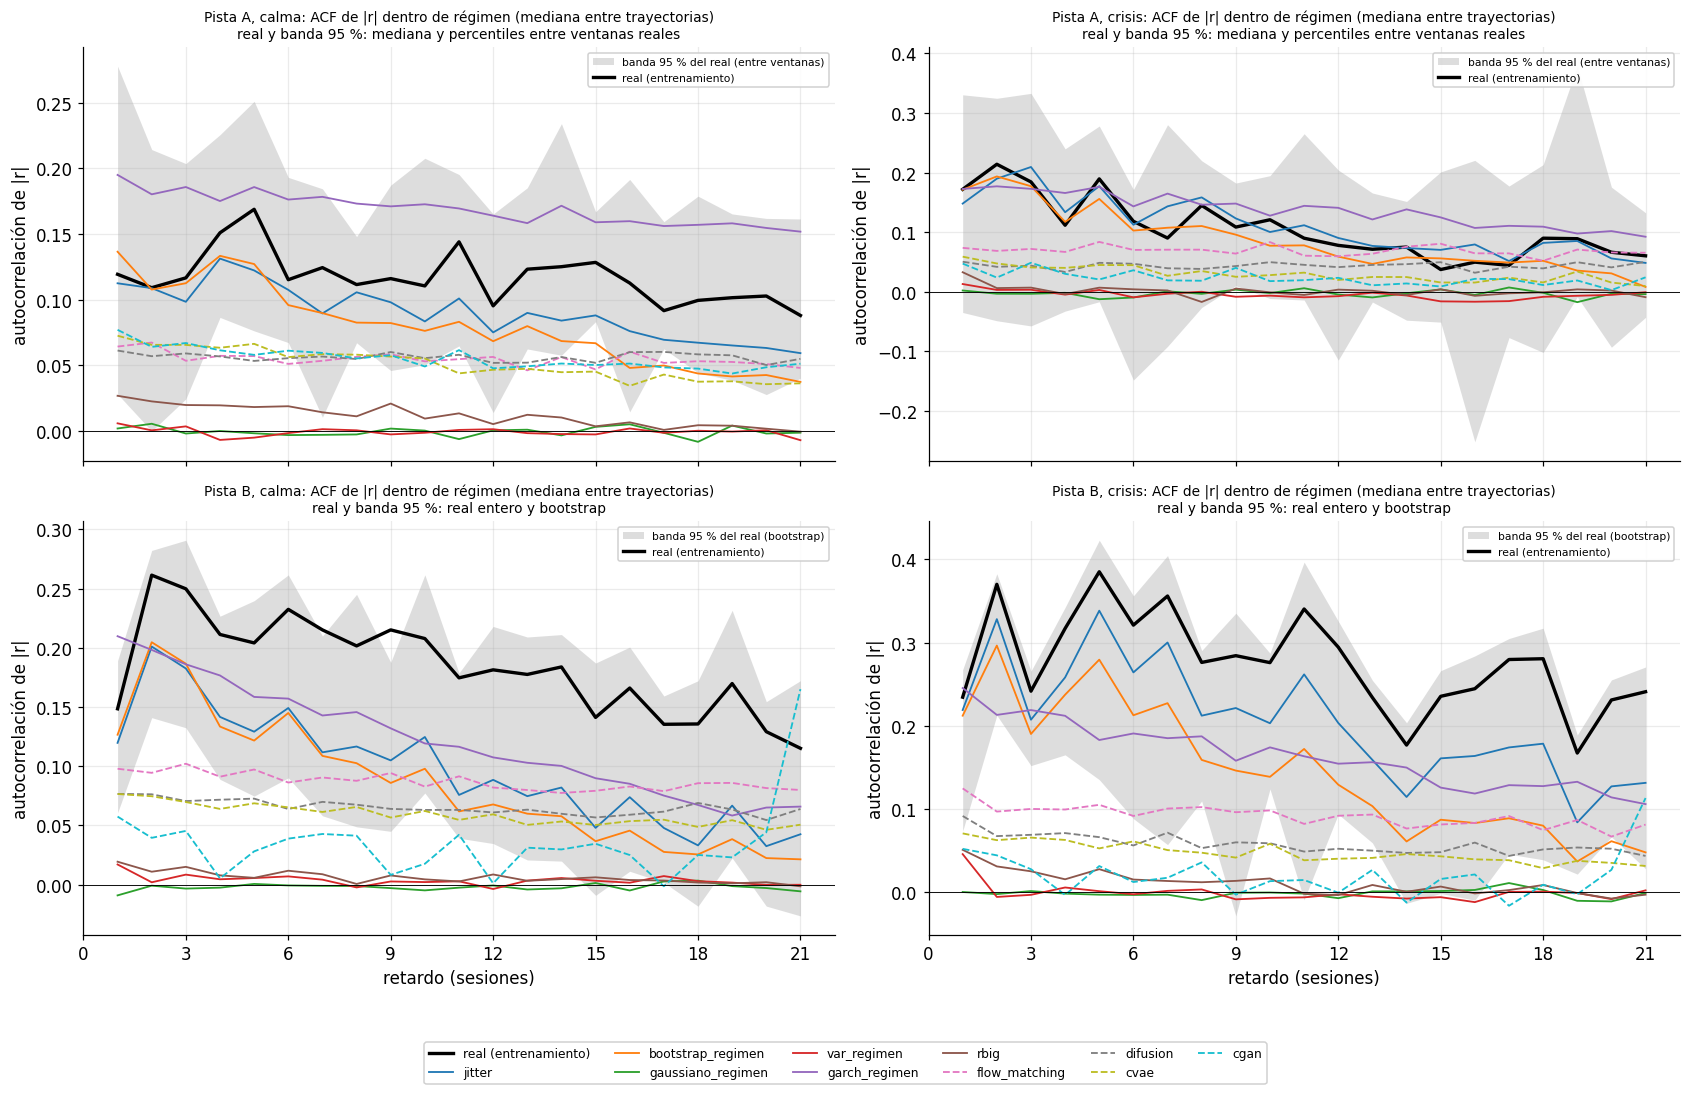

Línea continua = paramétricos; discontinua = neuronales.


In [10]:
fig, axes = plt.subplots(len(PISTAS), 2, figsize=(15.5, 4.8 * len(PISTAS)), sharex=True)
axes = np.atleast_2d(axes)
for i, t in enumerate(PISTAS):
    dep = TABLAS[t]['fidelidad_dependencia']
    sel = dep[dep['metrica'].str.fullmatch(r'acf_abs_\d+')].copy()
    sel['k'] = sel['metrica'].str.extract(r'(\d+)$', expand=False).astype(int)
    for j, regimen in enumerate(REGIMENES):
        ax = axes[i, j]
        s_reg = sel[sel['regimen'] == regimen]
        ref = s_reg[s_reg['generador'] == GENERADORES[0]].sort_values('k')
        por_ventanas = str(ATTRS_DEP[t].get('referencia_ventanas_aplicada')) == 'True'
        ax.fill_between(ref['k'], ref['banda_inf'], ref['banda_sup'], color=viz.C_NEG, alpha=0.25, lw=0,
                        label='banda 95 % del real (' + ('entre ventanas' if por_ventanas else 'bootstrap') + ')')
        ax.plot(ref['k'], ref['real'], color='black', lw=2.2, label='real (entrenamiento)')
        for n in GENERADORES:
            s = s_reg[s_reg['generador'] == n].sort_values('k')
            ax.plot(s['k'], s['sintetico'], color=COLOR_GEN[n], ls=ESTILO_GEN[n], lw=1.2, label=n)
        ax.axhline(0, color='black', lw=0.6)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_title(f'Pista {t}, {regimen}: ACF de |r| dentro de régimen (mediana entre trayectorias)\n'
                     f'real y banda 95 %: ' + ('mediana y percentiles entre ventanas reales' if por_ventanas
                                               else 'real entero y bootstrap'), fontsize=9)
        ax.legend(fontsize=7, loc='upper right', framealpha=0.9,
                  handles=[h for h, e in zip(*ax.get_legend_handles_labels()) if e.startswith(('banda', 'real'))])
        ax.set_ylabel('autocorrelación de |r|')
for ax in axes[-1]:
    ax.set_xlabel('retardo (sesiones)')
manejadores, etiquetas = axes[0, 0].get_legend_handles_labels()
manejadores, etiquetas = zip(*[(h, e) for h, e in zip(manejadores, etiquetas) if not e.startswith('banda')])
fig.legend(manejadores, etiquetas, loc='lower center', ncol=6, fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.04, 1, 1)); guardar(fig, 'acf_abs_dentro_regimen'); plt.show()
print('Línea continua = paramétricos; discontinua = neuronales.')

In [11]:
k_max = max(RETARDOS)
lineas = []
for t in PISTAS:
    dep, clave = TABLAS[t]['fidelidad_dependencia'], CLAVE[t]
    ok1 = [n for n in GENERADORES if clave[(clave['generador'] == n) & (clave['metrica'] == 'acf_abs_1')]['pasa'].all()]
    lejos = dep[dep['regimen'].isin(REGIMENES) & (dep['metrica'] == f'acf_abs_{k_max}')]
    ok_lejos = [n for n in GENERADORES if pasa_fila(lejos[lejos['generador'] == n]).all()]
    pend = dep[dep['regimen'].isin(REGIMENES) & (dep['metrica'] == 'pendiente_loglog_abs')]
    ok_pend = [n for n in GENERADORES if pend[pend['generador'] == n]['en_banda'].fillna(False).all()]
    real = dep[dep['generador'] == GENERADORES[0]].set_index(['regimen', 'metrica'])['real']
    todos = dep[(dep['regimen'] == 'todos') & (dep['metrica'] == 'acf_abs_1')]
    ok_todos = [n for n in GENERADORES if pasa_fila(todos[todos['generador'] == n]).all()]
    cambia = [n for n in GENERADORES if (n in ok_todos) != (n in ok1)]
    lineas.append(
        f"- **Pista {t}**. ACF de |r| a 1 sesión dentro de régimen (real: {fmt(real[('calma', 'acf_abs_1')], 3)} en calma y "
        f"{fmt(real[('crisis', 'acf_abs_1')], 3)} en crisis): en los dos regímenes {pasan(ok1)}. A {k_max} sesiones "
        f"(real {fmt(real[('calma', f'acf_abs_{k_max}')], 3)} y {fmt(real[('crisis', f'acf_abs_{k_max}')], 3)}; informativo) "
        f"siguen en la banda o en el cociente {lista(ok_lejos)}. Pendiente log-log dentro de la banda del real en los dos "
        f"regímenes (real {fmt(real[('calma', 'pendiente_loglog_abs')])} y {fmt(real[('crisis', 'pendiente_loglog_abs')])}): "
        f"{lista(ok_pend)}.")
    texto = (f"  - **Pendiente heredado del 15.** Sobre la trayectoria entera (real {fmt(real[('todos', 'acf_abs_1')], 3)}) "
             f"la misma regla aprobaría a {lista(ok_todos)}; cambian de resultado al medir dentro de régimen: {lista(cambia)}.")
    if cambia:
        texto += (' En esos casos la métrica sobre la trayectoria entera mezcla el salto de nivel de volatilidad entre '
                  'calma y crisis con el agrupamiento propiamente dicho.')
    lineas.append(texto)
md('**(c) Lectura (cifras de la tabla de dependencia).**', *lineas)

**(c) Lectura (cifras de la tabla de dependencia).**
- **Pista A**. ACF de |r| a 1 sesión dentro de régimen (real: 0,119 en calma y 0,172 en crisis): en los dos regímenes pasan todos salvo `gaussiano_regimen`, `var_regimen`, `rbig`. A 21 sesiones (real 0,088 y 0,060; informativo) siguen en la banda o en el cociente `jitter`, `garch_regimen`, `flow_matching`, `difusion`, `cgan`. Pendiente log-log dentro de la banda del real en los dos regímenes (real -0,07 y -0,35): `var_regimen`, `garch_regimen`.
  - **Pendiente heredado del 15.** Sobre la trayectoria entera (real 0,220) la misma regla aprobaría a `jitter`, `bootstrap_regimen`, `garch_regimen`; cambian de resultado al medir dentro de régimen: `flow_matching`, `difusion`, `cvae`, `cgan`. En esos casos la métrica sobre la trayectoria entera mezcla el salto de nivel de volatilidad entre calma y crisis con el agrupamiento propiamente dicho.
- **Pista B**. ACF de |r| a 1 sesión dentro de régimen (real: 0,149 en calma y 0,234 en crisis): en los dos regímenes pasan `jitter`, `bootstrap_regimen`, `flow_matching`, `difusion`. A 21 sesiones (real 0,115 y 0,241; informativo) siguen en la banda o en el cociente todos salvo `gaussiano_regimen`, `var_regimen`, `rbig`. Pendiente log-log dentro de la banda del real en los dos regímenes (real -0,16 y -0,10): todos salvo `gaussiano_regimen`, `cgan`.
  - **Pendiente heredado del 15.** Sobre la trayectoria entera (real 0,285) la misma regla aprobaría a `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `garch_regimen`, `flow_matching`; cambian de resultado al medir dentro de régimen: `gaussiano_regimen`, `garch_regimen`, `difusion`. En esos casos la métrica sobre la trayectoria entera mezcla el salto de nivel de volatilidad entre calma y crisis con el agrupamiento propiamente dicho.

<a id="s2-2"></a>
### 2.2 Cola y curtosis condicional

La lección del taller previo (ficha F8, «Antecedente») fue que **ningún generador reprodujo la
cola condicional**: se puede acertar la cola incondicional por mezcla de escalas (días de
volatilidad alta y baja) sin que los residuos estandarizados por la volatilidad previa tengan cola.
Por eso el criterio exige las dos.

**(b) Figura y tabla.** A la izquierda, la amplitud de cola relativa $\rho_p$ de `q01` y `q99` por
régimen. A la derecha, por régimen, la banda central del 95 % de la curtosis condicional **por
trayectoria** de cada generador (barra, con su mediana) frente al valor real (línea vertical): pasa
si el real cae dentro. La tabla añade la curtosis incondicional dentro de régimen y la métrica
anterior (mediana del sintético frente a la banda del real), informativa.

figura -> results/sinteticos/validacion/colas_curtosis_condicional.png


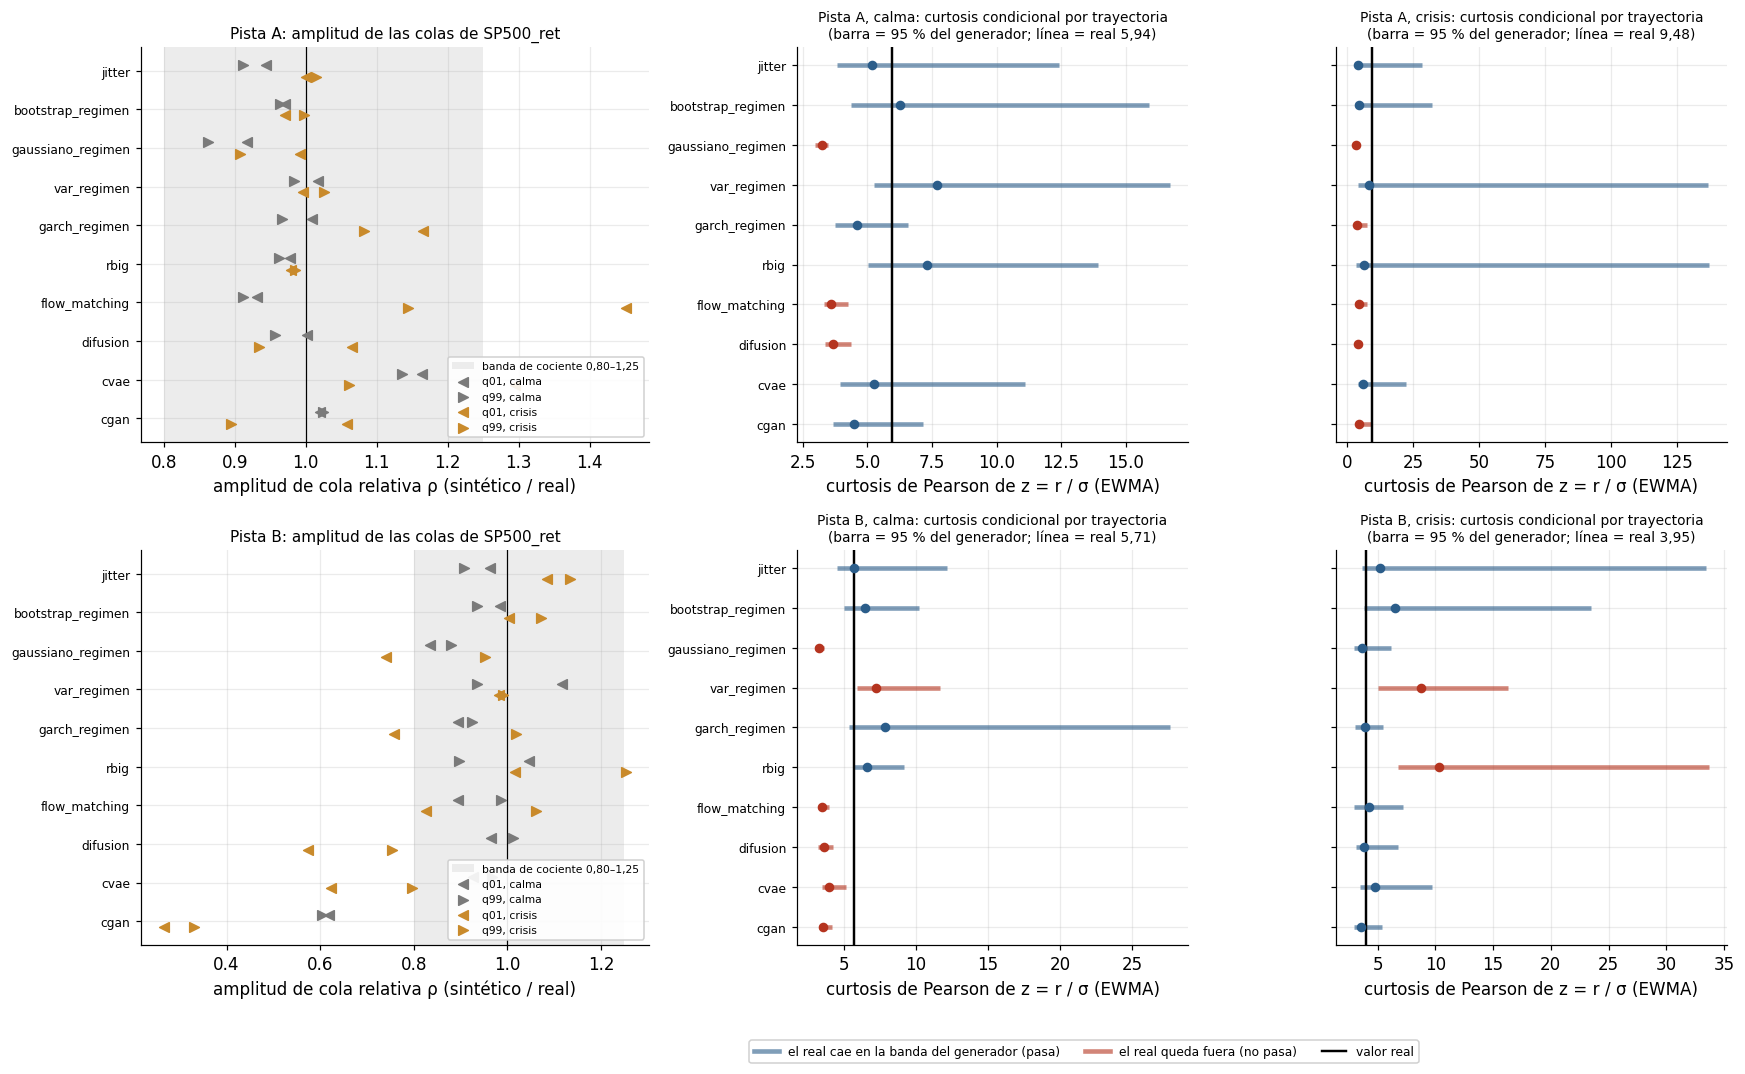

**Pista A** — curtosis incondicional (dentro de régimen) y condicional por trayectoria

**Pista B** — curtosis incondicional (dentro de régimen) y condicional por trayectoria

In [12]:
fig, axes = plt.subplots(len(PISTAS), 3, figsize=(16, 4.8 * len(PISTAS)), gridspec_kw={'width_ratios': [1.3, 1, 1]})
axes = np.atleast_2d(axes)
y = np.arange(len(GENERADORES))[::-1]
COLA = {}
for i, t in enumerate(PISTAS):
    marg, dep = TABLAS[t]['fidelidad_marginal'], TABLAS[t]['fidelidad_dependencia']
    ax = axes[i, 0]
    ax.axvspan(*BANDA, color=viz.C_NA, alpha=0.8, lw=0, label=f'banda de cociente {fmt(BANDA[0])}–{fmt(BANDA[1])}')
    ax.axvline(1, color='black', lw=0.8)
    for regimen, color, desp in (('calma', C_CALMA, 0.15), ('crisis', C_CRISIS_REG, -0.15)):
        for met, marca in (('q01', '<'), ('q99', '>')):
            s = marg[(marg['columna'] == datos.COL_RET) & (marg['regimen'] == regimen) & (marg['metrica'] == met)]
            s = s.set_index('generador').reindex(GENERADORES)
            ax.scatter(s['cociente'], y + desp, marker=marca, color=color, s=40, label=f'{met}, {regimen}', zorder=3)
    ax.set_yticks(y, GENERADORES, fontsize=8)
    ax.set_xlabel('amplitud de cola relativa ρ (sintético / real)')
    ax.set_title(f'Pista {t}: amplitud de las colas de SP500_ret', fontsize=10)
    ax.legend(fontsize=7, loc='lower right', framealpha=0.9)
    filas = {}
    for j, regimen in enumerate(REGIMENES, start=1):
        ax = axes[i, j]
        s = dep[(dep['regimen'] == regimen) & (dep['metrica'] == 'curtosis_condicional_tray')].set_index('generador').reindex(GENERADORES)
        ant = dep[(dep['regimen'] == regimen) & (dep['metrica'] == 'curtosis_condicional')].set_index('generador').reindex(GENERADORES)
        ok = s['en_banda'].fillna(False).astype(bool).to_numpy()
        real = float(s['real'].iloc[0])
        for k, n in enumerate(GENERADORES):
            color = viz.C_LONG if ok[k] else viz.C_CRISIS
            ax.plot([s.loc[n, 'banda_inf'], s.loc[n, 'banda_sup']], [y[k], y[k]], color=color, lw=3, alpha=0.6,
                    solid_capstyle='butt')
            ax.scatter(s.loc[n, 'sintetico'], y[k], color=color, s=28, zorder=3)
        ax.axvline(real, color='black', lw=1.6)
        ax.set_yticks(y, GENERADORES if j == 1 else [''] * len(y), fontsize=8)
        ax.set_xlabel('curtosis de Pearson de z = r / σ (EWMA)')
        ax.set_title(f'Pista {t}, {regimen}: curtosis condicional por trayectoria\n(barra = 95 % del generador; '
                     f'línea = real {fmt(real)})', fontsize=9)
        inc = marg[(marg['columna'] == datos.COL_RET) & (marg['regimen'] == regimen)
                   & (marg['metrica'] == 'curtosis')].set_index('generador').reindex(GENERADORES)
        filas[(regimen, 'incond. real')] = inc['real']
        filas[(regimen, 'incond. sint.')] = inc['sintetico']
        filas[(regimen, 'incond. en banda')] = inc['en_banda']
        filas[(regimen, 'cond. real')] = s['real']
        filas[(regimen, 'cond. sint. p2,5')] = s['banda_inf']
        filas[(regimen, 'cond. sint. p97,5')] = s['banda_sup']
        filas[(regimen, 'cond. pasa')] = pd.Series(ok, index=GENERADORES)
        filas[(regimen, 'anterior: pasa')] = pasa_fila(ant.reset_index()).set_axis(GENERADORES)
    COLA[t] = pd.DataFrame(filas)
manejadores = [Line2D([], [], color=viz.C_LONG, lw=3, alpha=0.6, label='el real cae en la banda del generador (pasa)'),
               Line2D([], [], color=viz.C_CRISIS, lw=3, alpha=0.6, label='el real queda fuera (no pasa)'),
               Line2D([], [], color='black', lw=1.6, label='valor real')]
fig.legend(handles=manejadores, loc='lower center', ncol=3, fontsize=8, framealpha=0.9, bbox_to_anchor=(0.62, -0.02))
fig.tight_layout(rect=(0, 0.03, 1, 1)); guardar(fig, 'colas_curtosis_condicional'); plt.show()
for t in PISTAS:
    display(Markdown(f'**Pista {t}** — curtosis incondicional (dentro de régimen) y condicional por trayectoria'))
    display(COLA[t].style.format('{:.2f}', subset=[c for c in COLA[t].columns
                                                   if c[1].startswith(('incond. real', 'incond. sint', 'cond. real', 'cond. sint'))]))

In [13]:
# referencia de ruido normal con la misma EWMA, por simulación
rng = np.random.default_rng(SEMILLA_VAL)
CURT_NORMAL = {t: float(np.median([val_fidelidad._curtosis(val_fidelidad._z_ewma(rng.standard_normal(len(PANEL[t]))))
                                   for _ in range(50)])) for t in PISTAS}
lineas = []
for t in PISTAS:
    _, _, r = RES_CLAVE[t]
    co = COLA[t]
    colas_ok = [n for n in GENERADORES if r[(r['generador'] == n) & r['metrica'].isin(['cola q01', 'cola q99'])]['pasa'].all()]
    cond_ok = [n for n in GENERADORES if co.loc[n, [(g, 'cond. pasa') for g in REGIMENES]].all()]
    falta = [n for n in GENERADORES if any((not co.loc[n, (g, 'cond. pasa')]) and co.loc[n, (g, 'cond. real')]
                                           > co.loc[n, (g, 'cond. sint. p97,5')] for g in REGIMENES)]
    sobra = [n for n in GENERADORES if any((not co.loc[n, (g, 'cond. pasa')]) and co.loc[n, (g, 'cond. real')]
                                           < co.loc[n, (g, 'cond. sint. p2,5')] for g in REGIMENES)]
    inc_ok = [n for n in GENERADORES if co.loc[n, [(g, 'incond. en banda') for g in REGIMENES]].fillna(False).all()]
    mezcla = [n for n in inc_ok if n in falta]
    ant_ok = [n for n in GENERADORES if co.loc[n, [(g, 'anterior: pasa') for g in REGIMENES]].all()]
    lineas.append(
        f"- **Pista {t}**. Amplitud de las dos colas en banda en los dos regímenes: {lista(colas_ok)}. Curtosis condicional "
        f"real {fmt(co[('calma', 'cond. real')].iloc[0])} en calma y {fmt(co[('crisis', 'cond. real')].iloc[0])} en crisis; "
        f"el real es típico del generador en los dos regímenes en {lista(cond_ok)}. Le **falta** cola condicional en algún "
        f"régimen (real por encima de su banda): {lista(falta)}; le **sobra** (real por debajo): {lista(sobra)}. Cola "
        f"incondicional en banda pero cola condicional insuficiente (cola «por mezcla», la lección del taller): "
        f"{lista(mezcla)}. Con la métrica anterior (mediana frente a banda real) pasaban {lista(ant_ok)}.")
md('**(c) Lectura (cifras de la tabla y la figura).**', *lineas,
   '- Referencia para leer la curtosis condicional: ruido normal de varianza constante con esta misma EWMA da, por '
   'simulación, una curtosis mediana de ' + ' y '.join(f"{fmt(CURT_NORMAL[t])} con la longitud de la pista {t}" for t in PISTAS)
   + ' (no 3: la volatilidad se estima con pocas decenas de días efectivos). Valores cercanos indican días gaussianos una '
     'vez descontada la volatilidad.')

**(c) Lectura (cifras de la tabla y la figura).**
- **Pista A**. Amplitud de las dos colas en banda en los dos regímenes: todos salvo `flow_matching`. Curtosis condicional real 5,94 en calma y 9,48 en crisis; el real es típico del generador en los dos regímenes en `jitter`, `bootstrap_regimen`, `var_regimen`, `rbig`, `cvae`. Le **falta** cola condicional en algún régimen (real por encima de su banda): `gaussiano_regimen`, `garch_regimen`, `flow_matching`, `difusion`, `cgan`; le **sobra** (real por debajo): ninguno. Cola incondicional en banda pero cola condicional insuficiente (cola «por mezcla», la lección del taller): `garch_regimen`, `flow_matching`, `cgan`. Con la métrica anterior (mediana frente a banda real) pasaban todos salvo `gaussiano_regimen`, `flow_matching`, `difusion`.
- **Pista B**. Amplitud de las dos colas en banda en los dos regímenes: todos salvo `cgan`. Curtosis condicional real 5,71 en calma y 3,95 en crisis; el real es típico del generador en los dos regímenes en `jitter`, `bootstrap_regimen`, `garch_regimen`. Le **falta** cola condicional en algún régimen (real por encima de su banda): `gaussiano_regimen`, `flow_matching`, `difusion`, `cvae`, `cgan`; le **sobra** (real por debajo): `var_regimen`, `rbig`. Cola incondicional en banda pero cola condicional insuficiente (cola «por mezcla», la lección del taller): `flow_matching`, `difusion`, `cvae`, `cgan`. Con la métrica anterior (mediana frente a banda real) pasaban ninguno.
- Referencia para leer la curtosis condicional: ruido normal de varianza constante con esta misma EWMA da, por simulación, una curtosis mediana de 3,20 con la longitud de la pista A y 3,22 con la longitud de la pista B (no 3: la volatilidad se estima con pocas decenas de días efectivos). Valores cercanos indican días gaussianos una vez descontada la volatilidad.

<a id="s2-3"></a>
### 2.3 Columnas modeladas frente a re-derivadas

Las columnas re-derivadas del S&P 500 (z-score del retorno, volatilidad realizada, momentum y
drawdown) no las produce el generador: se recalculan sobre [historia real + retornos sintéticos]
(notebook 15, §3) y acumulan durante ventanas largas cualquier defecto de la dinámica del retorno.
Por eso no entran en los criterios de fidelidad y se leen aparte (aunque sí entran en el
discriminador, §5).

**(b) Tabla.** Porcentaje de filas en banda (desviación, cuantiles, Wasserstein y KS) por tipo de
columna, la peor desviación re-derivada y los escalones mensuales, que solo conserva quien copia
filas reales.

In [14]:
MOD_DER = {}
for t in PISTAS:
    marg, dep = TABLAS[t]['fidelidad_marginal'], TABLAS[t]['fidelidad_dependencia']
    sel = marg[marg['regimen'].isin(REGIMENES) & marg['metrica'].isin(['desviacion', 'q01', 'q05', 'q95', 'q99',
                                                                        'wasserstein', 'ks'])]
    pct = 100 * sel.assign(pasa=pasa_fila(sel)).groupby(['generador', 'tipo'])['pasa'].mean().unstack('tipo').reindex(GENERADORES)
    sd_der = sel[(sel['tipo'] == 're-derivada') & (sel['metrica'] == 'desviacion')]
    peor = (sd_der.assign(lejania=np.abs(np.log(sd_der['cociente']))).dropna(subset=['lejania'])
            .sort_values('lejania').groupby('generador').tail(1))
    esc = dep[(dep['metrica'] == 'escalones') & (dep['regimen'] == 'calma')].set_index('generador').reindex(GENERADORES)
    MOD_DER[t] = pd.DataFrame({'% filas en banda: modeladas': pct.get('modelada'),
                               '% filas en banda: re-derivadas': pct.get('re-derivada'),
                               'peor sd re-derivada (cociente)': peor.set_index('generador')['cociente'].reindex(GENERADORES),
                               'peor re-derivada': peor.set_index('generador')['columna'].reindex(GENERADORES),
                               'escalones calma: real': esc['real'], 'escalones calma: sint.': esc['sintetico']})
    display(Markdown(f'**Pista {t}** — filas informativas por tipo de columna'))
    display(MOD_DER[t].style.format({c: '{:.1f}' for c in MOD_DER[t].columns if c.startswith('%')}
                                    | {'peor sd re-derivada (cociente)': '{:.2f}', 'escalones calma: real': '{:.3f}',
                                       'escalones calma: sint.': '{:.3f}'}, na_rep='—'))
lineas = []
for t in PISTAS:
    m = MOD_DER[t]
    con_esc = [n for n in GENERADORES if m.loc[n, 'escalones calma: sint.'] >= BANDA[0] * m.loc[n, 'escalones calma: real']]
    lineas.append(
        f"- **Pista {t}**: mediana entre generadores del % de filas en banda, {fmt(m['% filas en banda: modeladas'].median(), 0)} % "
        f"en las modeladas frente a {fmt(m['% filas en banda: re-derivadas'].median(), 0)} % en las re-derivadas. Conservan los "
        f"escalones mensuales (días sin cambio, real {fmt(100 * m['escalones calma: real'].iloc[0], 1)} % en calma): {lista(con_esc)}.")
md('**(c) Lectura (informativa, fuera del veredicto).**', *lineas,
   '- Que las re-derivadas queden peor que las modeladas es lo esperado (§3 del 15): es un coste del espacio de '
   'generación, común a todos los generadores, y la razón de que los criterios de fidelidad solo miren las modeladas y '
   'el retorno.')

**Pista A** — filas informativas por tipo de columna

,% filas en banda: modeladas,% filas en banda: re-derivadas,peor sd re-derivada (cociente),peor re-derivada,escalones calma: real,escalones calma: sint.
generador,,,,,,
jitter,98.8,69.6,2.06,SP500_drawdown,0.953,0.000
bootstrap_regimen,100.0,69.6,1.98,SP500_drawdown,0.953,0.906
gaussiano_regimen,78.6,41.1,0.34,SP500_vol_z,0.953,0.000
var_regimen,83.3,48.2,2.44,SP500_drawdown,0.953,0.000
garch_regimen,83.3,69.6,1.72,SP500_drawdown,0.953,0.000
rbig,96.4,55.4,1.83,SP500_drawdown,0.953,0.000
flow_matching,83.3,50.0,2.31,SP500_drawdown,0.953,0.000
difusion,81.0,64.3,1.61,SP500_drawdown,0.953,0.000
cvae,72.6,53.6,2.19,SP500_drawdown,0.953,0.000


**Pista B** — filas informativas por tipo de columna

,% filas en banda: modeladas,% filas en banda: re-derivadas,peor sd re-derivada (cociente),peor re-derivada,escalones calma: real,escalones calma: sint.
generador,,,,,,
jitter,98.1,76.8,2.06,SP500_drawdown,0.953,0.000
bootstrap_regimen,100.0,73.2,1.93,SP500_drawdown,0.953,0.906
gaussiano_regimen,77.9,44.6,0.33,SP500_vol_z,0.953,0.000
var_regimen,86.4,60.7,0.52,SP500_vol_z,0.953,0.000
garch_regimen,78.6,75.0,1.61,SP500_drawdown,0.953,0.000
rbig,94.2,71.4,0.62,SP500_vol_z,0.953,0.000
flow_matching,81.2,73.2,0.70,SP500_vol_z,0.953,0.000
difusion,77.9,80.4,0.50,SP500_vol_z,0.953,0.000
cvae,84.4,80.4,0.47,SP500_vol_z,0.953,0.000


**(c) Lectura (informativa, fuera del veredicto).**
- **Pista A**: mediana entre generadores del % de filas en banda, 83 % en las modeladas frente a 56 % en las re-derivadas. Conservan los escalones mensuales (días sin cambio, real 95,3 % en calma): `bootstrap_regimen`.
- **Pista B**: mediana entre generadores del % de filas en banda, 83 % en las modeladas frente a 73 % en las re-derivadas. Conservan los escalones mensuales (días sin cambio, real 95,3 % en calma): `bootstrap_regimen`.
- Que las re-derivadas queden peor que las modeladas es lo esperado (§3 del 15): es un coste del espacio de generación, común a todos los generadores, y la razón de que los criterios de fidelidad solo miren las modeladas y el retorno.

**(d) Límites.** (i) La referencia por ventanas corrige el sesgo de muestra corta donde el real tiene
ventanas suficientes; donde no (pista B) la comparación sigue siendo entre el real entero y
trayectorias de largo parecido. (ii) La regla «todas las filas clave» es exigente: cuantas más columnas modeladas,
más fácil es que una sola quede fuera; la calibración con el control que copia filas reales está en
la lectura de §2. (iii) Las bandas del real son de remuestreo del propio tramo de entrenamiento; en
crisis dependen de un puñado de episodios y de las pocas combinaciones distintas que admiten (celda
de arriba): pueden ser anchas o degeneradas según la pista y la métrica. (iv) El sintético es una
muestra enorme: su error de estimación es despreciable y no se añade a la banda, salvo en la
curtosis condicional, donde la banda es precisamente la del sintético por trayectoria. (v) La
curtosis condicional depende de la EWMA elegida.

<a id="s3"></a>
## 3. Regímenes y condicionamiento

**(a) Idea y supuestos.** En este diseño la cadena de regímenes no la decide el generador: la
simula la base común (`GeneradorBase.sample`) con la matriz de transición de entrenamiento, la
misma ley para todos. Por eso `fidelidad_regimenes` (fracción de días, duraciones de racha,
probabilidad de permanencia $P_{kk}$ y KS de duraciones) es un **control**: comprueba que la cadena
reproduce la real y debe dar lo mismo para todos los generadores.

Lo que sí depende del generador es si un día con `regime = 1` **se parece a un día de crisis**.
`condicionamiento` lo mide de tres formas:

- la **separación de volatilidad** $s = \hat\sigma(r \mid \text{crisis}) / \hat\sigma(r \mid
  \text{calma})$; el criterio decide **solo por su cociente** sintético/real en `banda_cociente`
  (la banda bootstrap del real se publica, pero no rescata un cociente fuera);
- la **deriva en crisis**, la media de $r$ en crisis en puntos básicos (informativa);
- el **AUC de una regresión logística** que predice el régimen del día con las features del día:
  *agrupado* (fuera de pliegue, con pliegues formados por rachas en el real y por trayectorias en
  el sintético) y *de ajuste* (dentro de muestra). Ambos informativos.

El AUC agrupado del real es **bajo por construcción**: los episodios reales son heterogéneos y
evaluar en un episodio que el modelo no vio penaliza esa heterogeneidad; los sintéticos salen de
una sola ley condicional y un generador fiel da un AUC agrupado **mayor** que el real. El AUC de
ajuste mide lo mismo en los dos lados y es el comparable. El notebook 15 señaló un
condicionamiento débil en la cGAN, la difusión y el cVAE de la pista B; aquí se mide.

**(b) Tablas y figura.**

In [15]:
REG_IDENTICA = {}
for t in PISTAS:
    R = TABLAS[t]['fidelidad_regimenes']
    rango = R.groupby(['regimen', 'metrica'], sort=False)['sintetico'].agg(lambda s: s.max() - s.min())
    REG_IDENTICA[t] = bool(np.nanmax(np.abs(rango.to_numpy())) < 1e-12)
    base = (R[R['generador'] == GENERADORES[0]].set_index(['regimen', 'metrica'])[['real', 'sintetico', 'cociente']])
    display(Markdown(f'**Pista {t}** — duraciones y transiciones (control; idéntica en todos los generadores: '
                     f'{"sí" if REG_IDENTICA[t] else "**no**"})'))
    display(base.style.format('{:.4f}', na_rep='—'))
lineas = []
for t in PISTAS:
    b = TABLAS[t]['fidelidad_regimenes']
    b = b[b['generador'] == GENERADORES[0]].set_index(['regimen', 'metrica'])
    lineas.append(
        f"- **Pista {t}**: crisis el {fmt(100 * b.loc[('crisis', 'fraccion_dias'), 'real'], 1)} % de los días reales y el "
        f"{fmt(100 * b.loc[('crisis', 'fraccion_dias'), 'sintetico'], 1)} % de los sintéticos; duración mediana de las crisis "
        f"{fmt(b.loc[('crisis', 'duracion_mediana'), 'real'], 0)} sesiones reales frente a "
        f"{fmt(b.loc[('crisis', 'duracion_mediana'), 'sintetico'], 0)} sintéticas; permanencia en crisis "
        f"{fmt(b.loc[('crisis', 'P_kk'), 'real'], 4)} frente a {fmt(b.loc[('crisis', 'P_kk'), 'sintetico'], 4)}; KS de "
        f"duraciones de crisis {fmt(b.loc[('crisis', 'ks_duraciones'), 'sintetico'])} (p = "
        f"{fmt(b.loc[('crisis', 'ks_duraciones_p'), 'sintetico'])}, con solo {N_EPISODIOS[t]} duraciones reales).")
md('**(c) Lectura del control (cifras de la tabla).**', *lineas,
   '- La cadena común reproduce la permanencia media y la fracción de crisis, pero las duraciones geométricas no tienen '
   'la forma de las reales (más crisis cortas; 15, §2.1). No discrimina entre generadores y no entra en el veredicto.')

**Pista A** — duraciones y transiciones (control; idéntica en todos los generadores: sí)

**Pista B** — duraciones y transiciones (control; idéntica en todos los generadores: sí)

**(c) Lectura del control (cifras de la tabla).**
- **Pista A**: crisis el 19,6 % de los días reales y el 16,5 % de los sintéticos; duración mediana de las crisis 269 sesiones reales frente a 170 sintéticas; permanencia en crisis 0,9964 frente a 0,9959; KS de duraciones de crisis 0,31 (p = 0,37, con solo 8 duraciones reales).
- **Pista B**: crisis el 25,9 % de los días reales y el 24,8 % de los sintéticos; duración mediana de las crisis 146 sesiones reales frente a 125 sintéticas; permanencia en crisis 0,9943 frente a 0,9943; KS de duraciones de crisis 0,25 (p = 0,91, con solo 4 duraciones reales).
- La cadena común reproduce la permanencia media y la fracción de crisis, pero las duraciones geométricas no tienen la forma de las reales (más crisis cortas; 15, §2.1). No discrimina entre generadores y no entra en el veredicto.

**Pista A** — condicionamiento al régimen (criterio: cociente de separacion_vol en la banda de cociente)

,sep. vol real,banda inf,banda sup,sep. vol sint.,en banda bootstrap,cociente,pasa,ret. crisis real (pb),ret. crisis sint. (pb),ret. en banda,AUC agrupado real,AUC agrupado sint.,AUC ajuste real,AUC ajuste sint.,cociente AUC ajuste
generador,,,,,,,,,,,,,,,
jitter,1.54,1.21,2.28,1.66,True,1.07,True,-14.27,-13.78,True,0.60,0.92,0.88,0.92,1.04
bootstrap_regimen,1.54,1.21,2.28,1.57,True,1.01,True,-14.27,-12.97,True,0.60,0.91,0.88,0.91,1.03
gaussiano_regimen,1.54,1.21,2.28,1.54,True,1.00,True,-14.27,-13.92,True,0.60,0.97,0.88,0.97,1.10
var_regimen,1.54,1.21,2.28,1.56,True,1.01,True,-14.27,-17.95,True,0.60,0.90,0.88,0.90,1.03
garch_regimen,1.54,1.21,2.28,1.60,True,1.03,True,-14.27,-11.11,True,0.60,0.83,0.88,0.83,0.94
rbig,1.54,1.21,2.28,1.58,True,1.03,True,-14.27,-12.47,True,0.60,0.89,0.88,0.89,1.01
flow_matching,1.54,1.21,2.28,1.83,True,1.19,True,-14.27,-18.03,True,0.60,0.90,0.88,0.90,1.03
difusion,1.54,1.21,2.28,1.41,True,0.91,True,-14.27,-7.51,False,0.60,0.81,0.88,0.82,0.93
cvae,1.54,1.21,2.28,1.43,True,0.93,True,-14.27,-13.70,True,0.60,0.80,0.88,0.81,0.92


**Pista B** — condicionamiento al régimen (criterio: cociente de separacion_vol en la banda de cociente)

,sep. vol real,banda inf,banda sup,sep. vol sint.,en banda bootstrap,cociente,pasa,ret. crisis real (pb),ret. crisis sint. (pb),ret. en banda,AUC agrupado real,AUC agrupado sint.,AUC ajuste real,AUC ajuste sint.,cociente AUC ajuste
generador,,,,,,,,,,,,,,,
jitter,2.21,1.45,3.00,2.63,True,1.19,True,-19.48,-20.49,True,0.61,0.95,0.94,0.95,1.01
bootstrap_regimen,2.21,1.45,3.00,2.44,True,1.10,True,-19.48,-19.39,True,0.61,0.95,0.94,0.95,1.02
gaussiano_regimen,2.21,1.45,3.00,2.19,True,0.99,True,-19.48,-19.21,True,0.61,0.99,0.94,0.99,1.05
var_regimen,2.21,1.45,3.00,2.23,True,1.01,True,-19.48,-18.19,True,0.61,0.97,0.94,0.97,1.03
garch_regimen,2.21,1.45,3.00,2.15,True,0.97,True,-19.48,-13.97,True,0.61,0.89,0.94,0.89,0.95
rbig,2.21,1.45,3.00,2.39,True,1.08,True,-19.48,-6.08,False,0.61,0.97,0.94,0.97,1.04
flow_matching,2.21,1.45,3.00,2.04,True,0.92,True,-19.48,-14.01,True,0.61,0.91,0.94,0.91,0.97
difusion,2.21,1.45,3.00,1.43,False,0.65,False,-19.48,-3.21,False,0.61,0.77,0.94,0.78,0.83
cvae,2.21,1.45,3.00,1.59,True,0.72,False,-19.48,-4.86,False,0.61,0.87,0.94,0.87,0.93


figura -> results/sinteticos/validacion/condicionamiento.png


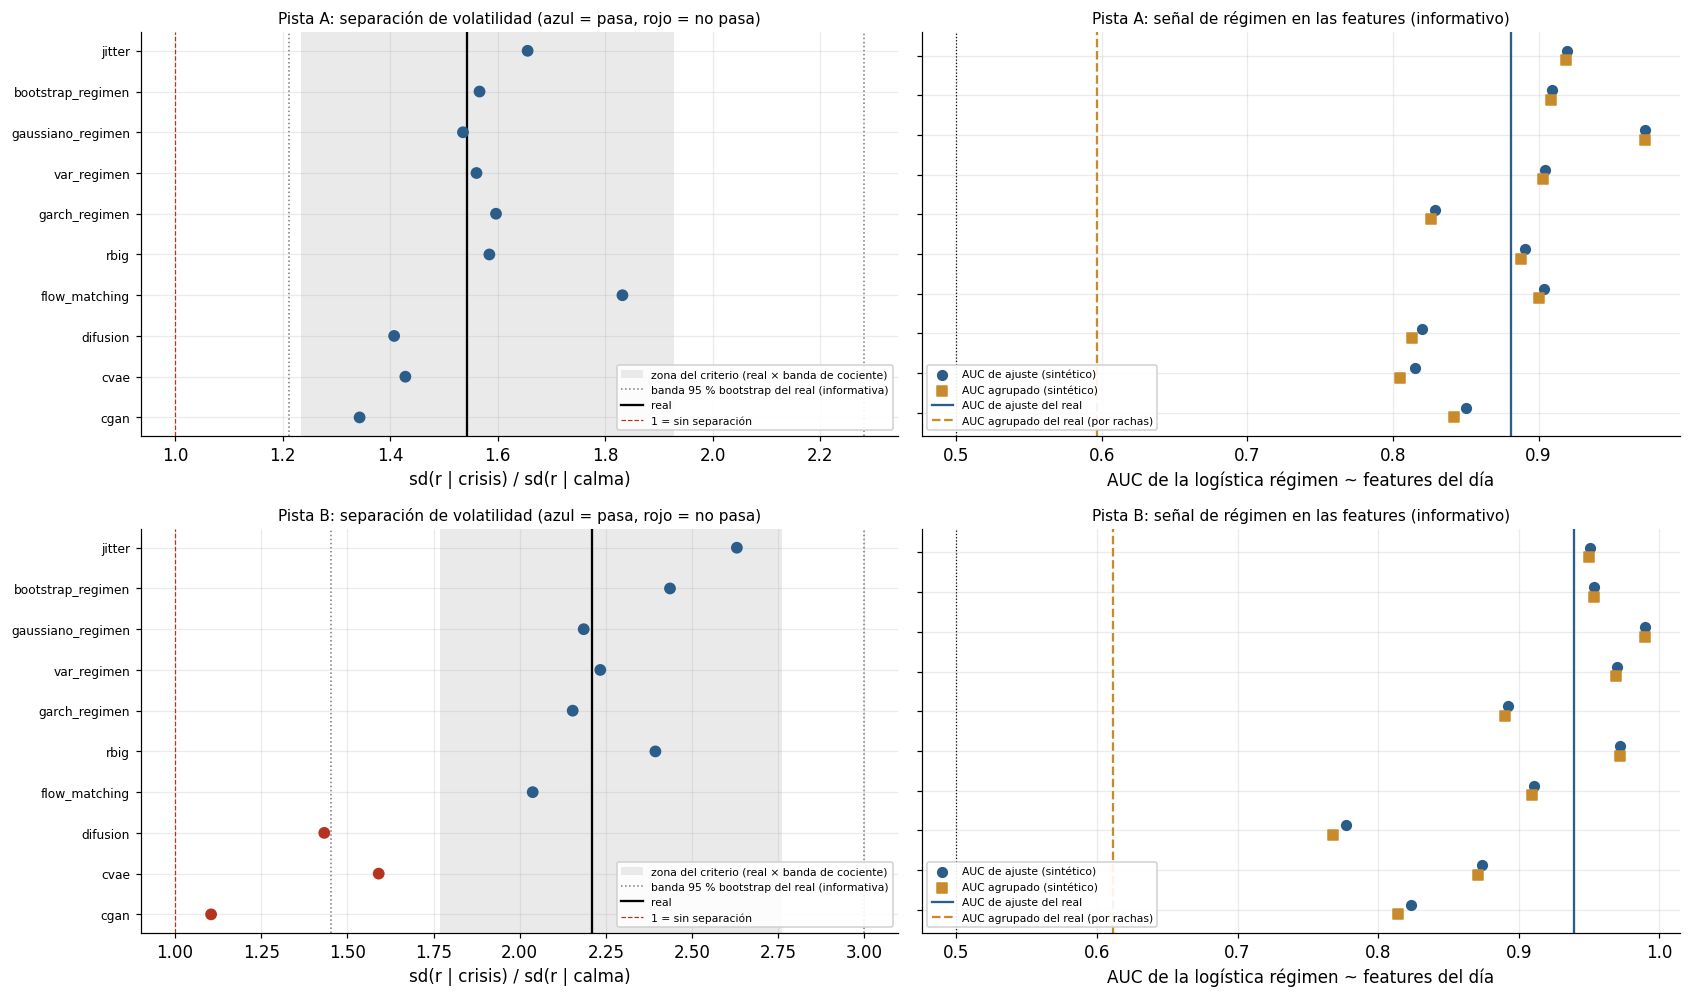

In [16]:
COND = {}
for t in PISTAS:
    c = TABLAS[t]['condicionamiento']
    pieza = lambda m: c[c['metrica'] == m].set_index('generador').reindex(GENERADORES)
    sep, med, auc, aj = (pieza(m) for m in ('separacion_vol', 'media_ret_crisis_pb', 'auc_regimen', 'auc_regimen_ajuste'))
    clave = c[c['metrica'].isin(REGLAS['condicionamiento'])]
    pasa = clave.assign(ok=clave['cociente'].astype(float).between(*BANDA)).groupby('generador')['ok'].all().reindex(GENERADORES)
    COND[t] = pd.DataFrame({
        'sep. vol real': sep['real'], 'banda inf': sep['banda_inf'], 'banda sup': sep['banda_sup'],
        'sep. vol sint.': sep['sintetico'], 'en banda bootstrap': sep['en_banda'], 'cociente': sep['cociente'], 'pasa': pasa,
        'ret. crisis real (pb)': med['real'], 'ret. crisis sint. (pb)': med['sintetico'], 'ret. en banda': med['en_banda'],
        'AUC agrupado real': auc['real'], 'AUC agrupado sint.': auc['sintetico'],
        'AUC ajuste real': aj['real'], 'AUC ajuste sint.': aj['sintetico'], 'cociente AUC ajuste': aj['cociente']})
    display(Markdown(f'**Pista {t}** — condicionamiento al régimen (criterio: cociente de '
                     f'{", ".join(REGLAS["condicionamiento"])} en la banda de cociente)'))
    estilo = pd.DataFrame('', index=COND[t].index, columns=COND[t].columns)
    estilo.loc[~COND[t]['pasa'].astype(bool), ['sep. vol sint.', 'cociente', 'pasa']] = f'background-color: {COLOR_FALLA}'
    display(COND[t].style.format('{:.2f}', subset=[k for k in COND[t].columns
                                                   if k not in ('pasa', 'ret. en banda', 'en banda bootstrap')])
            .apply(lambda _: estilo, axis=None))

fig, axes = plt.subplots(len(PISTAS), 2, figsize=(15.5, 4.6 * len(PISTAS)))
axes = np.atleast_2d(axes)
y = np.arange(len(GENERADORES))[::-1]
for i, t in enumerate(PISTAS):
    d = COND[t]
    ax = axes[i, 0]
    real = d['sep. vol real'].iloc[0]
    ax.axvspan(BANDA[0] * real, BANDA[1] * real, color=viz.C_NA, alpha=0.9, lw=0, label='zona del criterio (real × banda de cociente)')
    ax.axvline(d['banda inf'].iloc[0], color=viz.C_NEG, ls=':', lw=1, label='banda 95 % bootstrap del real (informativa)')
    ax.axvline(d['banda sup'].iloc[0], color=viz.C_NEG, ls=':', lw=1)
    ax.axvline(real, color='black', lw=1.5, label='real')
    ax.scatter(d['sep. vol sint.'], y, c=[viz.C_LONG if p else viz.C_CRISIS for p in d['pasa']], s=45, zorder=3)
    ax.axvline(1, color=viz.C_CRISIS, lw=0.8, ls='--', label='1 = sin separación')
    ax.set_yticks(y, GENERADORES, fontsize=8)
    ax.set_xlabel('sd(r | crisis) / sd(r | calma)')
    ax.set_title(f'Pista {t}: separación de volatilidad (azul = pasa, rojo = no pasa)', fontsize=10)
    ax.legend(fontsize=7, loc='lower right', framealpha=0.9)
    ax = axes[i, 1]
    ax.scatter(d['AUC ajuste sint.'], y + 0.12, color=viz.C_LONG, s=40, label='AUC de ajuste (sintético)', zorder=3)
    ax.scatter(d['AUC agrupado sint.'], y - 0.12, color=viz.C_SHORT, marker='s', s=36, label='AUC agrupado (sintético)', zorder=3)
    ax.axvline(d['AUC ajuste real'].iloc[0], color=viz.C_LONG, lw=1.5, label='AUC de ajuste del real')
    ax.axvline(d['AUC agrupado real'].iloc[0], color=viz.C_SHORT, lw=1.5, ls='--', label='AUC agrupado del real (por rachas)')
    ax.axvline(0.5, color='black', lw=0.8, ls=':')
    ax.set_yticks(y, [''] * len(y))
    ax.set_xlabel('AUC de la logística régimen ~ features del día')
    ax.set_title(f'Pista {t}: señal de régimen en las features (informativo)', fontsize=10)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.9)
fig.tight_layout(); guardar(fig, 'condicionamiento'); plt.show()

In [17]:
SENALADOS_15 = ['cgan', 'difusion', 'cvae']   # condicionamiento débil en la pista B según el 15 (§7.3, limitación 9)
lineas = []
for t in PISTAS:
    d = COND[t]
    fallan = d.index[~d['pasa'].astype(bool)]
    dif_auc = (d['AUC agrupado sint.'] - d['AUC ajuste sint.']).abs().max()
    rescate = [n for n in fallan if bool(d.loc[n, 'en banda bootstrap'])]
    lineas.append(
        f"- **Pista {t}**: separación real {fmt(d['sep. vol real'].iloc[0])} (banda bootstrap {fmt(d['banda inf'].iloc[0])}–"
        f"{fmt(d['banda sup'].iloc[0])}). {pasan(d.index[d['pasa'].astype(bool)]).capitalize()}"
        + (('; no pasan ' + ', '.join(f"`{n}` (separación {fmt(d.loc[n, 'sep. vol sint.'])}, cociente "
                                      f"{fmt(d.loc[n, 'cociente'])})" for n in fallan)) if len(fallan) else '') + '. '
        + (f"Suspenden por cociente aunque su separación cae en la banda bootstrap del real: {lista(rescate)} (el criterio "
           f"decide solo por cociente). " if rescate else 'Ningún generador que suspenda cae en la banda bootstrap del real. ')
        + f"Retorno medio en crisis: real {fmt(d['ret. crisis real (pb)'].iloc[0], 1)} pb; sintético de "
          f"{fmt(d['ret. crisis sint. (pb)'].min(), 1)} a {fmt(d['ret. crisis sint. (pb)'].max(), 1)} pb.")
    lineas.append(
        f"  - AUC de la logística en el real: {fmt(d['AUC agrupado real'].iloc[0])} agrupado por rachas frente a "
        f"{fmt(d['AUC ajuste real'].iloc[0])} de ajuste; en los sintéticos los dos casi coinciden (diferencia máxima "
        f"{fmt(dif_auc, 3)}), porque una sola ley condicional no tiene episodios heterogéneos que penalicen al modelo. "
        f"AUC de ajuste sintético de {fmt(d['AUC ajuste sint.'].min())} (`{d['AUC ajuste sint.'].idxmin()}`) a "
        f"{fmt(d['AUC ajuste sint.'].max())} (`{d['AUC ajuste sint.'].idxmax()}`).")
if 'B' in COND:
    b = COND['B']
    lineas.append('- **Lo que señaló el 15 en la pista B**: ' + '; '.join(
        f"`{n}`: separación {fmt(b.loc[n, 'sep. vol sint.'])} (cociente {fmt(b.loc[n, 'cociente'])}, "
        f"{'pasa' if b.loc[n, 'pasa'] else 'no pasa'}), AUC de ajuste {fmt(b.loc[n, 'AUC ajuste sint.'])}"
        for n in SENALADOS_15 if n in b.index) + f" (real: separación {fmt(b['sep. vol real'].iloc[0])}, AUC de ajuste "
        f"{fmt(b['AUC ajuste real'].iloc[0])}).")
md('**(c) Lectura (cifras de la tabla).**', *lineas)

**(c) Lectura (cifras de la tabla).**
- **Pista A**: separación real 1,54 (banda bootstrap 1,21–2,28). Pasan todos (10). Ningún generador que suspenda cae en la banda bootstrap del real. Retorno medio en crisis: real -14,3 pb; sintético de -18,0 a -7,5 pb.
  - AUC de la logística en el real: 0,60 agrupado por rachas frente a 0,88 de ajuste; en los sintéticos los dos casi coinciden (diferencia máxima 0,010), porque una sola ley condicional no tiene episodios heterogéneos que penalicen al modelo. AUC de ajuste sintético de 0,81 (`cvae`) a 0,97 (`gaussiano_regimen`).
- **Pista B**: separación real 2,21 (banda bootstrap 1,45–3,00). Pasan todos salvo `difusion`, `cvae`, `cgan`; no pasan `difusion` (separación 1,43, cociente 0,65), `cvae` (separación 1,59, cociente 0,72), `cgan` (separación 1,10, cociente 0,50). Suspenden por cociente aunque su separación cae en la banda bootstrap del real: `cvae` (el criterio decide solo por cociente). Retorno medio en crisis: real -19,5 pb; sintético de -20,5 a -3,2 pb.
  - AUC de la logística en el real: 0,61 agrupado por rachas frente a 0,94 de ajuste; en los sintéticos los dos casi coinciden (diferencia máxima 0,009), porque una sola ley condicional no tiene episodios heterogéneos que penalicen al modelo. AUC de ajuste sintético de 0,78 (`difusion`) a 0,99 (`gaussiano_regimen`).
- **Lo que señaló el 15 en la pista B**: `cgan`: separación 1,10 (cociente 0,50, no pasa), AUC de ajuste 0,82; `difusion`: separación 1,43 (cociente 0,65, no pasa), AUC de ajuste 0,78; `cvae`: separación 1,59 (cociente 0,72, no pasa), AUC de ajuste 0,87 (real: separación 2,21, AUC de ajuste 0,94).

**(d) Límites.** La separación de volatilidad solo mira el retorno: un generador puede separar bien
la volatilidad y mal los niveles de las demás features (eso lo ve, de forma informativa, el AUC de
ajuste, que es lineal). La deriva en crisis es una media sobre pocos episodios con derivas muy
distintas (15, §2.2) y por eso no es criterio. Las duraciones las impone la cadena común: este
notebook no puede validar la dinámica de régimen de ningún generador, solo su ley condicional.

<a id="s4"></a>
## 4. Correlaciones por régimen (informativo)

**(a) Idea y supuestos.** Que las correlaciones cambian en las crisis es uno de los hechos
estilizados que más importan a un detector multivariante. Para cada régimen se compara la matriz de
correlación de Pearson real $C^r_k$ con la sintética $C^s_k$ (trayectorias apiladas) mediante la
distancia de Frobenius normalizada, la raíz del error cuadrático medio de las $d(d-1)/2$
correlaciones,

$$
D_k = \frac{\lVert C^r_k - C^s_k \rVert_F}{\sqrt{d(d-1)}},
$$

y la misma distancia entre los **saltos** $J = C_{\text{crisis}} - C_{\text{calma}}$ real y
sintético. La referencia es la distancia entre el real y un remuestreo del real (bloques en calma,
episodios en crisis): su mediana es el nivel típico de ruido y su p95 la banda; como un remuestreo
comparte días con el real, es más estricta que la distancia entre dos muestras independientes.
Tras ver el veredicto, el criterio pasó a ser **informativo** (decisión iii.3): con el múltiplo del
p95 del yaml no discriminaba y con uno solo suspendía el control de fidelidad (contrafactual en
§8.2).

**(b) Tabla y figura.**

**Pista A** — distancia de Frobenius por régimen

**Pista B** — distancia de Frobenius por régimen

figura -> results/sinteticos/validacion/correlaciones_por_regimen.png


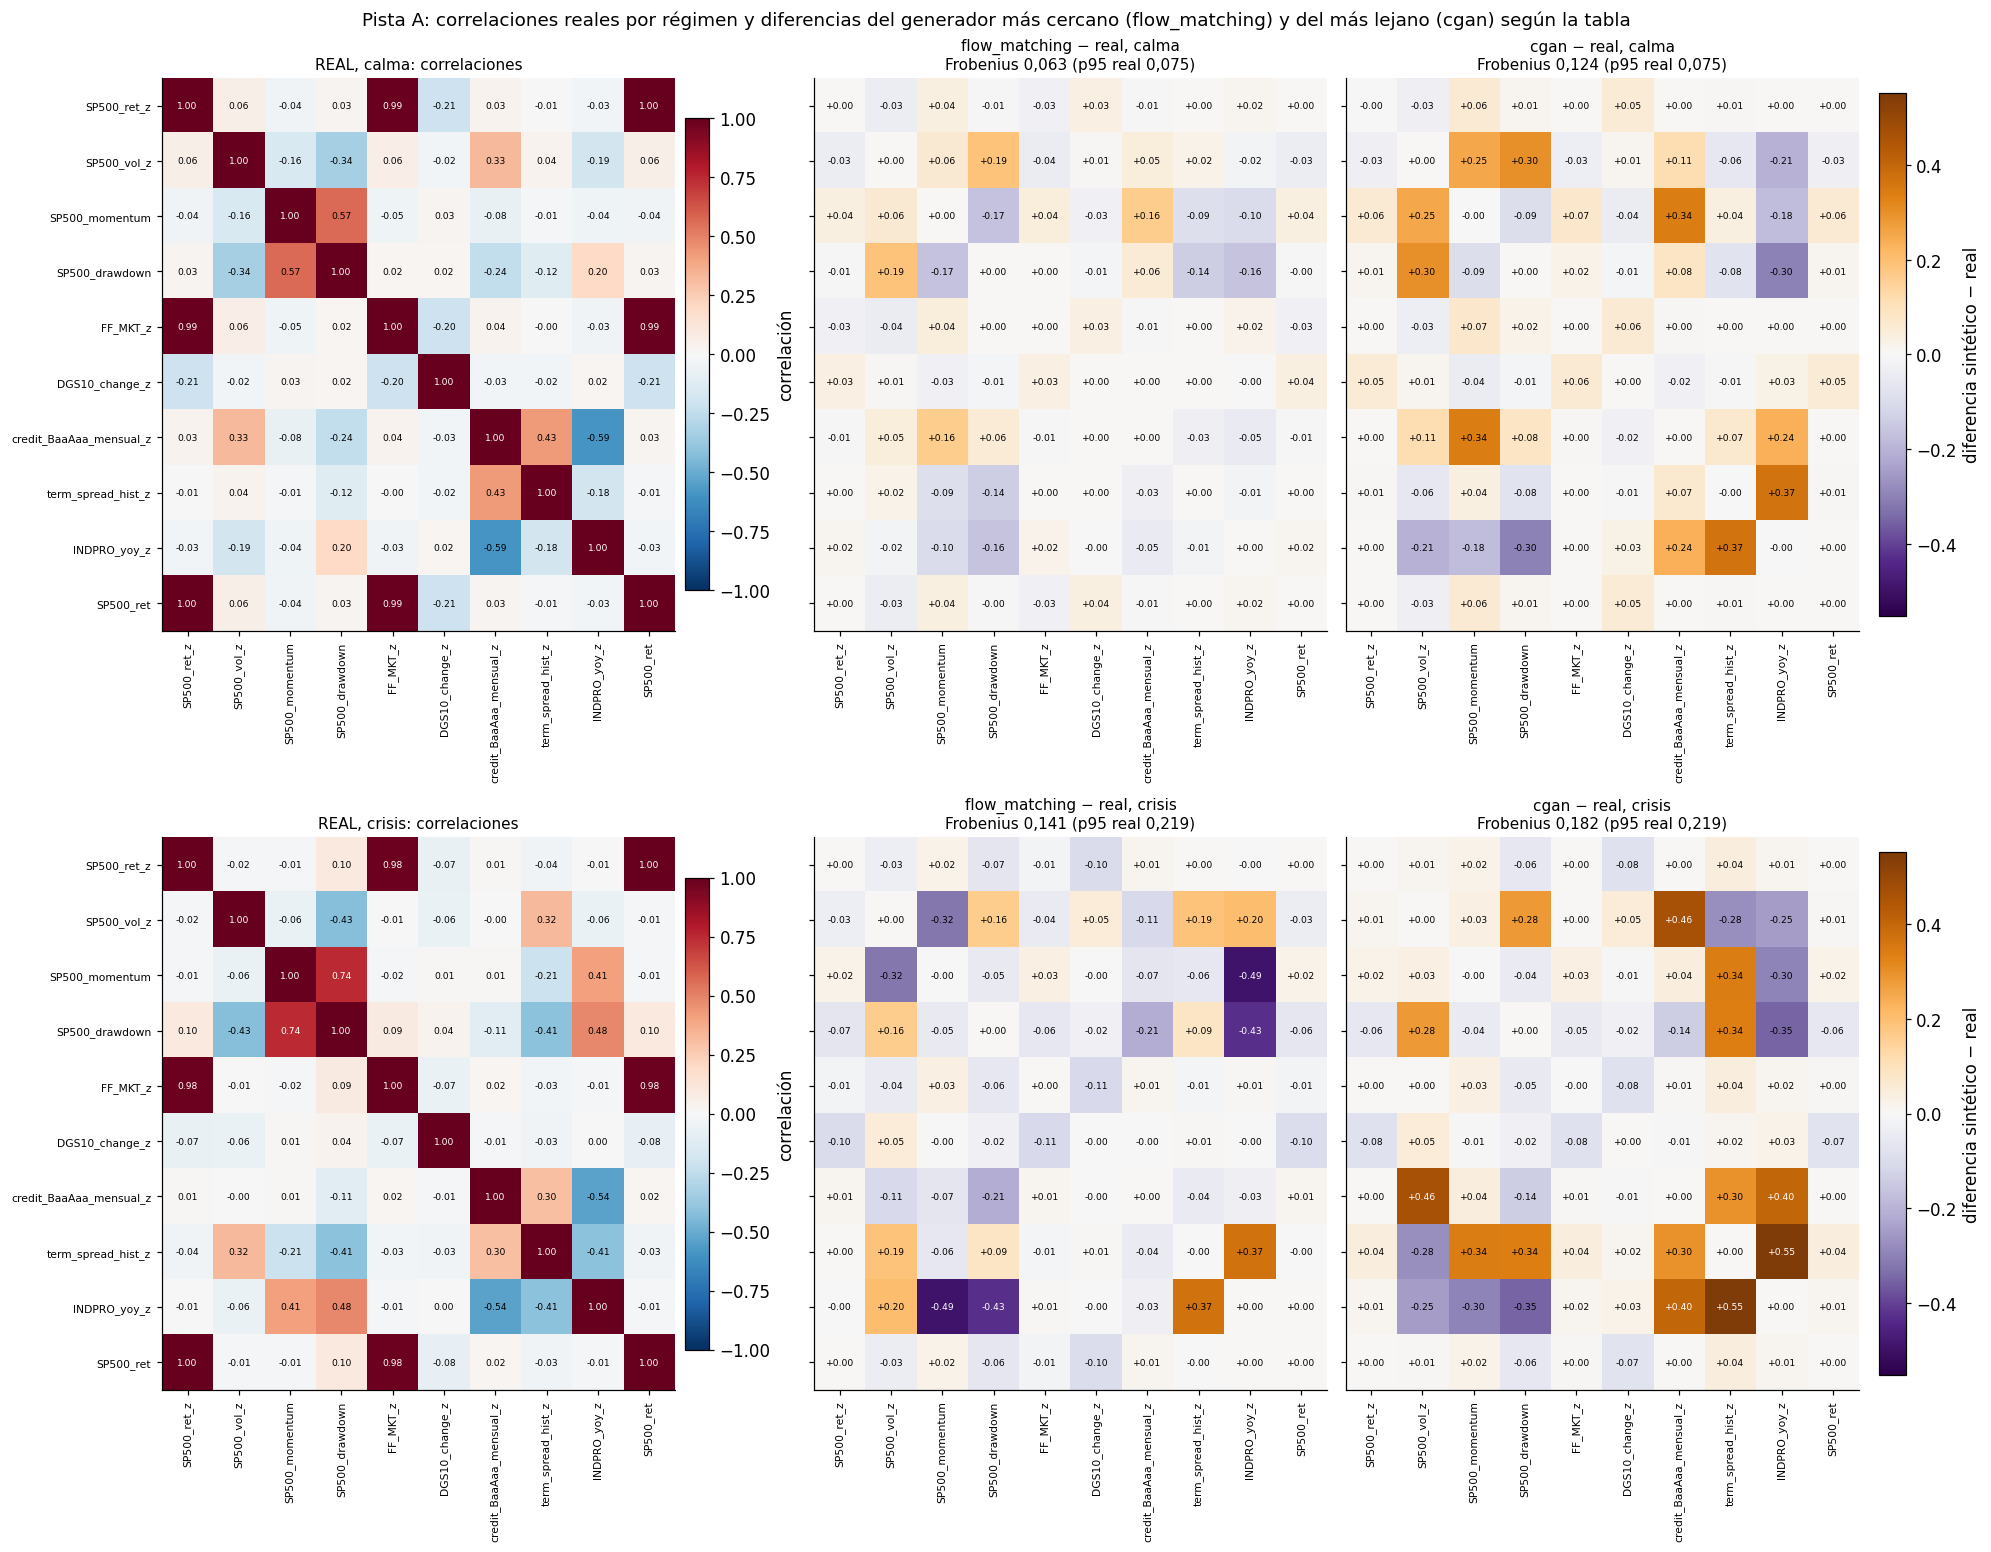

In [18]:
FACTOR = float(REGLAS['correlaciones_factor_p95'])
CORR = {}
for t in PISTAS:
    d = TABLAS[t]['distancia_correlaciones']
    fr = d[d['metrica'] == 'frobenius']
    salto = d[d['metrica'] == 'salto_correlacion'].set_index('generador').reindex(GENERADORES)
    tabla = {}
    for regimen in REGIMENES:
        s = fr[fr['regimen'] == regimen].set_index('generador').reindex(GENERADORES)
        tabla[(regimen, 'Frobenius sint.')] = s['sintetico']
        tabla[(regimen, 'ruido real (mediana)')] = s['real']
        tabla[(regimen, 'p95 real')] = s['banda_sup']
        tabla[(regimen, 'sint. / p95')] = s['sintetico'] / s['banda_sup']
    tabla[('salto crisis−calma', 'distancia sint.')] = salto['sintetico']
    tabla[('salto crisis−calma', 'p95 real')] = salto['banda_sup']
    tabla[('salto crisis−calma', 'en banda')] = salto['en_banda']
    CORR[t] = pd.DataFrame(tabla)
    CORR[t][('informativo', f'≤ {FACTOR:g} × p95')] = (CORR[t][[(r, 'sint. / p95') for r in REGIMENES]] <= FACTOR).all(axis=1)
    CORR[t][('informativo', '≤ 1 × p95')] = (CORR[t][[(r, 'sint. / p95') for r in REGIMENES]] <= 1).all(axis=1)
    display(Markdown(f'**Pista {t}** — distancia de Frobenius por régimen'))
    display(CORR[t].style.format('{:.3f}', subset=[c for c in CORR[t].columns if c[0] in REGIMENES + ('salto crisis−calma',)
                                                   and c[1] != 'en banda']))

# Generadores representativos de la pista principal, elegidos por la tabla: el más cercano y el más lejano al real
t = PISTA_PRINCIPAL
peor_cociente = CORR[t][[(r, 'sint. / p95') for r in REGIMENES]].max(axis=1)
REPRESENTATIVOS = [peor_cociente.idxmin(), peor_cociente.idxmax()]
cols = list(PANEL[t].columns)
reg_real = REG[t].to_numpy()
MATRICES = {('real', k): np.corrcoef(PANEL[t][cols].to_numpy()[reg_real == k], rowvar=False) for k in ETIQ_REG}
for n in REPRESENTATIVOS:
    tray = persistencia.cargar_trayectorias(n, t)
    S = np.vstack([tr[cols].to_numpy(dtype=float) for tr in tray])
    R = np.concatenate([tr[datos.COL_REGIMEN].to_numpy() for tr in tray])
    for k in ETIQ_REG:
        MATRICES[(n, k)] = np.corrcoef(S[R == k], rowvar=False)
    del tray, S, R
lim = max(np.nanmax(np.abs(MATRICES[(n, k)] - MATRICES[('real', k)])) for n in REPRESENTATIVOS for k in ETIQ_REG)
fig, axes = plt.subplots(2, 3, figsize=(18, 14), layout='constrained')
for i, k in enumerate(ETIQ_REG):
    for j, n in enumerate(['real'] + REPRESENTATIVOS):
        ax = axes[i, j]
        if n == 'real':
            M_ = MATRICES[('real', k)]
            inf.dibujar_heatmap(ax, pd.DataFrame(M_, index=cols, columns=cols), cmap='RdBu_r', vmin=-1, vmax=1,
                                fmt='{:.2f}', fontsize=6, titulo=f'REAL, {ETIQ_REG[k]}: correlaciones')
        else:
            M_ = MATRICES[(n, k)] - MATRICES[('real', k)]
            inf.dibujar_heatmap(ax, pd.DataFrame(M_, index=cols, columns=cols), cmap='PuOr_r', vmin=-lim, vmax=lim,
                                fmt='{:+.2f}', fontsize=6, umbral_blanco=0.7,
                                titulo=f'{n} − real, {ETIQ_REG[k]}\nFrobenius {fmt(CORR[t].loc[n, (ETIQ_REG[k], "Frobenius sint.")], 3)} '
                                       f'(p95 real {fmt(CORR[t].loc[n, (ETIQ_REG[k], "p95 real")], 3)})')
        ax.set_xticks(range(len(cols)), cols, rotation=90, fontsize=7)
        ax.set_yticks(range(len(cols)), cols if j == 0 else [''] * len(cols), fontsize=7)
        ax.grid(False)
for i in range(2):
    fig.colorbar(axes[i, 0].images[0], ax=axes[i, 0], fraction=0.046, pad=0.02, label='correlación')
    fig.colorbar(axes[i, 2].images[0], ax=list(axes[i, 1:]), fraction=0.025, pad=0.02, label='diferencia sintético − real')
fig.suptitle(f'Pista {t}: correlaciones reales por régimen y diferencias del generador más cercano ({REPRESENTATIVOS[0]}) '
             f'y del más lejano ({REPRESENTATIVOS[1]}) según la tabla', fontsize=12)
guardar(fig, 'correlaciones_por_regimen'); plt.show()

In [19]:
lineas = []
for t in PISTAS:
    c = CORR[t]
    rat = {r: c[(r, 'sint. / p95')] for r in REGIMENES}
    salto_ok = c.index[c[('salto crisis−calma', 'en banda')].fillna(False).astype(bool)]
    lineas.append(
        f"- **Pista {t}**: ruido real (mediana) {fmt(c[('calma', 'ruido real (mediana)')].iloc[0], 3)} en calma y "
        f"{fmt(c[('crisis', 'ruido real (mediana)')].iloc[0], 3)} en crisis, p95 {fmt(c[('calma', 'p95 real')].iloc[0], 3)} y "
        f"{fmt(c[('crisis', 'p95 real')].iloc[0], 3)}. Cociente sintético/p95 de {fmt(rat['calma'].min())} a "
        f"{fmt(rat['calma'].max())} en calma y de {fmt(rat['crisis'].min())} a {fmt(rat['crisis'].max())} en crisis. Por "
        f"debajo de {fmt(FACTOR, 1)} × p95 en los dos regímenes: {lista(c.index[c[('informativo', f'≤ {FACTOR:g} × p95')]])}; "
        f"por debajo de 1 × p95: {lista(c.index[c[('informativo', '≤ 1 × p95')]])}. Salto de correlación crisis−calma dentro "
        f"de la banda del real: {lista(salto_ok)}.")
md('**(c) Lectura (cifras de la tabla).**', *lineas,
   f"- En la figura (pista {PISTA_PRINCIPAL}), `{REPRESENTATIVOS[0]}` es el generador con el menor cociente máximo entre "
   f"regímenes y `{REPRESENTATIVOS[1]}` el de mayor; la elección la hace la celda con la tabla. Las diferencias "
   f"se dibujan con la misma escala simétrica en los cuatro paneles (±{fmt(lim)}).",
   '- La calma, con muchos más días, tiene una referencia mucho más estrecha que la crisis: un mismo error absoluto de '
   'correlación pesa más en calma.')

**(c) Lectura (cifras de la tabla).**
- **Pista A**: ruido real (mediana) 0,048 en calma y 0,117 en crisis, p95 0,075 y 0,219. Cociente sintético/p95 de 0,85 a 1,65 en calma y de 0,53 a 0,83 en crisis. Por debajo de 2,0 × p95 en los dos regímenes: todos (10); por debajo de 1 × p95: `garch_regimen`, `flow_matching`, `cvae`. Salto de correlación crisis−calma dentro de la banda del real: todos (10).
- **Pista B**: ruido real (mediana) 0,090 en calma y 0,088 en crisis, p95 0,216 y 0,407. Cociente sintético/p95 de 0,62 a 1,50 en calma y de 0,34 a 0,81 en crisis. Por debajo de 2,0 × p95 en los dos regímenes: todos (10); por debajo de 1 × p95: `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`. Salto de correlación crisis−calma dentro de la banda del real: todos (10).
- En la figura (pista A), `flow_matching` es el generador con el menor cociente máximo entre regímenes y `cgan` el de mayor; la elección la hace la celda con la tabla. Las diferencias se dibujan con la misma escala simétrica en los cuatro paneles (±0,55).
- La calma, con muchos más días, tiene una referencia mucho más estrecha que la crisis: un mismo error absoluto de correlación pesa más en calma.

**(d) Límites.** La correlación de Pearson con trayectorias apiladas mezcla la variación entre
trayectorias con la de dentro de cada una; las columnas casi constantes dentro de un régimen
(escalones mensuales) dan correlaciones inestables. La distancia resume la matriz en un número; la
figura enseña qué pares fallan para dos generadores. La referencia real frente a remuestreo es
estricta por construcción: ningún múltiplo fijo de su p95 separaba a los generadores, y por eso la
dimensión es informativa.

<a id="s5"></a>
## 5. Discriminador real frente a sintético

**(a) Idea y supuestos.** Test de dos muestras con clasificador (Lopez-Paz y Oquab, 2017): si un
clasificador entrenado para separar ventanas reales de sintéticas no supera el azar fuera de
muestra, las dos muestras son indistinguibles **para esa familia de clasificadores**. Cada serie
se corta en ventanas no solapadas de `largo_ventana` sesiones; cada ventana se resume por columna
(media, desviación, mínimo, máximo, último menos primero y autocorrelación a un día; curtosis y
media de $|r|$ para el retorno) y un `HistGradientBoostingClassifier` de parámetros fijos y
modestos las clasifica. La métrica es el AUC fuera de pliegue,

$$
\mathrm{AUC} = \Pr\big(\hat p(W^{r}) > \hat p(W^{s})\big),
$$

con $\hat p$ la probabilidad de «real» y $W^r$, $W^s$ ventanas de prueba real y sintética: 0,5 es
indistinguible y 1, trivialmente separable. La validación cruzada es **agrupada** (bloques
cronológicos del real; cada trayectoria sintética entera en un pliegue) y las clases se equilibran
submuestreando las ventanas sintéticas.

Se calcula con **todas las columnas públicas, re-derivadas incluidas** (criterio, umbral
`discriminador_auc_max`) y con las `columnas_informativas` (variante fuera del veredicto). En
**crisis** solo se publica el **orden** entre generadores: con un puñado de episodios reales, el
valor del AUC en crisis no es estable (lección del taller previo).

**Calibración de la prueba.** Para saber cuánto de la separación es propiedad de la prueba y no del
generador se añaden dos cosas: (1) un control **real frente a real** con la misma construcción
(primera mitad del tramo de entrenamiento como «real» y la segunda mitad, en trozos, como
«trayectorias»), que mide lo separable que es el real de sí mismo en otra época; y (2) la
**descomposición por grupos de columnas** (modeladas lentas, modeladas diarias, re-derivadas y solo
el retorno) para `GEN_GRUPOS` y para el control.

**Un artefacto documentado: AUC por debajo de 0,5 indica copia, pero solo donde la copia es
visible.** Si un generador copia días o tramos reales, las copias de las ventanas reales que caen
en el pliegue de prueba están en los pliegues de entrenamiento etiquetadas como **sintéticas**: el
clasificador aprende que esas configuraciones son «sintéticas» y marca como tales a las reales
originales, y el AUC cae por debajo del azar. Eso ocurre en las variantes en las que la ventana
copiada es idéntica a la original (solo el retorno, o la calma); con todas las columnas, las
re-derivadas y las costuras entre bloques copiados delatan también a los que copian, que se separan
como los demás. El discriminador **no detecta la copia**: de eso se encarga la memorización (§7).
El veredicto anota «indicio de copia» por debajo de un corte (`CORTE_COPIA`, impreso en §1).

**(b) Tablas y figuras.**

**Pista A** — AUC fuera de pliegue (criterio: AUC global con todas las columnas ≤ 0,75). Ventanas reales: 536 en total, 424 de calma pura y 106 de crisis. En crisis, 1 = el más separable.

**Pista B** — AUC fuera de pliegue (criterio: AUC global con todas las columnas ≤ 0,75). Ventanas reales: 128 en total, 92 de calma pura y 34 de crisis. En crisis, 1 = el más separable.

**Pista A** — AUC global por grupo de columnas (calibración; fila 1 = control real frente a real)

grupo,todas,modeladas lentas,modeladas diarias,re-derivadas,solo SP500_ret
real frente a real,0.735,0.669,0.792,0.701,0.668
jitter,0.994,0.995,0.407,0.615,0.418
bootstrap_regimen,0.777,0.704,0.348,0.622,0.418
garch_regimen,0.937,0.978,0.733,0.656,0.580


   grupos: modeladas lentas: credit_BaaAaa_mensual_z, term_spread_hist_z, INDPRO_yoy_z | modeladas diarias: FF_MKT_z, DGS10_change_z | re-derivadas: SP500_ret_z, SP500_vol_z, SP500_momentum, SP500_drawdown | solo SP500_ret: SP500_ret


**Pista B** — AUC global por grupo de columnas (calibración; fila 1 = control real frente a real)

grupo,todas,modeladas lentas,modeladas diarias,re-derivadas,solo SP500_ret
real frente a real,0.931,0.894,0.810,0.910,0.829
jitter,0.996,0.996,0.401,0.552,0.440
bootstrap_regimen,0.841,0.826,0.394,0.557,0.460
garch_regimen,0.923,0.891,0.601,0.568,0.530


   grupos: modeladas lentas: credit_BaaAaa_mensual_z, term_spread_hist_z, INDPRO_yoy_z, VIX_level_z, MOVE_level_z, credit_BAA10Y_z, corr_spx_bond | modeladas diarias: FF_MKT_z, DGS10_change_z, DFII10_change_z | re-derivadas: SP500_ret_z, SP500_vol_z, SP500_momentum, SP500_drawdown | solo SP500_ret: SP500_ret


figura -> results/sinteticos/validacion/discriminador_auc.png


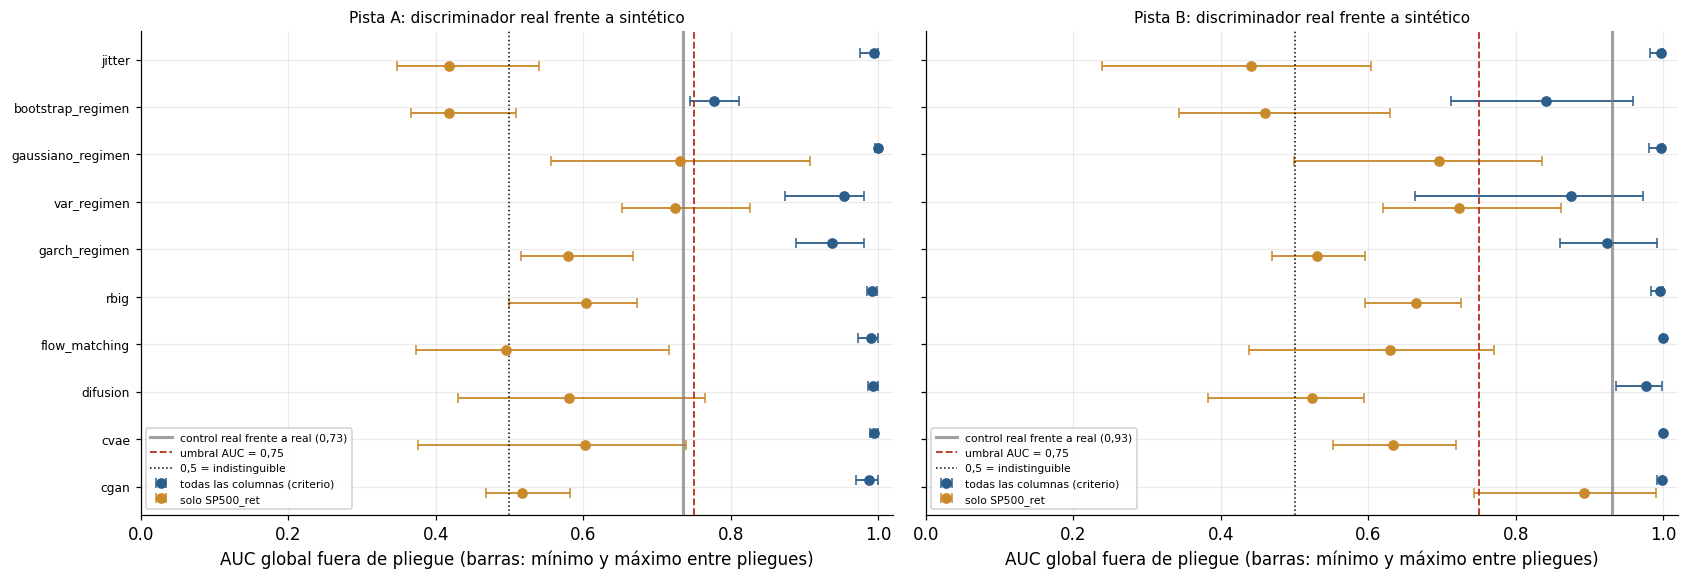

In [20]:
AUC_MAX = float(UMBRALES['discriminador_auc_max'])
DISCR = {}
for t in PISTAS:
    tabla = {}
    for variante, dim in (('todas las columnas', 'discriminador'), ('informativa', 'discriminador_informativo')):
        d = TABLAS[t][dim]
        a = d[d['metrica'] == 'auc']
        piv = a.pivot(index='generador', columns='regimen', values='sintetico').reindex(GENERADORES)
        glob = a[a['regimen'] == 'todos'].set_index('generador').reindex(GENERADORES)
        tabla[(variante, 'AUC global')] = piv['todos']
        tabla[(variante, 'mín. pliegues')] = glob['banda_inf']
        tabla[(variante, 'máx. pliegues')] = glob['banda_sup']
        tabla[(variante, 'AUC calma')] = piv['calma']
        tabla[(variante, 'orden en crisis')] = piv['crisis'].rank(method='min', ascending=False).astype('Int64')
    DISCR[t] = pd.DataFrame(tabla)
    DISCR[t][('criterio', 'pasa')] = DISCR[t][('todas las columnas', 'AUC global')] <= AUC_MAX
    nv = TABLAS[t]['discriminador']
    nv = nv[(nv['metrica'] == 'n_ventanas') & (nv['generador'] == GENERADORES[0])].set_index('regimen')['real']
    display(Markdown(f'**Pista {t}** — AUC fuera de pliegue (criterio: AUC global con todas las columnas ≤ {fmt(AUC_MAX)}). '
                     f'Ventanas reales: {int(nv["todos"])} en total, {int(nv["calma"])} de calma pura y {int(nv["crisis"])} '
                     f'de crisis. En crisis, 1 = el más separable.'))
    estilo = pd.DataFrame('', index=DISCR[t].index, columns=DISCR[t].columns)
    estilo.loc[~DISCR[t][('criterio', 'pasa')], [('todas las columnas', 'AUC global'), ('criterio', 'pasa')]] = \
        f'background-color: {COLOR_FALLA}'
    display(DISCR[t].style.format('{:.3f}', subset=[c for c in DISCR[t].columns if c[1] not in ('orden en crisis', 'pasa')])
            .apply(lambda _: estilo, axis=None))

# calibración: control real frente a real y descomposición por grupos de columnas
CALIB = {}
for t in PISTAS:
    g = TABLAS[t]['discriminador_grupos']
    g = g[(g['metrica'] == 'auc') & (g['regimen'] == 'todos')].pivot(index='generador', columns='grupo', values='sintetico')
    r = CONTROL[t]['discriminador_real']
    r = r[(r['metrica'] == 'auc') & (r['regimen'] == 'todos')].set_index('grupo')['sintetico']
    tabla = pd.concat([r.rename('real frente a real').to_frame().T, g.reindex(GEN_GRUPOS)])
    CALIB[t] = tabla[[c for c in GRUPOS[t] if c in tabla.columns]]
    display(Markdown(f'**Pista {t}** — AUC global por grupo de columnas (calibración; fila 1 = control real frente a real)'))
    display(CALIB[t].style.format('{:.3f}', na_rep='—'))
    print('   grupos: ' + ' | '.join(f'{k}: {", ".join(v)}' for k, v in GRUPOS[t].items() if k != 'todas'))

fig, axes = plt.subplots(1, len(PISTAS), figsize=(15.5, 5.4), sharey=True)
y = np.arange(len(GENERADORES))[::-1]
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    for (variante, color, desp, rot) in (('todas las columnas', viz.C_LONG, 0.13, 'todas las columnas (criterio)'),
                                         ('informativa', viz.C_SHORT, -0.13, 'solo ' + ', '.join(DISC['columnas_informativas']))):
        d = DISCR[t][variante]
        ax.errorbar(d['AUC global'], y + desp, xerr=[d['AUC global'] - d['mín. pliegues'], d['máx. pliegues'] - d['AUC global']],
                    fmt='o', color=color, ms=6, capsize=3, lw=1.2, label=rot)
    ax.axvline(CALIB[t].loc['real frente a real', 'todas'], color=viz.C_NEG, lw=2, alpha=0.7,
               label=f"control real frente a real ({fmt(CALIB[t].loc['real frente a real', 'todas'], 2)})")
    ax.axvline(AUC_MAX, color=viz.C_CRISIS, ls='--', lw=1.2, label=f'umbral AUC = {fmt(AUC_MAX)}')
    ax.axvline(0.5, color='black', ls=':', lw=1, label='0,5 = indistinguible')
    ax.set_yticks(y, GENERADORES, fontsize=8)
    ax.set_xlim(0, 1.02)
    ax.set_xlabel('AUC global fuera de pliegue (barras: mínimo y máximo entre pliegues)')
    ax.set_title(f'Pista {t}: discriminador real frente a sintético', fontsize=10)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.9)
fig.tight_layout(); guardar(fig, 'discriminador_auc'); plt.show()

In [21]:
lineas = []
for t in PISTAS:
    d = DISCR[t]
    todas, info = d['todas las columnas'], d['informativa']
    bajo = {n: [f'{v} ({c})' for v in ('todas las columnas', 'informativa') for c in ('AUC global', 'AUC calma')
                if d.loc[n, (v, c)] < CORTE_COPIA] for n in GENERADORES}
    bajo = {n: v for n, v in bajo.items() if v}
    orden = todas['orden en crisis'].sort_values()
    cal = CALIB[t]
    lineas.append(
        f"- **Pista {t}**. Con todas las columnas el AUC global va de {fmt(todas['AUC global'].min(), 3)} "
        f"(`{todas['AUC global'].idxmin()}`) a {fmt(todas['AUC global'].max(), 3)} (`{todas['AUC global'].idxmax()}`): "
        f"por debajo del umbral ({fmt(AUC_MAX)}): {lista(d.index[d[('criterio', 'pasa')]])}. Con la variante informativa, de "
        f"{fmt(info['AUC global'].min(), 3)} a {fmt(info['AUC global'].max(), 3)}; quedarían por debajo del umbral "
        f"{lista(info.index[info['AUC global'] <= AUC_MAX])}.")
    lineas.append(
        f"  - **Calibración.** El control real frente a real da un AUC global de {fmt(cal.loc['real frente a real', 'todas'], 3)} "
        f"con todas las columnas (" + ', '.join(f"{g}: {fmt(cal.loc['real frente a real', g], 3)}" for g in cal.columns if g != 'todas')
        + f"). El control de fidelidad que copia filas reales (`bootstrap_regimen`) da {fmt(cal.loc['bootstrap_regimen', 'todas'], 3)}"
        f" y {'**suspende**' if cal.loc['bootstrap_regimen', 'todas'] > AUC_MAX else 'aprueba'} el criterio. Por grupos, "
        + '; '.join(f"`{n}`: " + ', '.join(f"{g} {fmt(cal.loc[n, g], 2)}" for g in cal.columns if g != 'todas')
                    for n in GEN_GRUPOS) + '.')
    lineas.append(
        f"  - Orden en crisis (del más al menos separable; solo el orden): {', '.join(f'`{n}`' for n in orden.index)}. AUC "
        f"por debajo del corte de copia ({fmt(CORTE_COPIA)}): "
        + ('; '.join(f"`{n}` en {', '.join(v)}" for n, v in bajo.items()) if bajo else 'ninguno')
        + (f" — el artefacto de copia descrito arriba; son controles positivos de memorización: "
           f"{lista([n for n in bajo if n in CONTROLES], universo=CONTROLES)}." if bajo else '.'))
md('**(c) Lectura (cifras de las tablas y la figura).**', *lineas,
   '- **Consecuencia.** Si el control que copia filas reales suspende, «ningún apto para el laboratorio» es en parte una '
   'propiedad de la prueba: con todas las columnas, la continuidad de las series lentas dentro de cada ventana (escalones '
   'mensuales, persistencia, costuras entre bloques) y la coherencia de las re-derivadas con su historia bastan para '
   'separar. La descomposición dice qué grupo pesa más en cada generador; la variante del retorno, si además la dinámica '
   'del retorno es distinguible. De ahí el nivel `laboratorio_condicionado` (§8).')

**(c) Lectura (cifras de las tablas y la figura).**
- **Pista A**. Con todas las columnas el AUC global va de 0,777 (`bootstrap_regimen`) a 0,999 (`gaussiano_regimen`): por debajo del umbral (0,75): ninguno. Con la variante informativa, de 0,418 a 0,731; quedarían por debajo del umbral todos (10).
  - **Calibración.** El control real frente a real da un AUC global de 0,735 con todas las columnas (modeladas lentas: 0,669, modeladas diarias: 0,792, re-derivadas: 0,701, solo SP500_ret: 0,668). El control de fidelidad que copia filas reales (`bootstrap_regimen`) da 0,777 y **suspende** el criterio. Por grupos, `jitter`: modeladas lentas 1,00, modeladas diarias 0,41, re-derivadas 0,62, solo SP500_ret 0,42; `bootstrap_regimen`: modeladas lentas 0,70, modeladas diarias 0,35, re-derivadas 0,62, solo SP500_ret 0,42; `garch_regimen`: modeladas lentas 0,98, modeladas diarias 0,73, re-derivadas 0,66, solo SP500_ret 0,58.
  - Orden en crisis (del más al menos separable; solo el orden): `gaussiano_regimen`, `jitter`, `cgan`, `difusion`, `cvae`, `rbig`, `flow_matching`, `var_regimen`, `bootstrap_regimen`, `garch_regimen`. AUC por debajo del corte de copia (0,45): `jitter` en informativa (AUC global), informativa (AUC calma); `bootstrap_regimen` en informativa (AUC global), informativa (AUC calma) — el artefacto de copia descrito arriba; son controles positivos de memorización: `jitter`, `bootstrap_regimen`.
- **Pista B**. Con todas las columnas el AUC global va de 0,841 (`bootstrap_regimen`) a 1,000 (`flow_matching`): por debajo del umbral (0,75): ninguno. Con la variante informativa, de 0,440 a 0,893; quedarían por debajo del umbral todos salvo `cgan`.
  - **Calibración.** El control real frente a real da un AUC global de 0,931 con todas las columnas (modeladas lentas: 0,894, modeladas diarias: 0,810, re-derivadas: 0,910, solo SP500_ret: 0,829). El control de fidelidad que copia filas reales (`bootstrap_regimen`) da 0,841 y **suspende** el criterio. Por grupos, `jitter`: modeladas lentas 1,00, modeladas diarias 0,40, re-derivadas 0,55, solo SP500_ret 0,44; `bootstrap_regimen`: modeladas lentas 0,83, modeladas diarias 0,39, re-derivadas 0,56, solo SP500_ret 0,46; `garch_regimen`: modeladas lentas 0,89, modeladas diarias 0,60, re-derivadas 0,57, solo SP500_ret 0,53.
  - Orden en crisis (del más al menos separable; solo el orden): `cvae`, `gaussiano_regimen`, `flow_matching`, `jitter`, `rbig`, `cgan`, `bootstrap_regimen`, `difusion`, `var_regimen`, `garch_regimen`. AUC por debajo del corte de copia (0,45): `jitter` en informativa (AUC global), informativa (AUC calma) — el artefacto de copia descrito arriba; son controles positivos de memorización: `jitter`.
- **Consecuencia.** Si el control que copia filas reales suspende, «ningún apto para el laboratorio» es en parte una propiedad de la prueba: con todas las columnas, la continuidad de las series lentas dentro de cada ventana (escalones mensuales, persistencia, costuras entre bloques) y la coherencia de las re-derivadas con su historia bastan para separar. La descomposición dice qué grupo pesa más en cada generador; la variante del retorno, si además la dinámica del retorno es distinguible. De ahí el nivel `laboratorio_condicionado` (§8).

**(d) Límites.** El AUC depende del resumen de ventana y del clasificador: otro clasificador podría
separar lo que este no separa (el umbral es una convención fijada a priori, no un contraste). Con
todas las columnas no son solo los escalones mensuales: es la continuidad de las series lentas
dentro de cada ventana (costuras incluidas) y la de las re-derivadas, que arrastran la historia
real. El control real frente a real compara épocas distintas del mismo tramo: incluye la no
estacionariedad del real, así que es una cota de lo alcanzable, no un cero. El AUC en crisis solo
ordena, y el discriminador no detecta copias.

<a id="s6"></a>
## 6. Utilidad: TSTR frente a TRTR (informativo)

**(a) Idea y supuestos.** *Train on synthetic, test on real* (Esteban et al., 2017): un detector
del banco de pruebas se ajusta con **una trayectoria sintética** (parámetros congelados, orden
económico de estados fijado con el retorno sintético) y se evalúa sobre el **real de
entrenamiento**, en los mismos días fuera de muestra que su referencia **TRTR** (*train on real,
test on real*): el walk-forward del banco de pruebas sobre ese tramo. La métrica es la de ADR-003,

$$
\text{score} = \frac{2\,P\,R}{P + R},
$$

con $P$ la precisión diaria y $R$ el recall por evento de crisis. Se repite con `tstr.n_trayectorias`
trayectorias por generador (mediana y percentiles 10–90). La regla, por detector $d$, es

$$
\text{TSTR}_d \ge \text{TRTR}_d - \delta \quad\text{y}\quad \text{TSTR}_d > q_{95}\big(\text{nulo}_d\big),
$$

con $\delta$ = `tstr_margen_trtr` y el nulo un marcador aleatorio persistente con la tasa y la racha
media de la propia señal TSTR; el generador la cumple si lo hace en más de la fracción
`tstr_fraccion_detectores` de los detectores.

**Qué mide.** Los detectores son **no supervisados**: el ajuste no usa la etiqueta de régimen. El
TSTR mide, por tanto, si la ley de las trayectorias **permite calibrar un detector no supervisado**,
no si el sintético transmite la señal de crisis. El **control negativo** lo comprueba: trayectorias
de filas reales de entrenamiento sorteadas de forma independiente (sin ninguna dinámica) y con un
régimen sorteado sin información se someten a la misma regla; si la aprueban, la regla no mide
señal de crisis. Por eso la utilidad es informativa en las dos pistas (decisión iii.4; resultado
del control en la lectura).

**Dos avisos más.** (i) El TSTR es **dentro de muestra respecto al generador**, que se ajustó con
los días evaluados. (ii) TSTR (un ajuste fijo) y TRTR walk-forward (reajuste periódico) difieren en
los datos y en el protocolo; el **TRTR fijo** (`score_trtr_fijo`: un solo ajuste con todo el real
de entrenamiento, evaluado igual que el TSTR) separa los dos efectos.

**(b) Tablas y figura.**

In [22]:
lineas = []
COLS_TRTR = {'nombre': 'detector', 'familia': 'familia', 'train_inicial': 'sesiones de entrenamiento inicial',
             'dias_oos': 'días evaluados', 'primer_dia_oos': 'primer día', 'ultimo_dia_oos': 'último día',
             'crisis_evaluables': 'crisis evaluables', 'score_wf': 'score WF', 'precision_wf': 'precisión WF',
             'recall_wf': 'recall WF', 'score_fijo': 'score fijo', 'precision_fijo': 'precisión fijo',
             'recall_fijo': 'recall fijo', 'segundos': 'segundos (reloj)'}
for t in PISTAS:
    r = TRTR[t]
    display(Markdown(f'**Pista {t}** — referencia TRTR: walk-forward (WF) del banco de pruebas sobre el real de entrenamiento '
                     f'y ajuste fijo'))
    display(r[list(COLS_TRTR)].rename(columns=COLS_TRTR)
            .style.format({c: '{:.3f}' for c in ('score WF', 'precisión WF', 'recall WF', 'score fijo', 'precisión fijo',
                                                 'recall fijo')} | {'segundos (reloj)': '{:.0f}'}, na_rep='—'))
    n_ev = int(r['crisis_evaluables'].iloc[0])
    lineas.append(
        f"- **Pista {t}**: {len(r)} detectores; días evaluados del {r['primer_dia_oos'].iloc[0]} al "
        f"{r['ultimo_dia_oos'].iloc[0]} ({int(r['dias_oos'].iloc[0])} sesiones tras un entrenamiento inicial de "
        f"{int(r['train_inicial'].iloc[0])}), con {n_ev} crisis evaluables ({r['ventanas'].iloc[0]}): cada evento vale "
        f"{fmt(100 / max(n_ev, 1), 0)} puntos de recall. Score TRTR walk-forward de {fmt(r['score_wf'].min(), 3)} a "
        f"{fmt(r['score_wf'].max(), 3)}; ajuste fijo de {fmt(r['score_fijo'].min(), 3)} a {fmt(r['score_fijo'].max(), 3)}.")
N_EVALUABLES = {t: int(TRTR[t]['crisis_evaluables'].iloc[0]) for t in PISTAS}
md('**(c) Lectura de la referencia (cifras de la tabla).**', *lineas)

**Pista A** — referencia TRTR: walk-forward (WF) del banco de pruebas sobre el real de entrenamiento y ajuste fijo

,detector,familia,sesiones de entrenamiento inicial,días evaluados,primer día,último día,crisis evaluables,score WF,precisión WF,recall WF,score fijo,precisión fijo,recall fijo,segundos (reloj)
detector,,,,,,,,,,,,,,
D01,Regla de volatilidad/VIX,Reglas,2016,9251,1970-05-12,2006-12-29,7,0.558,0.387,1.000,0.470,0.350,0.714,11
D02,Regla compuesta risk-off,Reglas,2016,9251,1970-05-12,2006-12-29,7,0.594,0.508,0.714,0.526,0.488,0.571,7
D03,GMM (K=3),Clustering,2016,9251,1970-05-12,2006-12-29,7,0.545,0.375,1.000,0.659,0.491,1.000,133
D06,GJR-GARCH-t,GARCH,2016,9251,1970-05-12,2006-12-29,7,0.516,0.348,1.000,0.538,0.368,1.000,52
D07,CUSUM online robusto,Change-point,2016,9251,1970-05-12,2006-12-29,7,0.457,0.296,1.000,0.367,0.247,0.714,24


**Pista B** — referencia TRTR: walk-forward (WF) del banco de pruebas sobre el real de entrenamiento y ajuste fijo

,detector,familia,sesiones de entrenamiento inicial,días evaluados,primer día,último día,crisis evaluables,score WF,precisión WF,recall WF,score fijo,precisión fijo,recall fijo,segundos (reloj)
detector,,,,,,,,,,,,,,
D01,Regla de volatilidad/VIX,Reglas,756,1946,2010-04-12,2017-12-29,3,0.754,0.869,0.667,0.728,0.572,1.000,1
D03,GMM (K=3),Clustering,756,1946,2010-04-12,2017-12-29,3,0.500,1.000,0.333,0.000,—,0.000,15
D06,GJR-GARCH-t,GARCH,756,1946,2010-04-12,2017-12-29,3,0.800,0.667,1.000,0.614,0.443,1.000,6
D07,CUSUM online robusto,Change-point,756,1946,2010-04-12,2017-12-29,3,0.800,1.000,0.667,0.615,0.444,1.000,2


**(c) Lectura de la referencia (cifras de la tabla).**
- **Pista A**: 5 detectores; días evaluados del 1970-05-12 al 2006-12-29 (9251 sesiones tras un entrenamiento inicial de 2016), con 7 crisis evaluables (bear_1969_70, oil_stagflation_1973, volcker_1980_82, black_monday_1987, gulf_war_sl_1990, ltcm_russia_1998, dotcom_2000_02): cada evento vale 14 puntos de recall. Score TRTR walk-forward de 0,457 a 0,594; ajuste fijo de 0,367 a 0,659.
- **Pista B**: 4 detectores; días evaluados del 2010-04-12 al 2017-12-29 (1946 sesiones tras un entrenamiento inicial de 756), con 3 crisis evaluables (flash_crash_euro1_2010, us_downgrade_euro2_2011, china_oil_2015_16): cada evento vale 33 puntos de recall. Score TRTR walk-forward de 0,500 a 0,800; ajuste fijo de 0,000 a 0,728.

**Pista A** — mediana del score TSTR por generador y detector (rojo = no cumple TSTR ≥ TRTR − 0,10 y TSTR > nulo p95); la regla exige más del 50 % de los detectores

,D01 (Regla de volatilidad/VIX),D02 (Regla compuesta risk-off),D03 (GMM (K=3)),D06 (GJR-GARCH-t),D07 (CUSUM online robusto),detectores que cumplen,regla de utilidad
generador,,,,,,,
jitter,0.516,0.498,0.393,0.512,0.441,4,True
bootstrap_regimen,0.529,0.514,0.488,0.525,0.378,4,True
gaussiano_regimen,0.521,0.499,0.527,0.495,0.415,5,True
var_regimen,0.520,0.518,0.368,0.498,0.420,4,True
garch_regimen,0.500,0.527,0.383,0.491,0.456,4,True
rbig,0.519,0.501,0.396,0.493,0.397,3,True
flow_matching,0.497,0.497,0.380,0.509,0.462,4,True
difusion,0.531,0.527,0.342,0.531,0.452,4,True
cvae,0.515,0.485,0.329,0.542,0.441,3,True


**Pista B** — mediana del score TSTR por generador y detector (rojo = no cumple TSTR ≥ TRTR − 0,10 y TSTR > nulo p95); la regla exige más del 50 % de los detectores

,D01 (Regla de volatilidad/VIX),D03 (GMM (K=3)),D06 (GJR-GARCH-t),D07 (CUSUM online robusto),detectores que cumplen,regla de utilidad
generador,,,,,,
jitter,0.642,0.000,0.611,0.486,0,False
bootstrap_regimen,0.681,0.000,0.627,0.509,1,False
gaussiano_regimen,0.738,0.738,0.577,0.609,2,False
var_regimen,0.692,0.452,0.553,0.622,1,False
garch_regimen,0.723,0.462,0.577,0.547,1,False
rbig,0.565,0.479,0.559,0.475,0,False
flow_matching,0.618,0.306,0.578,0.609,0,False
difusion,0.636,0.361,0.621,0.609,0,False
cvae,0.635,0.400,0.623,0.691,0,False


figura -> results/sinteticos/validacion/utilidad_tstr_trtr.png


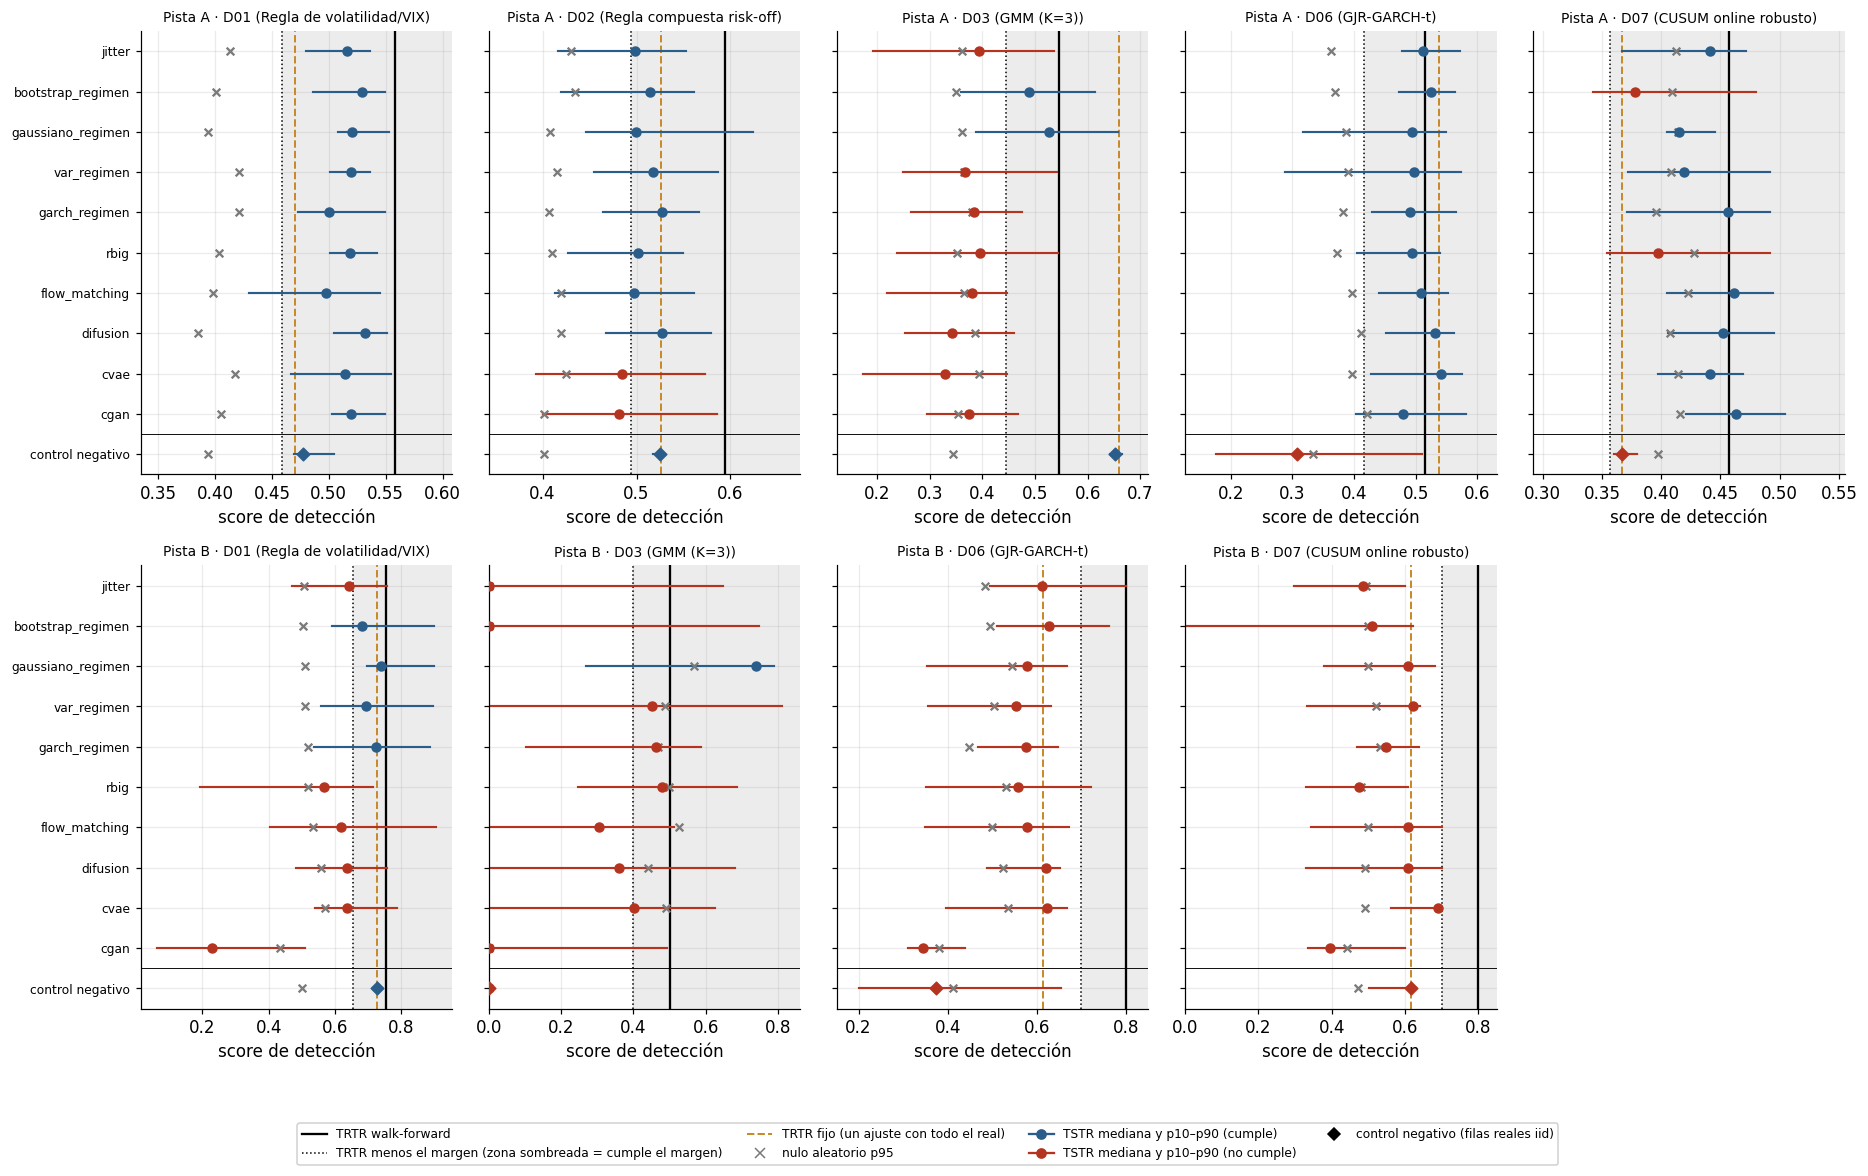

In [23]:
MARGEN = float(UMBRALES['tstr_margen_trtr'])
FRACCION = float(UMBRALES['tstr_fraccion_detectores'])


def tabla_util(u):
    pieza = lambda m: u[u['metrica'] == m].set_index([c for c in ('generador', 'detector') if c in u.columns])
    s, nulo, fijo = pieza('score_deteccion'), pieza('score_nulo_p95'), pieza('score_trtr_fijo')
    d = pd.DataFrame({'TSTR': s['sintetico'], 'p10': s['banda_inf'], 'p90': s['banda_sup'], 'TRTR': s['real'],
                      'TRTR fijo': fijo['real'], 'nulo p95': nulo['sintetico']})
    d['cumple'] = (d['TSTR'] >= d['TRTR'] - MARGEN) & (d['TSTR'] > d['nulo p95'])
    return d


UTIL = {t: tabla_util(TABLAS[t]['utilidad']) for t in PISTAS}
UTIL_CONTROL = {t: tabla_util(CONTROL[t]['utilidad_control']) for t in PISTAS}
CONTROL_PASA = {t: bool(UTIL_CONTROL[t]['cumple'].mean() > FRACCION) for t in PISTAS}
for t in PISTAS:
    d = UTIL[t]
    tstr = d['TSTR'].unstack('detector').reindex(GENERADORES)[DETECTORES[t]]
    cumple = d['cumple'].unstack('detector').reindex(GENERADORES)[DETECTORES[t]]
    ctrl = UTIL_CONTROL[t].reindex(DETECTORES[t])
    tstr.loc['CONTROL NEGATIVO (filas iid)'] = ctrl['TSTR'].to_numpy()
    cumple.loc['CONTROL NEGATIVO (filas iid)'] = ctrl['cumple'].to_numpy()
    tabla = tstr.copy()
    tabla['detectores que cumplen'] = cumple.sum(axis=1).astype(int)
    tabla['regla de utilidad'] = cumple.mean(axis=1) > FRACCION
    estilo = pd.DataFrame('', index=tabla.index, columns=tabla.columns)
    estilo[DETECTORES[t]] = np.where(cumple.to_numpy(dtype=bool), '', f'background-color: {COLOR_FALLA}')
    tabla.columns = [NOMBRE_DET[t].get(c, c) for c in tabla.columns]
    estilo.columns = tabla.columns
    display(Markdown(f'**Pista {t}** — mediana del score TSTR por generador y detector (rojo = no cumple TSTR ≥ TRTR − '
                     f'{fmt(MARGEN)} y TSTR > nulo p95); la regla exige más del {fmt(100 * FRACCION, 0)} % de los detectores'))
    display(tabla.style.format('{:.3f}', subset=[NOMBRE_DET[t][c] for c in DETECTORES[t]]).apply(lambda _: estilo, axis=None))

n_col = max(len(DETECTORES[t]) for t in PISTAS)
fig, axes = plt.subplots(len(PISTAS), n_col, figsize=(3.4 * n_col, 5.2 * len(PISTAS)), sharey=True)
axes = np.atleast_2d(axes)
etiq_y = GENERADORES + ['control negativo']
y = np.arange(len(etiq_y))[::-1]
for i, t in enumerate(PISTAS):
    for j in range(n_col):
        ax = axes[i, j]
        if j >= len(DETECTORES[t]):
            ax.set_visible(False)
            continue
        det = DETECTORES[t][j]
        d = UTIL[t].xs(det, level='detector').reindex(GENERADORES)
        d.loc['control negativo'] = UTIL_CONTROL[t].loc[det]
        ref = TRTR[t].loc[det]
        valores = pd.concat([d['p10'], d['p90'], d['nulo p95'], pd.Series([ref['score_wf'] - MARGEN, ref['score_wf'],
                                                                         ref['score_fijo']])]).dropna()
        x0, x1 = max(0.0, valores.min() - 0.05), min(1.0, valores.max() + 0.05)
        ax.axvspan(ref['score_wf'] - MARGEN, x1, color=viz.C_NA, alpha=0.8, lw=0)
        ax.axvline(ref['score_wf'], color='black', lw=1.5)
        ax.axvline(ref['score_wf'] - MARGEN, color='black', lw=1, ls=':')
        ax.axvline(ref['score_fijo'], color=viz.C_SHORT, lw=1.3, ls='--')
        ax.scatter(d['nulo p95'], y, marker='x', color=viz.C_NEG, s=25, zorder=3)
        for k, n in enumerate(etiq_y):
            fila = d.loc[n]
            color = viz.C_LONG if fila['cumple'] else viz.C_CRISIS
            ax.plot([fila['p10'], fila['p90']], [y[k], y[k]], color=color, lw=1.4)
            ax.scatter(fila['TSTR'], y[k], color=color, s=34, zorder=4, marker='D' if n == 'control negativo' else 'o')
        ax.axhline(0.5, color='black', lw=0.6)
        ax.set_xlim(x0, x1)
        ax.set_yticks(y, etiq_y, fontsize=8)
        ax.set_title(f'Pista {t} · {NOMBRE_DET[t][det]}', fontsize=9)
        ax.set_xlabel('score de detección')
handles = [Line2D([], [], color='black', lw=1.5, label='TRTR walk-forward'),
           Line2D([], [], color='black', lw=1, ls=':', label='TRTR menos el margen (zona sombreada = cumple el margen)'),
           Line2D([], [], color=viz.C_SHORT, lw=1.3, ls='--', label='TRTR fijo (un ajuste con todo el real)'),
           Line2D([], [], color=viz.C_NEG, marker='x', ls='', label='nulo aleatorio p95'),
           Line2D([], [], color=viz.C_LONG, marker='o', label='TSTR mediana y p10–p90 (cumple)'),
           Line2D([], [], color=viz.C_CRISIS, marker='o', label='TSTR mediana y p10–p90 (no cumple)'),
           Line2D([], [], color='black', marker='D', ls='', label='control negativo (filas reales iid)')]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.05, 1, 1)); guardar(fig, 'utilidad_tstr_trtr'); plt.show()

In [24]:
lineas = []
for t in PISTAS:
    d = UTIL[t]
    cumple = d['cumple'].unstack('detector').reindex(GENERADORES)[DETECTORES[t]]
    ok = cumple.index[cumple.mean(axis=1) > FRACCION]
    c = UTIL_CONTROL[t]
    lineas.append(f"- **Pista {t}**. Cumplen la regla (más del {fmt(100 * FRACCION, 0)} % de los detectores): {lista(ok)}. "
                  f"**Control negativo** (filas reales iid, régimen sin información): cumple en {int(c['cumple'].sum())} de "
                  f"{len(c)} detectores y la regla lo {'**aprueba**' if CONTROL_PASA[t] else 'suspende'}.")
    for det in DETECTORES[t]:
        x = d.xs(det, level='detector')
        lineas.append(f"  - {NOMBRE_DET[t][det]}: TRTR {fmt(TRTR[t].loc[det, 'score_wf'], 3)} (fijo "
                      f"{fmt(TRTR[t].loc[det, 'score_fijo'], 3)}), control negativo {fmt(c.loc[det, 'TSTR'], 3)}; cumplen "
                      f"{int(x['cumple'].sum())} de {len(x)} generadores; mayor mediana `{x['TSTR'].idxmax()}` "
                      f"({fmt(x['TSTR'].max(), 3)}; no significativo frente a los demás).")
    supera_fijo = int((d['TSTR'] >= d['TRTR fijo']).sum())
    lineas.append(f"  - El TSTR iguala o supera al TRTR **fijo** en {supera_fijo} de {len(d)} pares generador × detector: en "
                  f"esos pares, la distancia al walk-forward se debe, al menos en parte, al protocolo (un ajuste fijo frente "
                  f"a reajustes) y no a los datos sintéticos.")
md('**(c) Lectura (cifras de la tabla y la figura).**', *lineas,
   f"- Que el control negativo {'pase' if any(CONTROL_PASA.values()) else 'no pase'} la regla "
   + (f"(en la pista {', '.join(t for t in PISTAS if CONTROL_PASA[t])}) " if any(CONTROL_PASA.values()) else '')
   + "es la razón de que la utilidad sea informativa: un detector no supervisado se calibra con la ley marginal de los "
     "días, y unas filas reales barajadas ya la tienen.",
   f"- En la pista B hay {N_EVALUABLES.get('B', 0)} crisis evaluables: un evento detectado de más o de menos mueve el recall "
   f"{fmt(100 / max(N_EVALUABLES.get('B', 1), 1), 0)} puntos.")

**(c) Lectura (cifras de la tabla y la figura).**
- **Pista A**. Cumplen la regla (más del 50 % de los detectores): todos (10). **Control negativo** (filas reales iid, régimen sin información): cumple en 3 de 5 detectores y la regla lo **aprueba**.
  - D01 (Regla de volatilidad/VIX): TRTR 0,558 (fijo 0,470), control negativo 0,478; cumplen 10 de 10 generadores; mayor mediana `difusion` (0,531; no significativo frente a los demás).
  - D02 (Regla compuesta risk-off): TRTR 0,594 (fijo 0,526), control negativo 0,525; cumplen 8 de 10 generadores; mayor mediana `garch_regimen` (0,527; no significativo frente a los demás).
  - D03 (GMM (K=3)): TRTR 0,545 (fijo 0,659), control negativo 0,652; cumplen 2 de 10 generadores; mayor mediana `gaussiano_regimen` (0,527; no significativo frente a los demás).
  - D06 (GJR-GARCH-t): TRTR 0,516 (fijo 0,538), control negativo 0,308; cumplen 10 de 10 generadores; mayor mediana `cvae` (0,542; no significativo frente a los demás).
  - D07 (CUSUM online robusto): TRTR 0,457 (fijo 0,367), control negativo 0,367; cumplen 8 de 10 generadores; mayor mediana `cgan` (0,463; no significativo frente a los demás).
  - El TSTR iguala o supera al TRTR **fijo** en 23 de 50 pares generador × detector: en esos pares, la distancia al walk-forward se debe, al menos en parte, al protocolo (un ajuste fijo frente a reajustes) y no a los datos sintéticos.
- **Pista B**. Cumplen la regla (más del 50 % de los detectores): ninguno. **Control negativo** (filas reales iid, régimen sin información): cumple en 1 de 4 detectores y la regla lo suspende.
  - D01 (Regla de volatilidad/VIX): TRTR 0,754 (fijo 0,728), control negativo 0,726; cumplen 4 de 10 generadores; mayor mediana `gaussiano_regimen` (0,738; no significativo frente a los demás).
  - D03 (GMM (K=3)): TRTR 0,500 (fijo 0,000), control negativo 0,000; cumplen 1 de 10 generadores; mayor mediana `gaussiano_regimen` (0,738; no significativo frente a los demás).
  - D06 (GJR-GARCH-t): TRTR 0,800 (fijo 0,614), control negativo 0,374; cumplen 0 de 10 generadores; mayor mediana `bootstrap_regimen` (0,627; no significativo frente a los demás).
  - D07 (CUSUM online robusto): TRTR 0,800 (fijo 0,615), control negativo 0,616; cumplen 0 de 10 generadores; mayor mediana `cvae` (0,691; no significativo frente a los demás).
  - El TSTR iguala o supera al TRTR **fijo** en 16 de 40 pares generador × detector: en esos pares, la distancia al walk-forward se debe, al menos en parte, al protocolo (un ajuste fijo frente a reajustes) y no a los datos sintéticos.
- Que el control negativo pase la regla (en la pista A) es la razón de que la utilidad sea informativa: un detector no supervisado se calibra con la ley marginal de los días, y unas filas reales barajadas ya la tienen.
- En la pista B hay 3 crisis evaluables: un evento detectado de más o de menos mueve el recall 33 puntos.

In [25]:
# Circularidad (ficha F8): generadores de la misma familia que un detector lo pueden favorecer
PARES = [('garch_regimen', 'D06'), ('gaussiano_regimen', 'D03')]
lineas = []
for t in PISTAS:
    for n, det in PARES:
        if det not in DETECTORES[t]:
            continue
        x = UTIL[t].xs(det, level='detector')['TSTR']
        puesto = int(x.rank(ascending=False, method='min')[n])
        lineas.append(f"- Pista {t}, {NOMBRE_DET[t][det]} con `{n}`: TSTR {fmt(x[n], 3)}, puesto {puesto} de {len(x)} "
                      f"(mediana del resto {fmt(x.drop(n).median(), 3)}).")
md('**Circularidad (ficha F8).** `garch_regimen` comparte familia con D06 (GJR-GARCH) y `gaussiano_regimen` con D03 '
   '(mezcla gaussiana). Si el generador favoreciera a su detector, su TSTR destacaría en ese detector:', *lineas)

**Circularidad (ficha F8).** `garch_regimen` comparte familia con D06 (GJR-GARCH) y `gaussiano_regimen` con D03 (mezcla gaussiana). Si el generador favoreciera a su detector, su TSTR destacaría en ese detector:
- Pista A, D06 (GJR-GARCH-t) con `garch_regimen`: TSTR 0,491, puesto 9 de 10 (mediana del resto 0,509).
- Pista A, D03 (GMM (K=3)) con `gaussiano_regimen`: TSTR 0,527, puesto 1 de 10 (mediana del resto 0,380).
- Pista B, D06 (GJR-GARCH-t) con `garch_regimen`: TSTR 0,577, puesto 7 de 10 (mediana del resto 0,578).
- Pista B, D03 (GMM (K=3)) con `gaussiano_regimen`: TSTR 0,738, puesto 1 de 10 (mediana del resto 0,361).

**(d) Límites.** El TSTR de detectores no supervisados mide calibración, no transmisión de la señal
de crisis (control negativo). Es dentro de muestra respecto al generador; hay pocos eventos
evaluables, sobre todo en B; solo se usan detectores baratos; un detector ajustado en una sola
trayectoria ve pocas crisis sintéticas (las trayectorias sin crisis bajan la mediana); el nulo usa
la agresividad de la propia señal TSTR; y hay riesgo de circularidad entre familias (celda de
arriba), que el 17 debe declarar.

<a id="s7"></a>
## 7. Memorización

**(a) Idea y supuestos.** ¿Produce el generador días nuevos o devuelve, casi literalmente, días del
entrenamiento? Para cada vector sintético se mide la distancia euclídea al vecino real más cercano
y se compara con la distancia típica entre días reales separados por al menos `exclusion` sesiones
(los vecinos temporales comparten información),

$$
c_{NN} = \frac{\operatorname{mediana}_j\ \min_i \lVert \tilde x_j - x_i \rVert}
{\operatorname{mediana}_i\ \min_{|i-i'|\ \ge\ e} \lVert x_i - x_{i'} \rVert},
$$

en el espacio estandarizado con medias y desviaciones de entrenamiento, global y por régimen (el de
la consulta). Un cociente cercano a uno es lo esperable de una muestra nueva de la misma ley; uno
bajo indica copia **o** infradispersión, y se separan con la fracción de copias literales
(`frac_copias`) y la dispersión alrededor del centroide del régimen (`dispersion`, cociente
sintético/real): copiar es $c_{NN} \approx 0$ con dispersión normal; encoger es $c_{NN} < 1$ con
dispersión baja y sin copias. Las bandas de crisis son *jackknife* por episodio (como pedía la
ficha F8), a diferencia del bootstrap de episodios de la fidelidad.

Dos lecciones del taller previo fijan el método: el índice de vecindad se construye con el real
**íntegro** y las bandas de crisis se calculan por episodio. Y una regla a priori de la ficha F8:
**si una métrica no marca como copia a los controles positivos** (`jitter` y `bootstrap_regimen`),
**no sirve**. Por eso el criterio usa el espacio de las columnas **modeladas** (en el de todas, las
re-derivadas continúan la senda sintética y esconden la copia). Como la mediana no ve una copia de
menos de la mitad de los días, se publica además el cociente de un **cuantil bajo** de las mismas
distancias (`CUANTIL_MEMO`), informativo.

**(b) Tabla y figura.**

**Pista A** — memorización (criterio: c_NN ≥ 0,90 global y en crisis en el espacio `modeladas`; el cociente del cuantil p05 y el espacio `todas` son informativos)

**Pista B** — memorización (criterio: c_NN ≥ 0,90 global y en crisis en el espacio `modeladas`; el cociente del cuantil p05 y el espacio `todas` son informativos)

Controles positivos (jitter, bootstrap_regimen): suspenden la memorización en el espacio modeladas en las 2 pistas (assert superado).


figura -> results/sinteticos/validacion/memorizacion.png


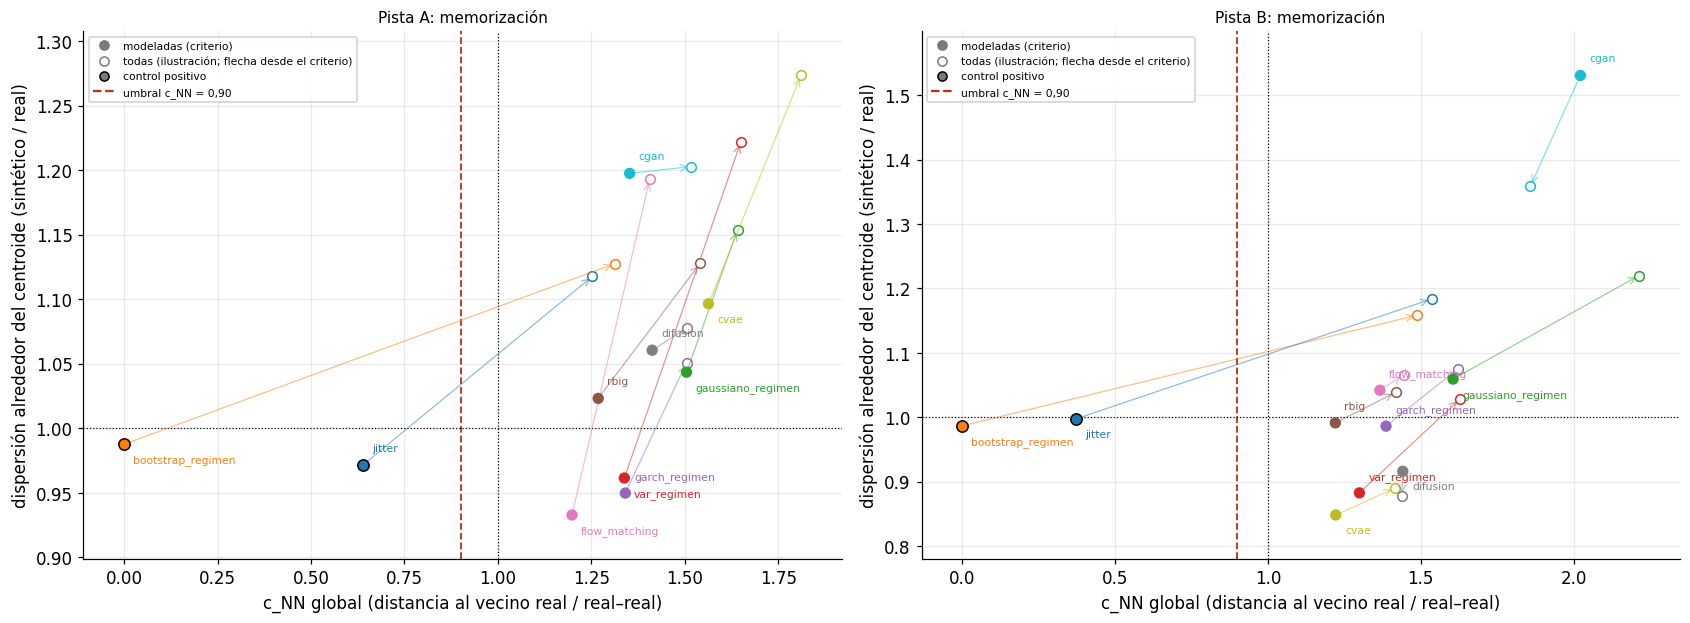

In [26]:
MINIMO_NN = float(UMBRALES['memorizacion_cociente_min'])
MEMO_T, MEMO_PASA, MEMO_PASA_OTRO = {}, {}, {}
etq_q = f'p{int(100 * CUANTIL_MEMO):02d}'
for t in PISTAS:
    m = TABLAS[t]['memorizacion']
    cola = TABLAS[t]['memorizacion_cola']

    def campo(espacio, regimen, metrica, col):
        s = m[(m['columna'] == espacio) & (m['regimen'] == regimen) & (m['metrica'] == metrica)]
        return s.set_index('generador')[col].reindex(GENERADORES)

    tabla = {}
    for espacio in (ESPACIO_MEMO, OTRO_ESPACIO):
        for regimen in ('todos', 'calma', 'crisis'):
            tabla[(espacio, f'c_NN {regimen}')] = campo(espacio, regimen, 'cociente_nn', 'cociente')
        tabla[(espacio, 'frac. copias')] = campo(espacio, 'todos', 'frac_copias', 'sintetico')
        tabla[(espacio, 'dispersión (cociente)')] = campo(espacio, 'todos', 'dispersion', 'cociente')
        if espacio == ESPACIO_MEMO:
            for regimen in ('todos', 'crisis'):
                tabla[(espacio, f'cociente {etq_q} {regimen}')] = (cola[cola['regimen'] == regimen]
                                                                   .set_index('generador')['cociente'].reindex(GENERADORES))
    MEMO_T[t] = pd.DataFrame(tabla)
    MEMO_PASA[t] = (MEMO_T[t][(ESPACIO_MEMO, 'c_NN todos')] >= MINIMO_NN) & (MEMO_T[t][(ESPACIO_MEMO, 'c_NN crisis')] >= MINIMO_NN)
    MEMO_PASA_OTRO[t] = (MEMO_T[t][(OTRO_ESPACIO, 'c_NN todos')] >= MINIMO_NN) & (MEMO_T[t][(OTRO_ESPACIO, 'c_NN crisis')] >= MINIMO_NN)
    MEMO_T[t][('criterio', 'pasa')] = MEMO_PASA[t]
    MEMO_T[t][('ilustración', f'pasaría en {OTRO_ESPACIO}')] = MEMO_PASA_OTRO[t]
    estilo = pd.DataFrame('', index=MEMO_T[t].index, columns=MEMO_T[t].columns)
    for c in [(ESPACIO_MEMO, 'c_NN todos'), (ESPACIO_MEMO, 'c_NN crisis')]:
        estilo.loc[MEMO_T[t][c] < MINIMO_NN, c] = f'background-color: {COLOR_FALLA}'
    display(Markdown(f'**Pista {t}** — memorización (criterio: c_NN ≥ {fmt(MINIMO_NN)} global y en crisis en el espacio '
                     f'`{ESPACIO_MEMO}`; el cociente del cuantil {etq_q} y el espacio `{OTRO_ESPACIO}` son informativos)'))
    display(MEMO_T[t].style.format('{:.3f}', subset=[c for c in MEMO_T[t].columns if c[0] in (ESPACIO_MEMO, OTRO_ESPACIO)])
            .apply(lambda _: estilo, axis=None))

# Regla a priori de la ficha F8: los controles positivos DEBEN suspender en el espacio del criterio.
for t in PISTAS:
    for n in CONTROLES:
        assert not MEMO_PASA[t][n], (f'El control positivo {n} aprueba la memorización en la pista {t} (espacio '
                                     f'{ESPACIO_MEMO}): según la regla de la ficha F8 la métrica no sirve.')
print(f'Controles positivos ({", ".join(CONTROLES)}): suspenden la memorización en el espacio {ESPACIO_MEMO} en las '
      f'{len(PISTAS)} pistas (assert superado).')

fig, axes = plt.subplots(1, len(PISTAS), figsize=(15.5, 5.8))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    d = MEMO_T[t]
    orden_y = d[(ESPACIO_MEMO, 'dispersión (cociente)')].sort_values().index
    for k, n in enumerate(orden_y):
        x0, y0 = d.loc[n, (ESPACIO_MEMO, 'c_NN todos')], d.loc[n, (ESPACIO_MEMO, 'dispersión (cociente)')]
        x1, y1 = d.loc[n, (OTRO_ESPACIO, 'c_NN todos')], d.loc[n, (OTRO_ESPACIO, 'dispersión (cociente)')]
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops={'arrowstyle': '->', 'color': COLOR_GEN[n], 'lw': 0.8,
                                                                  'alpha': 0.5})
        ax.scatter(x0, y0, color=COLOR_GEN[n], s=55, zorder=3, edgecolor='black' if n in CONTROLES else 'none')
        ax.scatter(x1, y1, facecolor='white', edgecolor=COLOR_GEN[n], s=40, zorder=3)
        ax.annotate(n, (x0, y0), textcoords='offset points', xytext=(6, 9 if k % 2 else -12), fontsize=7, color=COLOR_GEN[n])
    ax.axvline(MINIMO_NN, color=viz.C_CRISIS, ls='--', lw=1.2)
    ax.axhline(1, color='black', lw=0.8, ls=':')
    ax.axvline(1, color='black', lw=0.8, ls=':')
    ax.set_xlabel('c_NN global (distancia al vecino real / real–real)')
    ax.set_ylabel('dispersión alrededor del centroide (sintético / real)')
    ax.set_title(f'Pista {t}: memorización', fontsize=10)
    ax.legend(handles=[Line2D([], [], color=viz.C_NEG, marker='o', ls='', label=f'{ESPACIO_MEMO} (criterio)'),
                       Line2D([], [], color=viz.C_NEG, marker='o', ls='', markerfacecolor='white',
                              label=f'{OTRO_ESPACIO} (ilustración; flecha desde el criterio)'),
                       Line2D([], [], color=viz.C_NEG, marker='o', ls='', markeredgecolor='black', label='control positivo'),
                       Line2D([], [], color=viz.C_CRISIS, ls='--', label=f'umbral c_NN = {fmt(MINIMO_NN)}')],
              fontsize=7, loc='upper left', framealpha=0.9)
    ax.margins(x=0.06, y=0.1)
fig.tight_layout(); guardar(fig, 'memorizacion'); plt.show()

In [27]:
lineas = []
for t in PISTAS:
    d = MEMO_T[t]
    ctrl = '; '.join(f"`{n}`: c_NN {fmt(d.loc[n, (ESPACIO_MEMO, 'c_NN todos')], 3)} en `{ESPACIO_MEMO}` frente a "
                     f"{fmt(d.loc[n, (OTRO_ESPACIO, 'c_NN todos')], 3)} en `{OTRO_ESPACIO}` "
                     f"({'aprobaría' if MEMO_PASA_OTRO[t][n] else 'también suspende'}), copias literales "
                     f"{fmt(100 * d.loc[n, (ESPACIO_MEMO, 'frac. copias')], 1)} %" for n in CONTROLES)
    otros = [n for n in GENERADORES if n not in CONTROLES]
    fallan = [n for n in otros if not MEMO_PASA[t][n]]
    encoge = [n for n in fallan if d.loc[n, (ESPACIO_MEMO, 'dispersión (cociente)')] < 1
              and d.loc[n, (ESPACIO_MEMO, 'frac. copias')] < 0.01]
    q = d.loc[otros, (ESPACIO_MEMO, f'cociente {etq_q} todos')]
    lineas.append(f"- **Pista {t}**. Controles positivos — {ctrl}.")
    lineas.append(
        f"  - Resto de generadores: pasan {lista([n for n in otros if MEMO_PASA[t][n]], universo=otros)}"
        + (f"; no pasan {lista(fallan)} (perfil de infradispersión —dispersión < 1 y sin copias literales—: {lista(encoge)})"
           if fallan else '')
        + f". c_NN global en `{ESPACIO_MEMO}` de {fmt(d.loc[otros, (ESPACIO_MEMO, 'c_NN todos')].min(), 3)} a "
          f"{fmt(d.loc[otros, (ESPACIO_MEMO, 'c_NN todos')].max(), 3)}; cociente del cuantil {etq_q} de {fmt(q.min(), 3)} "
          f"(`{q.idxmin()}`) a {fmt(q.max(), 3)} (informativo: un cociente bajo en la cola con la mediana normal indicaría "
          f"copia de una minoría de días).")
md('**(c) Lectura (cifras de la tabla y la figura).**', *lineas,
   "- Las flechas de la figura enseñan por qué el espacio importa: al añadir las columnas re-derivadas la distancia al "
   "vecino real crece para los que copian (sus re-derivadas siguen la senda sintética, no la del día copiado) y la copia "
   "deja de verse.")

**(c) Lectura (cifras de la tabla y la figura).**
- **Pista A**. Controles positivos — `jitter`: c_NN 0,640 en `modeladas` frente a 1,253 en `todas` (aprobaría), copias literales 0,0 %; `bootstrap_regimen`: c_NN 0,000 en `modeladas` frente a 1,313 en `todas` (aprobaría), copias literales 100,0 %.
  - Resto de generadores: pasan todos (8). c_NN global en `modeladas` de 1,198 a 1,563; cociente del cuantil p05 de 1,396 (`rbig`) a 1,715 (informativo: un cociente bajo en la cola con la mediana normal indicaría copia de una minoría de días).
- **Pista B**. Controles positivos — `jitter`: c_NN 0,373 en `modeladas` frente a 1,535 en `todas` (aprobaría), copias literales 0,0 %; `bootstrap_regimen`: c_NN 0,000 en `modeladas` frente a 1,488 en `todas` (aprobaría), copias literales 100,0 %.
  - Resto de generadores: pasan todos (8). c_NN global en `modeladas` de 1,221 a 2,022; cociente del cuantil p05 de 1,370 (`rbig`) a 1,848 (informativo: un cociente bajo en la cola con la mediana normal indicaría copia de una minoría de días).
- Las flechas de la figura enseñan por qué el espacio importa: al añadir las columnas re-derivadas la distancia al vecino real crece para los que copian (sus re-derivadas siguen la senda sintética, no la del día copiado) y la copia deja de verse.

**(d) Límites.** El criterio usa la **mediana** de distancias: una copia de menos de la mitad de los
días no la mueve (el cuantil bajo, informativo, lo vigila). Con `largo_ventana` de un día se
detecta la copia de **días**, no de secuencias. La distancia euclídea estandarizada pesa igual
todas las columnas modeladas; las mensuales, casi constantes, acercan los vecinos. Un cociente por
encima del umbral no prueba privacidad: solo que la mediana de distancias no delata copia.

<a id="s8"></a>
## 8. Veredicto

`validacion.veredicto` aplica las reglas y umbrales del yaml a las tablas de §2–§7 (las mismas que
se han leído sección a sección). Calcula todos los criterios y publica todos, pero **solo deciden
los que figuran en algún nivel** de `validacion.niveles`:

- **`apto_laboratorio`**: lo generado se parece al real y un clasificador no lo distingue.
- **`laboratorio_condicionado`**: lo mismo sin el discriminador (decisión iii.5, declarada después
  de ver el veredicto): el 17 puede usar estos generadores advirtiendo que son distinguibles.
- **`apto_aumento`**: no copia el entrenamiento y su etiqueta de régimen lleva señal
  (memorización y condicionamiento; decisión iii.4).

Correlaciones y utilidad se calculan y se publican como informativas.

**(b) Tablas y figura.**

**Pista A** — veredicto (guardado en `results/sinteticos/validacion/veredicto_pistaA.csv`)

,marginal,dependencia,correlaciones (informativo),condicionamiento,discriminador,memorización,utilidad (informativo),apto laboratorio,apto aumento,laboratorio condicionado
generador,,,,,,,,,,
jitter,sí,no,sí,sí,no,no,sí,no,no,no
bootstrap_regimen,sí,no,sí,sí,no,no,sí,no,no,no
gaussiano_regimen,sí,no,sí,sí,no,sí,sí,no,sí,no
var_regimen,sí,no,sí,sí,no,sí,sí,no,sí,no
garch_regimen,sí,no,sí,sí,no,sí,sí,no,sí,no
rbig,sí,no,sí,sí,no,sí,sí,no,sí,no
flow_matching,no,no,sí,sí,no,sí,sí,no,sí,no
difusion,sí,no,sí,sí,no,sí,sí,no,sí,no
cvae,no,no,sí,sí,no,sí,sí,no,sí,no


**Pista B** — veredicto (guardado en `results/sinteticos/validacion/veredicto_pistaB.csv`)

,marginal,dependencia,correlaciones (informativo),condicionamiento,discriminador,memorización,utilidad (informativo),apto laboratorio,apto aumento,laboratorio condicionado
generador,,,,,,,,,,
jitter,sí,no,sí,sí,no,no,no,no,no,no
bootstrap_regimen,sí,no,sí,sí,no,no,no,no,no,no
gaussiano_regimen,sí,no,sí,sí,no,sí,no,no,sí,no
var_regimen,sí,no,sí,sí,no,sí,no,no,sí,no
garch_regimen,no,no,sí,sí,no,sí,no,no,sí,no
rbig,no,no,sí,sí,no,sí,no,no,sí,no
flow_matching,no,no,sí,sí,no,sí,no,no,sí,no
difusion,no,no,sí,no,no,sí,no,no,no,no
cvae,no,no,sí,no,no,sí,no,no,no,no


figura -> results/sinteticos/validacion/veredicto.png


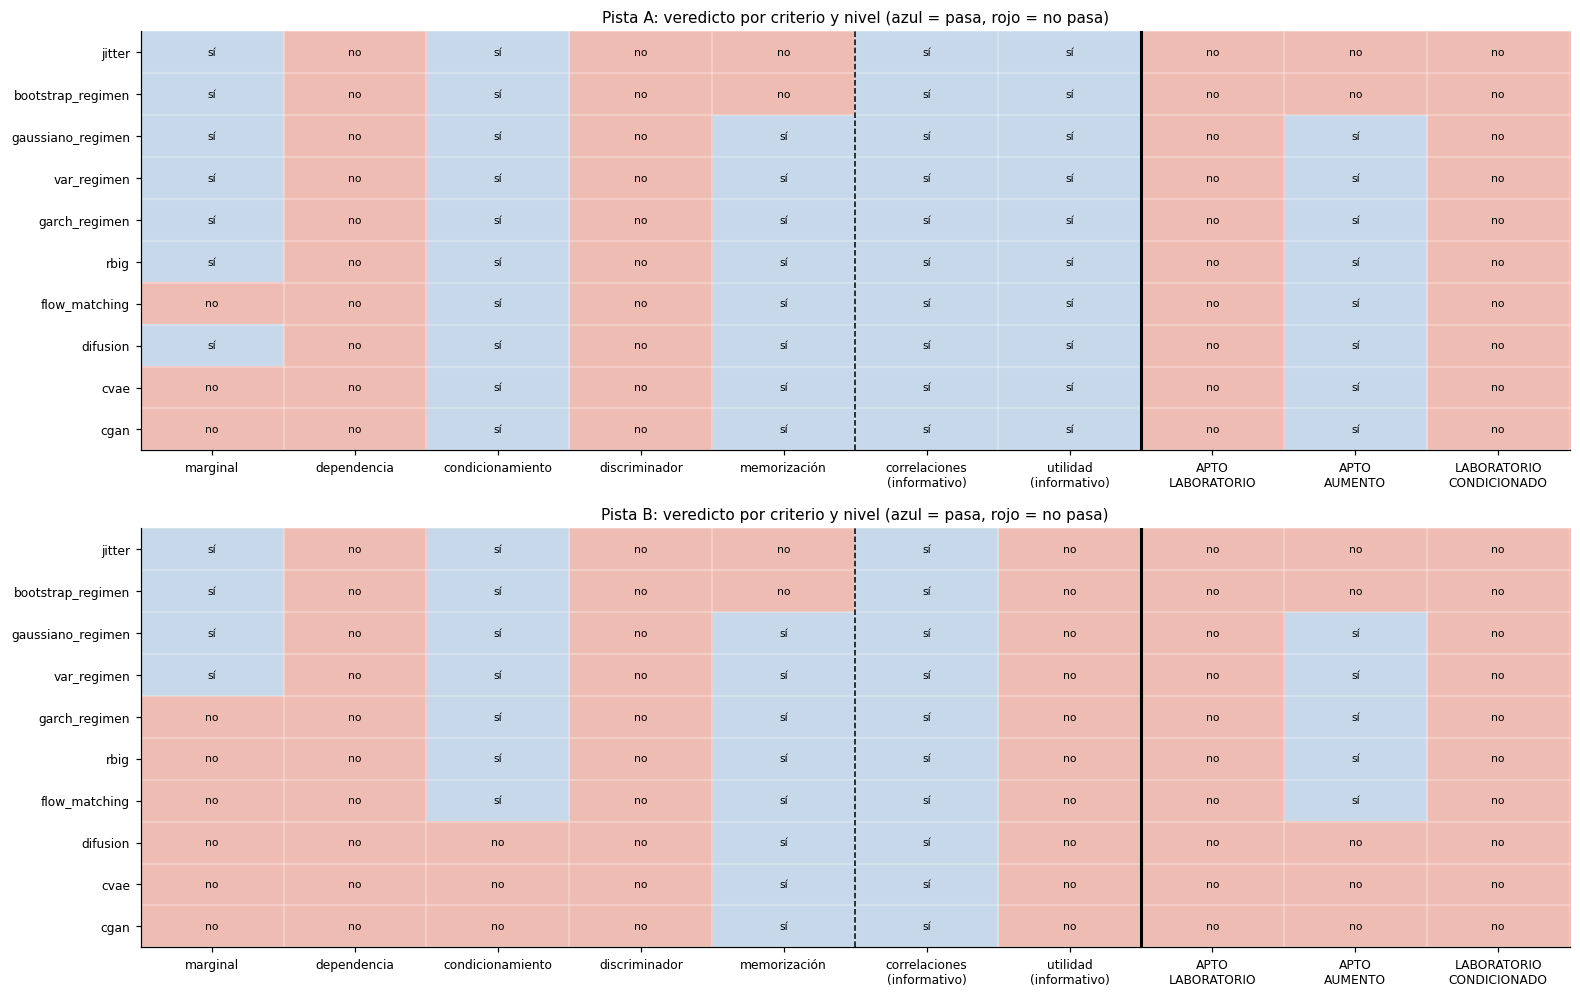

In [28]:
DIM_VEREDICTO = {'marginal': 'fidelidad_marginal', 'dependencia': 'fidelidad_dependencia',
                 'correlaciones': 'distancia_correlaciones', 'condicionamiento': 'condicionamiento',
                 'discriminador': 'discriminador', 'memorizacion': 'memorizacion', 'utilidad': 'utilidad'}
TABLAS_VER = {t: {n: {crit: de(t, dim, n) for crit, dim in DIM_VEREDICTO.items()} for n in GENERADORES} for t in PISTAS}


def veredicto_con(t, *, reglas=None, niveles=None, umbrales=None, espacio=None, tablas=None):
    return val.veredicto(tablas or TABLAS_VER[t], umbrales or UMBRALES, reglas=reglas or REGLAS,
                         niveles=niveles or NIVELES, espacio_memorizacion=espacio or ESPACIO_MEMO)


VEREDICTO = {t: veredicto_con(t) for t in PISTAS}
NIVELES_L = list(NIVELES)
for t in PISTAS:
    VEREDICTO[t].to_csv(OUT_DIR / f'veredicto_pista{t}.csv', encoding='utf-8')
    v = VEREDICTO[t]   # coherencia con la lectura sección a sección
    assert (v['marginal'] == PASA_CRIT[t]['marginal']).all() and (v['dependencia'] == PASA_CRIT[t]['dependencia']).all()
    assert (v['condicionamiento'] == COND[t]['pasa']).all() and (v['memorizacion'] == MEMO_PASA[t]).all()
    assert (v['discriminador'] == DISCR[t][('criterio', 'pasa')]).all()
    assert (v['correlaciones'] == CORR[t][('informativo', f'≤ {FACTOR:g} × p95')]).all()
    tabla = v[CRITERIOS + NIVELES_L].astype('object').replace({True: 'sí', False: 'no'}).fillna('—')
    tabla.columns = [LEGIBLE.get(c, c) + (' (informativo)' if c in INFORMATIVOS else '') for c in tabla.columns]
    display(Markdown(f'**Pista {t}** — veredicto (guardado en `{rel(OUT_DIR / f"veredicto_pista{t}.csv")}`)'))
    display(tabla)

fig, axes = plt.subplots(len(PISTAS), 1, figsize=(14.5, 4.6 * len(PISTAS)))
orden_cols = DECISORES + INFORMATIVOS
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    tabla = VEREDICTO[t][orden_cols + NIVELES_L].copy()
    tabla.columns = [LEGIBLE[c] + ('\n(informativo)' if c in INFORMATIVOS else '') if c in CRITERIOS
                     else LEGIBLE[c].upper().replace(' ', '\n', 1) for c in tabla.columns]
    dibujar_pasa(ax, tabla, titulo=f'Pista {t}: veredicto por criterio y nivel (azul = pasa, rojo = no pasa)')
    ax.axvline(len(DECISORES) - 0.5, color='black', lw=1, ls='--')
    ax.axvline(len(orden_cols) - 0.5, color='black', lw=2)
fig.tight_layout(); guardar(fig, 'veredicto'); plt.show()

In [29]:
lineas = []
for t in PISTAS:
    v = VEREDICTO[t]
    nivel = {k: list(v.index[v[k].fillna(False)]) for k in NIVELES_L}
    lineas.append(f"- **Pista {t}**: " + '; '.join(f"{LEGIBLE[k]}: {lista(nivel[k])}" for k in NIVELES_L) + '.')
    for n in GENERADORES:
        fallos = [c for c in DECISORES if v.loc[n, c] is not pd.NA and v.loc[n, c] == False]  # noqa: E712
        if not fallos:
            continue
        detalle = '; '.join(f"**{LEGIBLE[c]}** ({legible(v.loc[n, f'fallos_{c}'])})" for c in fallos)
        lineas.append(f"  - `{n}` falla {len(fallos)} de {len(DECISORES)} criterios que deciden: {detalle}.")
    notas = [n for n in GENERADORES if 'indicio de copia' in str(v.loc[n, 'fallos_discriminador'])]
    if notas:
        lineas.append(f"  - Indicio de copia anotado por el discriminador (AUC global < {fmt(CORTE_COPIA)}): {lista(notas)}.")
md('**(c) Lectura del veredicto (generada; entre paréntesis, como mucho dos filas clave que fallan por criterio).**', *lineas)

**(c) Lectura del veredicto (generada; entre paréntesis, como mucho dos filas clave que fallan por criterio).**
- **Pista A**: apto laboratorio: ninguno; apto aumento: todos salvo `jitter`, `bootstrap_regimen`; laboratorio condicionado: ninguno.
  - `jitter` falla 3 de 5 criterios que deciden: **dependencia** (vida media de las persistentes en calma; vida media de las persistentes en crisis); **discriminador** (AUC global 0,994); **memorización** (global: 0,640; crisis: 0,515).
  - `bootstrap_regimen` falla 3 de 5 criterios que deciden: **dependencia** (vida media de las persistentes en calma; vida media de las persistentes en crisis); **discriminador** (AUC global 0,777); **memorización** (global: 0,000; crisis: 0,000).
  - `gaussiano_regimen` falla 2 de 5 criterios que deciden: **dependencia** (ACF |r| (1) de SP500_ret en calma; vida media de las persistentes en calma (y 3 más)); **discriminador** (AUC global 0,999).
  - `var_regimen` falla 2 de 5 criterios que deciden: **dependencia** (ACF |r| (1) de SP500_ret en calma); **discriminador** (AUC global 0,953).
  - `garch_regimen` falla 2 de 5 criterios que deciden: **dependencia** (curtosis condicional (por trayectoria) de SP500_ret en crisis); **discriminador** (AUC global 0,937).
  - `rbig` falla 2 de 5 criterios que deciden: **dependencia** (ACF |r| (1) de SP500_ret en calma); **discriminador** (AUC global 0,992).
  - `flow_matching` falla 3 de 5 criterios que deciden: **marginal** (cola q01 de SP500_ret en crisis); **dependencia** (curtosis condicional (por trayectoria) de SP500_ret en calma; curtosis condicional (por trayectoria) de SP500_ret en crisis); **discriminador** (AUC global 0,990).
  - `difusion` falla 2 de 5 criterios que deciden: **dependencia** (curtosis condicional (por trayectoria) de SP500_ret en calma; curtosis condicional (por trayectoria) de SP500_ret en crisis); **discriminador** (AUC global 0,993).
  - `cvae` falla 3 de 5 criterios que deciden: **marginal** (desviación de term_spread_hist_z en calma); **dependencia** (vida media de las persistentes en calma); **discriminador** (AUC global 0,994).
  - `cgan` falla 3 de 5 criterios que deciden: **marginal** (desviación de term_spread_hist_z en calma; desviación de term_spread_hist_z en crisis (y 1 más)); **dependencia** (curtosis condicional (por trayectoria) de SP500_ret en crisis); **discriminador** (AUC global 0,987).
- **Pista B**: apto laboratorio: ninguno; apto aumento: `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`; laboratorio condicionado: ninguno.
  - `jitter` falla 3 de 5 criterios que deciden: **dependencia** (vida media de las persistentes en calma; vida media de las persistentes en crisis); **discriminador** (AUC global 0,996); **memorización** (global: 0,373; crisis: 0,283).
  - `bootstrap_regimen` falla 3 de 5 criterios que deciden: **dependencia** (vida media de las persistentes en calma; vida media de las persistentes en crisis); **discriminador** (AUC global 0,841); **memorización** (global: 0,000; crisis: 0,000).
  - `gaussiano_regimen` falla 2 de 5 criterios que deciden: **dependencia** (ACF |r| (1) de SP500_ret en calma; vida media de las persistentes en calma (y 3 más)); **discriminador** (AUC global 0,996).
  - `var_regimen` falla 2 de 5 criterios que deciden: **dependencia** (ACF |r| (1) de SP500_ret en calma; vida media de las persistentes en calma (y 3 más)); **discriminador** (AUC global 0,875).
  - `garch_regimen` falla 3 de 5 criterios que deciden: **marginal** (desviación de VIX_level_z en calma; desviación de INDPRO_yoy_z en crisis); **dependencia** (ACF |r| (1) de SP500_ret en calma); **discriminador** (AUC global 0,923).
  - `rbig` falla 3 de 5 criterios que deciden: **marginal** (desviación de credit_BaaAaa_mensual_z en crisis; desviación de INDPRO_yoy_z en crisis); **dependencia** (ACF |r| (1) de SP500_ret en calma; vida media de las persistentes en calma (y 2 más)); **discriminador** (AUC global 0,995).
  - `flow_matching` falla 3 de 5 criterios que deciden: **marginal** (desviación de INDPRO_yoy_z en crisis); **dependencia** (vida media de las persistentes en calma; curtosis condicional (por trayectoria) de SP500_ret en calma); **discriminador** (AUC global 1,000).
  - `difusion` falla 4 de 5 criterios que deciden: **marginal** (desviación de MOVE_level_z en calma; desviación de DGS10_change_z en crisis (y 1 más)); **dependencia** (vida media de las persistentes en calma; curtosis condicional (por trayectoria) de SP500_ret en calma); **condicionamiento** (separación de volatilidad (todos)); **discriminador** (AUC global 0,976).
  - `cvae` falla 4 de 5 criterios que deciden: **marginal** (desviación de corr_spx_bond en calma; desviación de INDPRO_yoy_z en crisis); **dependencia** (vida media de las persistentes en calma; curtosis condicional (por trayectoria) de SP500_ret en calma (y 1 más)); **condicionamiento** (separación de volatilidad (todos)); **discriminador** (AUC global 1,000).
  - `cgan` falla 4 de 5 criterios que deciden: **marginal** (desviación de FF_MKT_z en calma; desviación de DGS10_change_z en calma (y 22 más)); **dependencia** (ACF |r| (1) de SP500_ret en calma; curtosis condicional (por trayectoria) de SP500_ret en calma (y 1 más)); **condicionamiento** (separación de volatilidad (todos)); **discriminador** (AUC global 0,998).

<a id="s8-2"></a>
### 8.2 Efecto de cada decisión declarada (contrafactual)

Para cada decisión de los grupos (ii) y (iii) de §0, la celda recalcula el veredicto con la regla
anterior (o con la alternativa descartada) sobre las mismas tablas y enseña qué cambia en el
criterio o el nivel afectado. Las decisiones posteriores al veredicto se publican precisamente para
que se pueda juzgar si cambiaron el resultado.

In [30]:
def con_tabla(t, crit, dim):
    return {n: {**TABLAS_VER[t][n], crit: de(t, dim, n)} for n in GENERADORES}


def mayoria(t, criterio):
    c = CLAVE[t][CLAVE[t]['criterio'] == criterio]
    return c.groupby('generador')['pasa'].mean().reindex(GENERADORES) > 0.5


reglas_ant = {**REGLAS, 'dependencia': {'ret': ['acf_abs_1', 'curtosis_condicional'], 'persistentes': ['acf1_persistentes']}}
reglas_curt = {**REGLAS, 'dependencia': {**REGLAS['dependencia'],
                                         'ret': [m if m != 'curtosis_condicional_tray' else 'curtosis_condicional'
                                                 for m in REGLAS['dependencia']['ret']]}}
reglas_vida = {**REGLAS, 'dependencia': {**REGLAS['dependencia'], 'persistentes': ['acf1_persistentes']}}
niveles_ant = {'apto_laboratorio': NIVELES['apto_laboratorio'] + ['correlaciones'], 'apto_aumento': ['utilidad', 'memorizacion']}
filas, LAB_COND_ANT, REF_ENTERO = [], {}, {}
for t in PISTAS:
    v = VEREDICTO[t]
    ok = lambda s: lista(s.index[s.fillna(False).astype(bool)])
    alt_disc = veredicto_con(t, tablas=con_tabla(t, 'discriminador', 'discriminador_informativo'))
    alt_esp = veredicto_con(t, espacio=OTRO_ESPACIO)
    alt_curt = veredicto_con(t, reglas=reglas_curt)
    alt_vida = veredicto_con(t, reglas=reglas_vida)
    alt_corr1 = veredicto_con(t, reglas={**REGLAS, 'correlaciones_factor_p95': 1.0})
    ant_todo = veredicto_con(t, reglas=reglas_ant, niveles=niveles_ant)
    ant_dep = veredicto_con(t, reglas=reglas_ant)
    alt_ref = veredicto_con(t, tablas=con_tabla(t, 'dependencia', 'fidelidad_dependencia_entero'))
    REF_ENTERO[t] = alt_ref
    LAB_COND_ANT[t] = list(ant_dep.index[ant_dep['laboratorio_condicionado'].fillna(False)])
    util_A = VEREDICTO[PISTA_PRINCIPAL]['utilidad']        # regla anterior: la utilidad de B se tomaba de A
    aum_ant = (util_A if t != PISTA_PRINCIPAL else v['utilidad']) & v['memorizacion']
    filas += [
        {'pista': t, 'decisión': 'ii.1 variante informativa del discriminador (fuera del veredicto)',
         'afecta a': 'apto laboratorio', 'vigente': ok(v['apto_laboratorio']),
         'alternativa': 'si decidiera la variante: ' + ok(alt_disc['apto_laboratorio'])},
        {'pista': t, 'decisión': f'ii.2 memorización en {ESPACIO_MEMO}', 'afecta a': 'memorización',
         'vigente': ok(v['memorizacion']), 'alternativa': f'en {OTRO_ESPACIO}: ' + ok(alt_esp['memorizacion'])},
        {'pista': t, 'decisión': 'ii.3 todas las filas clave', 'afecta a': 'marginal / dependencia',
         'vigente': f"{ok(v['marginal'])} / {ok(v['dependencia'])}",
         'alternativa': f"mayoría de filas: {ok(mayoria(t, 'marginal'))} / {ok(mayoria(t, 'dependencia'))}"},
        {'pista': t, 'decisión': f'ii.4 correlaciones ≤ {FACTOR:g} × p95', 'afecta a': 'correlaciones (hoy informativo)',
         'vigente': ok(v['correlaciones']), 'alternativa': '1 × p95: ' + ok(alt_corr1['correlaciones'])},
        {'pista': t, 'decisión': 'iii.1 curtosis condicional por trayectoria', 'afecta a': 'dependencia',
         'vigente': ok(v['dependencia']), 'alternativa': 'curtosis anterior: ' + ok(alt_curt['dependencia'])},
        {'pista': t, 'decisión': 'iii.2 vida media de las persistentes', 'afecta a': 'dependencia',
         'vigente': ok(v['dependencia']), 'alternativa': 'ACF1 anterior: ' + ok(alt_vida['dependencia'])},
        {'pista': t, 'decisión': 'iii.1 + iii.2 dependencia anterior completa', 'afecta a': 'dependencia / laboratorio condicionado',
         'vigente': f"{ok(v['dependencia'])} / {ok(v['laboratorio_condicionado'])}",
         'alternativa': f"{ok(ant_dep['dependencia'])} / {ok(ant_dep['laboratorio_condicionado'])}"},
        {'pista': t, 'decisión': 'iii.6 referencia por ventanas en la dependencia',
         'afecta a': 'dependencia / laboratorio condicionado',
         'vigente': f"{ok(v['dependencia'])} / {ok(v['laboratorio_condicionado'])}",
         'alternativa': f"real entero: {ok(alt_ref['dependencia'])} / {ok(alt_ref['laboratorio_condicionado'])}"},
        {'pista': t, 'decisión': 'iii.3 correlaciones informativas', 'afecta a': 'apto laboratorio',
         'vigente': ok(v['apto_laboratorio']), 'alternativa': 'con correlaciones: ' + ok(ant_todo['apto_laboratorio'])},
        {'pista': t, 'decisión': 'iii.4 apto aumento = memorización + condicionamiento', 'afecta a': 'apto aumento',
         'vigente': ok(v['apto_aumento']), 'alternativa': 'utilidad (de A) + memorización: ' + ok(aum_ant)},
        {'pista': t, 'decisión': 'iii.5 nivel laboratorio condicionado', 'afecta a': 'uso en el 17',
         'vigente': 'laboratorio condicionado: ' + ok(v['laboratorio_condicionado']),
         'alternativa': 'sin el nivel, apto laboratorio: ' + ok(v['apto_laboratorio'])},
        {'pista': t, 'decisión': 'conjunto de reglas anteriores (ii + regla previa a iii)', 'afecta a': 'niveles',
         'vigente': f"laboratorio {ok(v['apto_laboratorio'])}; aumento {ok(v['apto_aumento'])}",
         'alternativa': f"laboratorio {ok(ant_todo['apto_laboratorio'])}; aumento {ok(aum_ant)}"},
    ]
CONTRAFACTUAL = pd.DataFrame(filas).set_index(['pista', 'decisión'])
with pd.option_context('display.max_colwidth', 120):
    display(CONTRAFACTUAL)

afecta a  \
pista decisión                                                                                                    
A     ii.1 variante informativa del discriminador (fuera del veredicto)                        apto laboratorio   
      ii.2 memorización en modeladas                                                               memorización   
      ii.3 todas las filas clave                                                         marginal / dependencia   
      ii.4 correlaciones ≤ 2 × p95                                              correlaciones (hoy informativo)   
      iii.1 curtosis condicional por trayectoria                                                    dependencia   
      iii.2 vida media de las persistentes                                                          dependencia   
      iii.1 + iii.2 dependencia anterior completa                        dependencia / laboratorio condicionado   
      iii.6 referencia por ventanas en la dependencia                    dependencia / laboratorio condicionado   
      iii.3 correlaciones informativas                                                         apto laboratorio   
      iii.4 apto aumento = memorización + condicionamiento                                         apto aumento   
      iii.5 nivel laboratorio condicionado                                                         uso en el 17   
      conjunto de reglas anteriores (ii + regla previa a iii)                                           niveles   
B     ii.1 variante informativa del discriminador (fuera del veredicto)                        apto laboratorio   
      ii.2 memorización en modeladas                                                               memorización   
      ii.3 todas las filas clave                                                         marginal / dependencia   
      ii.4 correlaciones ≤ 2 × p95                                              correlaciones (hoy informativo)   
      iii.1 curtosis condicional por trayectoria                                                    dependencia   
      iii.2 vida media de las persistentes                                                          dependencia   
      iii.1 + iii.2 dependencia anterior completa                        dependencia / laboratorio condicionado   
      iii.6 referencia por ventanas en la dependencia                    dependencia / laboratorio condicionado   
      iii.3 correlaciones informativas                                                         apto laboratorio   
      iii.4 apto aumento = memorización + condicionamiento                                         apto aumento   
      iii.5 nivel laboratorio condicionado                                                         uso en el 17   
      conjunto de reglas anteriores (ii + regla previa a iii)                                           niveles   

                                                                                                                                                                           vigente  \
pista decisión                                                                                                                                                                       
A     ii.1 variante informativa del discriminador (fuera del veredicto)                                                                                                    ninguno   
      ii.2 memorización en modeladas                                                                                                     todos salvo `jitter`, `bootstrap_regimen`   
      ii.3 todas las filas clave                                                                                             todos salvo `flow_matching`, `cvae`, `cgan` / ninguno   
      ii.4 correlaciones ≤ 2 × p95                                                                                                                                      todos (10)   
      iii.1 curtosis

<a id="s9"></a>
## 9. Resumen y siguiente paso

La conclusión, las respuestas a las preguntas de §0 y las limitaciones se generan a partir de las
tablas de §2–§8.

In [31]:
cuenta = {t: VEREDICTO[t][DECISORES].fillna(True).eq(False).sum() for t in PISTAS}
lineas = []
for t in PISTAS:
    v = VEREDICTO[t]
    peores = cuenta[t][cuenta[t] == cuenta[t].max()].index
    lineas.append(f"  - Pista {t}: " + '; '.join(f"{LEGIBLE[k]} {int(v[k].fillna(False).sum())} de {len(GENERADORES)} "
                                                 f"({lista(v.index[v[k].fillna(False)])})" for k in NIVELES_L)
                  + f". Criterio que más generadores suspende: {', '.join(f'`{LEGIBLE[c]}`' for c in peores)} "
                    f"({int(cuenta[t].max())} de {len(GENERADORES)}).")
ambas = {k: [n for n in GENERADORES if all(VEREDICTO[t].loc[n, k] == True for t in PISTAS)] for k in NIVELES_L}  # noqa: E712
cond_b = [n for n in GENERADORES if any(VEREDICTO[t].loc[n, 'condicionamiento'] == False for t in PISTAS)]  # noqa: E712
md('### 9.1 Conclusión (generada)',
   f"- **Veredicto** de {len(GENERADORES)} generadores en {len(PISTAS)} pistas, contra su tramo de entrenamiento:", *lineas,
   '- **En las dos pistas**: ' + '; '.join(f"{LEGIBLE[k]}: {lista(ambas[k])}" for k in NIVELES_L) + '.',
   f"- **Por qué nadie es apto para el laboratorio**: el discriminador con todas las columnas separa a todos, incluido el "
   f"control que copia filas reales, y el control real frente a real ya queda en "
   + ', '.join(f"{fmt(CALIB[t].loc['real frente a real', 'todas'], 2)} ({t})" for t in PISTAS)
   + ": es en parte una propiedad de la prueba. El nivel `laboratorio_condicionado` (declarado después) "
   + ("recogería a los que reproducen la ley condicional sin pasar el discriminador; hoy está vacío porque nadie pasa "
      "`dependencia`." if not any(VEREDICTO[t][["laboratorio_condicionado", "dependencia"]].fillna(False).any().any() for t in PISTAS)
      else "recoge a los que reproducen la ley condicional sin pasar el discriminador."),
   f"- **Avisos.** Suspenden el condicionamiento en alguna pista: {lista(cond_b)} (su etiqueta de crisis lleva poca "
   f"señal). La pista B descansa en {N_EPISODIOS.get('B', 0)} episodios de crisis y {N_EVALUABLES.get('B', 0)} crisis "
   f"evaluables en el TSTR: su referencia es débil. La utilidad TSTR es informativa: el control negativo "
   + '; '.join(f"{'la aprueba' if CONTROL_PASA[t] else 'no la aprueba'} en la pista {t}" for t in PISTAS) + '.',
   f"- **Dependencia.** Generadores que pasan el criterio de dependencia: "
   + '; '.join(f"{t}, {lista(VEREDICTO[t].index[VEREDICTO[t]['dependencia'].fillna(False)])}" for t in PISTAS)
   + "; por eso `laboratorio_condicionado` queda "
   + ('vacío' if not any(VEREDICTO[t]['laboratorio_condicionado'].fillna(False).any() for t in PISTAS) else 'como se indica')
   + ". Con la referencia de igual a igual (iii.6), el control del real troceado " + '; '.join(
       f"{'pasa' if DEP_REAL[t]['pasa'].all() else 'no pasa (' + fallos_dep(DEP_REAL[t]) + ')'} en {t}" for t in PISTAS)
   + " (cociente de vida media " + '; '.join(f"{fmt(VM_REAL[t]['calma'])} y {fmt(VM_REAL[t]['crisis'])} ({t})" for t in PISTAS)
   + "); los generadores no copiadores quedan entre " + '; '.join(
       f"{fmt(VM_GEN[t][~VM_GEN[t]['generador'].isin(CONTROLES)]['cociente'].min())} y "
       f"{fmt(VM_GEN[t][~VM_GEN[t]['generador'].isin(CONTROLES)]['cociente'].max())} ({t})" for t in PISTAS)
   + ". Con la referencia anterior (real entero), dependencia: " + '; '.join(
       f"{t}, {lista(REF_ENTERO[t].index[REF_ENTERO[t]['dependencia'].fillna(False)])}" for t in PISTAS) + '.',
   '- **Lectura.** Los niveles responden a usos distintos y no se compensan: un generador puede ser fiel y copiar '
   '(inservible para aumento), o no copiar y no parecerse. Fidelidad y utilidad no van necesariamente juntas (lección '
   'del taller previo): el veredicto no ordena «el mejor generador».')

### 9.1 Conclusión (generada)
- **Veredicto** de 10 generadores en 2 pistas, contra su tramo de entrenamiento:
  - Pista A: apto laboratorio 0 de 10 (ninguno); apto aumento 8 de 10 (todos salvo `jitter`, `bootstrap_regimen`); laboratorio condicionado 0 de 10 (ninguno). Criterio que más generadores suspende: `dependencia`, `discriminador` (10 de 10).
  - Pista B: apto laboratorio 0 de 10 (ninguno); apto aumento 5 de 10 (`gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`); laboratorio condicionado 0 de 10 (ninguno). Criterio que más generadores suspende: `dependencia`, `discriminador` (10 de 10).
- **En las dos pistas**: apto laboratorio: ninguno; apto aumento: `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`; laboratorio condicionado: ninguno.
- **Por qué nadie es apto para el laboratorio**: el discriminador con todas las columnas separa a todos, incluido el control que copia filas reales, y el control real frente a real ya queda en 0,73 (A), 0,93 (B): es en parte una propiedad de la prueba. El nivel `laboratorio_condicionado` (declarado después) recogería a los que reproducen la ley condicional sin pasar el discriminador; hoy está vacío porque nadie pasa `dependencia`.
- **Avisos.** Suspenden el condicionamiento en alguna pista: `difusion`, `cvae`, `cgan` (su etiqueta de crisis lleva poca señal). La pista B descansa en 4 episodios de crisis y 3 crisis evaluables en el TSTR: su referencia es débil. La utilidad TSTR es informativa: el control negativo la aprueba en la pista A; no la aprueba en la pista B.
- **Dependencia.** Generadores que pasan el criterio de dependencia: A, ninguno; B, ninguno; por eso `laboratorio_condicionado` queda vacío. Con la referencia de igual a igual (iii.6), el control del real troceado pasa en A; pasa en B (cociente de vida media 1,15 y 1,27 (A); 1,00 y 1,00 (B)); los generadores no copiadores quedan entre 0,03 y 1,31 (A); 0,00 y 1,14 (B). Con la referencia anterior (real entero), dependencia: A, ninguno; B, ninguno.
- **Lectura.** Los niveles responden a usos distintos y no se compensan: un generador puede ser fiel y copiar (inservible para aumento), o no copiar y no parecerse. Fidelidad y utilidad no van necesariamente juntas (lección del taller previo): el veredicto no ordena «el mejor generador».

In [32]:
resp = []
pc = PASA_CRIT
resp.append(
    "1. **¿Hechos estilizados dentro de régimen?** `marginal`: "
    + '; '.join(f"{t}, {pasan(pc[t].index[pc[t]['marginal']])}" for t in PISTAS)
    + ". `dependencia` (agrupamiento a un día, cola condicional por trayectoria y vida media de las persistentes): "
    + '; '.join(f"{t}, {pasan(pc[t].index[pc[t]['dependencia']])}" for t in PISTAS) + '.')
resp.append(
    "2. **¿Señal de régimen?** Duraciones y transiciones las pone la cadena común (control idéntico para todos). La "
    "separación de volatilidad crisis/calma: "
    + '; '.join(f"{t}, {pasan(COND[t].index[COND[t]['pasa'].astype(bool)])}" for t in PISTAS)
    + " (real " + ', '.join(f"{fmt(COND[t]['sep. vol real'].iloc[0])} en {t}" for t in PISTAS) + ').')
resp.append(
    f"3. **¿Correlaciones por régimen?** (informativo) Por debajo de {fmt(FACTOR, 1)} × p95 en los dos regímenes: "
    + '; '.join(f"{t}, {lista(CORR[t].index[CORR[t][('informativo', f'≤ {FACTOR:g} × p95')]])}" for t in PISTAS)
    + "; por debajo de 1 × p95: "
    + '; '.join(f"{t}, {lista(CORR[t].index[CORR[t][('informativo', '≤ 1 × p95')]])}" for t in PISTAS) + '.')
resp.append(
    "4. **¿Discriminador?** Con todas las columnas, por debajo del umbral: "
    + '; '.join(f"{t}, {lista(DISCR[t].index[DISCR[t][('criterio', 'pasa')]])}" for t in PISTAS)
    + ". Control real frente a real: " + ', '.join(f"{fmt(CALIB[t].loc['real frente a real', 'todas'], 3)} ({t})" for t in PISTAS)
    + "; con solo el retorno el AUC global va de "
    + ', '.join(f"{fmt(DISCR[t][('informativa', 'AUC global')].min(), 3)} a {fmt(DISCR[t][('informativa', 'AUC global')].max(), 3)} "
                f"({t})" for t in PISTAS) + '.')
resp.append(
    "5. **¿TSTR frente a TRTR?** Cumplen la regla de utilidad "
    + '; '.join(f"{t}: {lista(UTIL[t]['cumple'].unstack('detector').pipe(lambda x: x.index[x.mean(axis=1) > FRACCION]))}"
                for t in PISTAS)
    + ". El control negativo " + '; '.join(f"{'la cumple' if CONTROL_PASA[t] else 'no la cumple'} en {t}" for t in PISTAS)
    + ": mide la calibración de detectores no supervisados, no la transmisión de la señal de crisis.")
resp.append(
    "6. **¿Memorización?** Los controles positivos suspenden en el espacio del criterio en las dos pistas (assert de §7); "
    "del resto pasan " + '; '.join(f"en {t}, {lista([n for n in GENERADORES if n not in CONTROLES and MEMO_PASA[t][n]], universo=[n for n in GENERADORES if n not in CONTROLES])}"
                                   for t in PISTAS) + ".")
md('### 9.2 Respuestas a las preguntas de §0 (generadas)', *resp)

### 9.2 Respuestas a las preguntas de §0 (generadas)
1. **¿Hechos estilizados dentro de régimen?** `marginal`: A, pasan todos salvo `flow_matching`, `cvae`, `cgan`; B, pasan `jitter`, `bootstrap_regimen`, `gaussiano_regimen`, `var_regimen`. `dependencia` (agrupamiento a un día, cola condicional por trayectoria y vida media de las persistentes): A, no pasa ninguno; B, no pasa ninguno.
2. **¿Señal de régimen?** Duraciones y transiciones las pone la cadena común (control idéntico para todos). La separación de volatilidad crisis/calma: A, pasan todos (10); B, pasan todos salvo `difusion`, `cvae`, `cgan` (real 1,54 en A, 2,21 en B).
3. **¿Correlaciones por régimen?** (informativo) Por debajo de 2,0 × p95 en los dos regímenes: A, todos (10); B, todos (10); por debajo de 1 × p95: A, `garch_regimen`, `flow_matching`, `cvae`; B, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`, `difusion`, `cvae`.
4. **¿Discriminador?** Con todas las columnas, por debajo del umbral: A, ninguno; B, ninguno. Control real frente a real: 0,735 (A), 0,931 (B); con solo el retorno el AUC global va de 0,418 a 0,731 (A), 0,440 a 0,893 (B).
5. **¿TSTR frente a TRTR?** Cumplen la regla de utilidad A: todos (10); B: ninguno. El control negativo la cumple en A; no la cumple en B: mide la calibración de detectores no supervisados, no la transmisión de la señal de crisis.
6. **¿Memorización?** Los controles positivos suspenden en el espacio del criterio en las dos pistas (assert de §7); del resto pasan en A, todos (8); en B, todos (8).

In [33]:
filas_clave_n = {t: CLAVE[t][CLAVE[t]['generador'] == GENERADORES[0]].groupby('criterio').size() for t in PISTAS}
md('### 9.3 Limitaciones declaradas (generadas)',
   "1. **Pocas crisis.** Episodios de crisis: " + ', '.join(f"{N_EPISODIOS[t]} en {t}" for t in PISTAS)
   + "; crisis evaluables en el TSTR: " + ', '.join(f"{N_EVALUABLES[t]} en {t}" for t in PISTAS)
   + ". Las bandas de crisis son por episodio y, con tan pocos, pueden ser anchas o degeneradas (§2).",
   "2. **Muchas filas clave, regla «todas».** Por generador: " + '; '.join(
       f"{t}, {int(filas_clave_n[t].get('marginal', 0))} filas de `marginal` y {int(filas_clave_n[t].get('dependencia', 0))} "
       f"de `dependencia`" for t in PISTAS)
   + ". La calibración empírica con el control que copia filas reales está en §2; un «no pasa» aislado no es por sí solo "
     "evidencia fuerte.",
   "3. **Referencias estrictas.** Bandas y distancias de referencia salen del propio tramo real (remuestreos que "
   "comparten días con él). Es conservador contra los generadores.",
   "4. **Utilidad de alcance limitado.** El control sin dinámica " + '; '.join(
       f"{'aprueba' if CONTROL_PASA[t] else 'no aprueba'} la regla TSTR en {t}" for t in PISTAS)
   + ": la regla mide calibración de detectores no supervisados. Además es dentro de muestra respecto al generador y con "
     "detectores baratos; la utilidad para el aumento se mide fuera de muestra en `18`.",
   "5. **Autocorrelaciones en muestras cortas.** La referencia por ventanas (iii.6) se aplica "
   + '; '.join(f"{'sí' if str(ATTRS_DEP[t].get('referencia_ventanas_aplicada')) == 'True' else 'no'} en {t}" for t in PISTAS)
   + "; con ella el real troceado da un cociente de vida media de "
   + '; '.join(f"{fmt(VM_REAL[t]['calma'])} y {fmt(VM_REAL[t]['crisis'])} ({t})" for t in PISTAS)
   + ", frente a " + '; '.join(f"{fmt(VM_REAL_ENT[t]['calma'])} y {fmt(VM_REAL_ENT[t]['crisis'])} ({t})" for t in PISTAS)
   + " con el real entero. Donde no se aplica, la comparación es entre el real entero y trayectorias de largo parecido; la "
     "referencia por ventanas se decidió después de ver el veredicto (§8.2).",
   "6. **Discriminador.** Separa incluso al control que copia filas reales: con todas las columnas lo dominan la "
   "continuidad de las series lentas (costuras incluidas) y la de las re-derivadas, no solo los escalones mensuales; "
   "otro clasificador u otro resumen podrían separar más o menos.",
   f"7. **Memorización por la mediana y a nivel de día** (`largo_ventana` = {int(MEMO['largo_ventana'])}, espacio "
   f"`{ESPACIO_MEMO}`): una copia de menos de la mitad de los días no mueve la mediana (el cuantil bajo es informativo) "
   f"y no se mide la copia de secuencias.",
   "8. **La cadena de régimen no se valida.** Es común a todos los generadores; sus duraciones geométricas no tienen la "
   "forma de las reales (15, §2.1).",
   "9. **Columnas re-derivadas y escalones fuera de los criterios de fidelidad.** Un detector que use el nivel del "
   "drawdown o la regularidad mensual verá diferencias que la fidelidad no castiga (sí el discriminador).",
   "10. **Decisiones posteriores al veredicto.** Las del grupo iii se tomaron tras ver resultados; su efecto está en §8.2.",
   "11. **Un único sorteo.** Todo se calcula sobre la muestra guardada del 15 (una semilla); las ordenaciones entre "
   "generadores próximos no son significativas.")

### 9.3 Limitaciones declaradas (generadas)
1. **Pocas crisis.** Episodios de crisis: 8 en A, 4 en B; crisis evaluables en el TSTR: 7 en A, 3 en B. Las bandas de crisis son por episodio y, con tan pocos, pueden ser anchas o degeneradas (§2).
2. **Muchas filas clave, regla «todas».** Por generador: A, 16 filas de `marginal` y 6 de `dependencia`; B, 26 filas de `marginal` y 6 de `dependencia`. La calibración empírica con el control que copia filas reales está en §2; un «no pasa» aislado no es por sí solo evidencia fuerte.
3. **Referencias estrictas.** Bandas y distancias de referencia salen del propio tramo real (remuestreos que comparten días con él). Es conservador contra los generadores.
4. **Utilidad de alcance limitado.** El control sin dinámica aprueba la regla TSTR en A; no aprueba la regla TSTR en B: la regla mide calibración de detectores no supervisados. Además es dentro de muestra respecto al generador y con detectores baratos; la utilidad para el aumento se mide fuera de muestra en `18`.
5. **Autocorrelaciones en muestras cortas.** La referencia por ventanas (iii.6) se aplica sí en A; no en B; con ella el real troceado da un cociente de vida media de 1,15 y 1,27 (A); 1,00 y 1,00 (B), frente a 0,80 y 0,80 (A); 1,00 y 1,00 (B) con el real entero. Donde no se aplica, la comparación es entre el real entero y trayectorias de largo parecido; la referencia por ventanas se decidió después de ver el veredicto (§8.2).
6. **Discriminador.** Separa incluso al control que copia filas reales: con todas las columnas lo dominan la continuidad de las series lentas (costuras incluidas) y la de las re-derivadas, no solo los escalones mensuales; otro clasificador u otro resumen podrían separar más o menos.
7. **Memorización por la mediana y a nivel de día** (`largo_ventana` = 1, espacio `modeladas`): una copia de menos de la mitad de los días no mueve la mediana (el cuantil bajo es informativo) y no se mide la copia de secuencias.
8. **La cadena de régimen no se valida.** Es común a todos los generadores; sus duraciones geométricas no tienen la forma de las reales (15, §2.1).
9. **Columnas re-derivadas y escalones fuera de los criterios de fidelidad.** Un detector que use el nivel del drawdown o la regularidad mensual verá diferencias que la fidelidad no castiga (sí el discriminador).
10. **Decisiones posteriores al veredicto.** Las del grupo iii se tomaron tras ver resultados; su efecto está en §8.2.
11. **Un único sorteo.** Todo se calcula sobre la muestra guardada del 15 (una semilla); las ordenaciones entre generadores próximos no son significativas.

In [34]:
ficha_ref = json.loads((persistencia.dir_resumenes() / f'{GENERADORES[0]}_pista{PISTA_PRINCIPAL}_resumen.json').read_text(encoding='utf-8'))
secuencia = ficha_ref.get('muestreo', {}).get('secuencia_impuesta', [])
crisis_larga = max((n for k, n in secuencia if k == 1), default=0)
max_real = {t: int(datos.rachas(REG[t]).query('regimen == 1')['duracion'].max()) for t in PISTAS}
mas_larga = [t for t in PISTAS if crisis_larga > max_real[t]]
niv = {k: {t: list(VEREDICTO[t].index[VEREDICTO[t][k].fillna(False)]) for t in PISTAS} for k in NIVELES_L}
md('### 9.4 Siguiente paso',
   f"- [`17_sinteticos_laboratorio`](17_sinteticos_laboratorio.ipynb): aptos para el laboratorio "
   f"({'; '.join(f'{t}: {lista(niv['apto_laboratorio'][t])}' for t in PISTAS)}); en su defecto, los del nivel "
   f"**laboratorio condicionado** ({'; '.join(f'{t}: {lista(niv['laboratorio_condicionado'][t])}' for t in PISTAS)}), "
   f"advirtiendo que un clasificador los distingue del real y declarando la familia de cada generador (circularidad, §6)."
   + ('' if any(niv['laboratorio_condicionado'][t] for t in PISTAS) else
      f" **Ningún generador entra en ninguno de los dos niveles**: el 17 no tiene hoy generadores admitidos. Con la regla "
      f"de dependencia anterior a las decisiones iii.1 y iii.2 (§8.2) el nivel condicionado tendría "
      + '; '.join(f"{t}: {lista(LAB_COND_ANT[t])}" for t in PISTAS)
      + ". Con la referencia de igual a igual el real troceado da cocientes de vida media de "
      + '; '.join(f"{fmt(VM_REAL[t]['calma'])} y {fmt(VM_REAL[t]['crisis'])} ({t})" for t in PISTAS)
      + " (§2): " + ('con el real troceado aprobando, el suspenso de dependencia ya no es un artefacto de longitud; '
                     if all(DEP_REAL[t]['pasa'].all() for t in PISTAS) else 'el real troceado aún no pasa en alguna pista; ')
      + "usar generadores no admitidos en el 17 sería una decisión del usuario."),
   f"- **Pendiente para el 17**: revisar la secuencia impuesta común del 15, cuya crisis larga dura {crisis_larga} sesiones "
   f"(crisis real más larga de entrenamiento: " + ', '.join(f"{max_real[t]} en {t}" for t in PISTAS) + "); "
   + (f"es más larga que cualquier crisis real en la pista {', '.join(mas_larga)} " if mas_larga else '')
   + "y, con la deriva media del régimen, produce caídas que según el 15 (§2.2 y §6.4) superan a las de los episodios "
     "reales en buena parte de las trayectorias. Conviene decidir en el 17 si se mantiene, se acorta por pista o se "
     "sustituye por duraciones remuestreadas de las reales.",
   f"- [`18_sinteticos_aumento`](18_sinteticos_aumento.ipynb): aptos para el aumento "
   f"({'; '.join(f'{t}: {lista(niv['apto_aumento'][t])}' for t in PISTAS)}); el 18 mide la utilidad fuera de muestra, "
   f"que aquí no se ha medido (y que el TSTR de este notebook no garantiza).",
   '- Los umbrales y reglas no se retocan a la vista de estas cifras; cualquier cambio se declara en el yaml y en §0 con '
   'fecha, y su efecto se añade a §8.2.')

### 9.4 Siguiente paso
- [`17_sinteticos_laboratorio`](17_sinteticos_laboratorio.ipynb): aptos para el laboratorio (A: ninguno; B: ninguno); en su defecto, los del nivel **laboratorio condicionado** (A: ninguno; B: ninguno), advirtiendo que un clasificador los distingue del real y declarando la familia de cada generador (circularidad, §6). **Ningún generador entra en ninguno de los dos niveles**: el 17 no tiene hoy generadores admitidos. Con la regla de dependencia anterior a las decisiones iii.1 y iii.2 (§8.2) el nivel condicionado tendría A: `jitter`, `bootstrap_regimen`, `garch_regimen`; B: ninguno. Con la referencia de igual a igual el real troceado da cocientes de vida media de 1,15 y 1,27 (A); 1,00 y 1,00 (B) (§2): con el real troceado aprobando, el suspenso de dependencia ya no es un artefacto de longitud; usar generadores no admitidos en el 17 sería una decisión del usuario.
- **Pendiente para el 17**: revisar la secuencia impuesta común del 15, cuya crisis larga dura 504 sesiones (crisis real más larga de entrenamiento: 638 en A, 356 en B); es más larga que cualquier crisis real en la pista B y, con la deriva media del régimen, produce caídas que según el 15 (§2.2 y §6.4) superan a las de los episodios reales en buena parte de las trayectorias. Conviene decidir en el 17 si se mantiene, se acorta por pista o se sustituye por duraciones remuestreadas de las reales.
- [`18_sinteticos_aumento`](18_sinteticos_aumento.ipynb): aptos para el aumento (A: todos salvo `jitter`, `bootstrap_regimen`; B: `gaussiano_regimen`, `var_regimen`, `garch_regimen`, `rbig`, `flow_matching`); el 18 mide la utilidad fuera de muestra, que aquí no se ha medido (y que el TSTR de este notebook no garantiza).
- Los umbrales y reglas no se retocan a la vista de estas cifras; cualquier cambio se declara en el yaml y en §0 con fecha, y su efecto se añade a §8.2.

In [35]:
SALIDAS = {}
for t in PISTAS:
    for d in DIMENSIONES + POR_PISTA + ['utilidad_por_trayectoria', 'trtr', 'tiempos']:
        SALIDAS[(f'{d}, pista {t}', 'segundos de reloj: no determinista' if d == 'tiempos' else '')] = ruta_tabla(d, t)
    SALIDAS[(f'ficha de configuración, pista {t}', '')] = ruta_ficha(t)
    SALIDAS[(f'veredicto, pista {t}', '')] = OUT_DIR / f'veredicto_pista{t}.csv'
TABLA_SALIDAS = pd.DataFrame([{'salida': k, 'nota': nota, 'ruta': rel(v), 'existe': v.exists(),
                               'MB': round(v.stat().st_size / 2**20, 3) if v.exists() else np.nan}
                              for (k, nota), v in SALIDAS.items()]).set_index('salida')
with pd.option_context('display.max_rows', None):
    display(TABLA_SALIDAS)
print(f"{int(TABLA_SALIDAS['existe'].sum())} de {len(TABLA_SALIDAS)} salidas existen; "
      f"{TABLA_SALIDAS['MB'].sum():.2f} MB versionables en {rel(OUT_DIR)}.")
print(f'Figuras de este notebook en {rel(OUT_DIR)} (gitignored):')
for ruta in sorted(OUT_DIR.glob('*.png')):
    print('  -', ruta.name)

,nota,ruta,existe,MB
salida,,,,
"fidelidad_marginal, pista A",,results/sinteticos/validacion/fidelidad_marginal_pistaA.csv,True,0.266
"fidelidad_dependencia, pista A",,results/sinteticos/validacion/fidelidad_dependencia_pistaA.csv,True,0.253
"fidelidad_dependencia_entero, pista A",,results/sinteticos/validacion/fidelidad_dependencia_entero_pistaA.csv,True,0.253
"distancia_correlaciones, pista A",,results/sinteticos/validacion/distancia_correlaciones_pistaA.csv,True,0.003
"fidelidad_regimenes, pista A",,results/sinteticos/validacion/fidelidad_regimenes_pistaA.csv,True,0.011
"condicionamiento, pista A",,results/sinteticos/validacion/condicionamiento_pistaA.csv,True,0.005
"discriminador, pista A",,results/sinteticos/validacion/discriminador_pistaA.csv,True,0.004
"discriminador_informativo, pista A",,results/sinteticos/validacion/discriminador_informativo_pistaA.csv,True,0.004
"discriminador_grupos, pista A",,results/sinteticos/validacion/discriminador_grupos_pistaA.csv,True,0.008


42 de 42 salidas existen; 2.18 MB versionables en results/sinteticos/validacion.
Figuras de este notebook en results/sinteticos/validacion (gitignored):
  - acf_abs_dentro_regimen.png
  - colas_curtosis_condicional.png
  - condicionamiento.png
  - correlaciones_por_regimen.png
  - discriminador_auc.png
  - hechos_estilizados_filas_clave.png
  - memorizacion.png
  - utilidad_tstr_trtr.png
  - veredicto.png
